In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.colorbar import Colorbar
from matplotlib import colors
from scipy import special
from scipy.stats import linregress
from scipy.optimize import curve_fit
from mycolorpy import colorlist as mcp
from pathlib import Path
import pandas as pd
import matplotlib as mpl
import glob 
import os
import h5py


plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{xcolor}"
plt.rcParams["font.family"] = "lmodern"

In [2]:
cwd = Path().resolve()
project_root = cwd.parent

data_equilibrium_dir = project_root / "data" / "equilibrium"
data_quench_dir = project_root / "data" / "quench" / "quench_paper"
plot_dir = project_root / "plot"/"figures"/"figures_paper"
checkpoint_dir = project_root / "checkpoints" / "quench" / "quench_paper"

# Post-Quench GAPLESS

In [10]:
def plot_SSH_and_RM_free_gapped_to_gapless_no_flux():
    # Load data 
    df_SSH = pd.read_csv(data_quench_dir / "run_SSH_free_quench_gapped_to_gapless_v99999_L100cells_200sec.csv")
    df_RM = pd.read_csv(data_quench_dir / "run_RM_free_quench_gapped_to_gapless_v99999_L100cells_200sec.csv")

    # Extract data
    time_SSH = df_SSH["Time"].values
    entropy_SSH = df_SSH["Entropy"].values
    variance_SSH = df_SSH["Variance"].values

    time_RM = df_RM["Time"].values
    entropy_RM = df_RM["Entropy"].values
    variance_RM = df_RM["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(10, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()
    ax3 = fig.add_subplot(spec[1, 0])
    ax4 = ax3.twinx()
    
    # SSH Plot
    l1, = ax1.plot(time_SSH, entropy_SSH, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time_SSH, variance_SSH, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"SSH Quench from Gapped to Gapless Phase (No Flux)", size=18)
    ax1.text(0.3, 0.1, r"Pre-quench $\text{Gap}_{\text{SSH}} = 2 \vert v-w \vert = 1w$", transform=ax1.transAxes, fontsize=16, fontweight="bold", color="black", ha="center")
    l5, = ax2.plot(time_SSH, entropy_SSH/variance_SSH, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    l6  = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")

    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2, l5, l6], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue", "green", "black"]):
        text.set_color(color)

    # RM Plot
    l3, = ax3.plot(time_RM, entropy_RM, color="red", label=r"Entanglement Entropy")
    l4, = ax4.plot(time_RM, variance_RM, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax3.set_xlabel(r"Time $\tau$", size=16)
    ax3.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax4.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax3.tick_params(axis="y", labelcolor="red")
    ax4.tick_params(axis="y", labelcolor="cornflowerblue")
    ax3.set_title(r"RM Quench from Gapped to Gapless Phase (No Flux)", size=18)
    ax3.text(0.3, 0.1, r"Pre-quench $\text{Gap}_{\text{RM}} = 2 \vert \Delta \vert = 1w$", transform=ax3.transAxes, fontsize=16, fontweight="bold", color="black", ha="center")
    l7, = ax4.plot(time_RM, entropy_RM/variance_RM, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    l8  = ax4.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")


    ax3.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax3.legend(handles=[l3, l4, l7, l8], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue", "green", "black"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "SSH_and_RM_free_quench_gapped_to_gapless_no_flux.pdf")
    plt.show()

    print(r"SSH -> $S/\Delta N_A^2 (t=0) = $" + f"{(entropy_SSH/variance_SSH)[0]:.2f}")
    print(r"RM  -> $S/\Delta N_A^2 (t=0) = $" + f"{(entropy_RM/variance_RM)[0]:.2f}")
    print(r"Expected $\pi^2/3 \approx $" + f"{np.pi**2/3:.2f}")

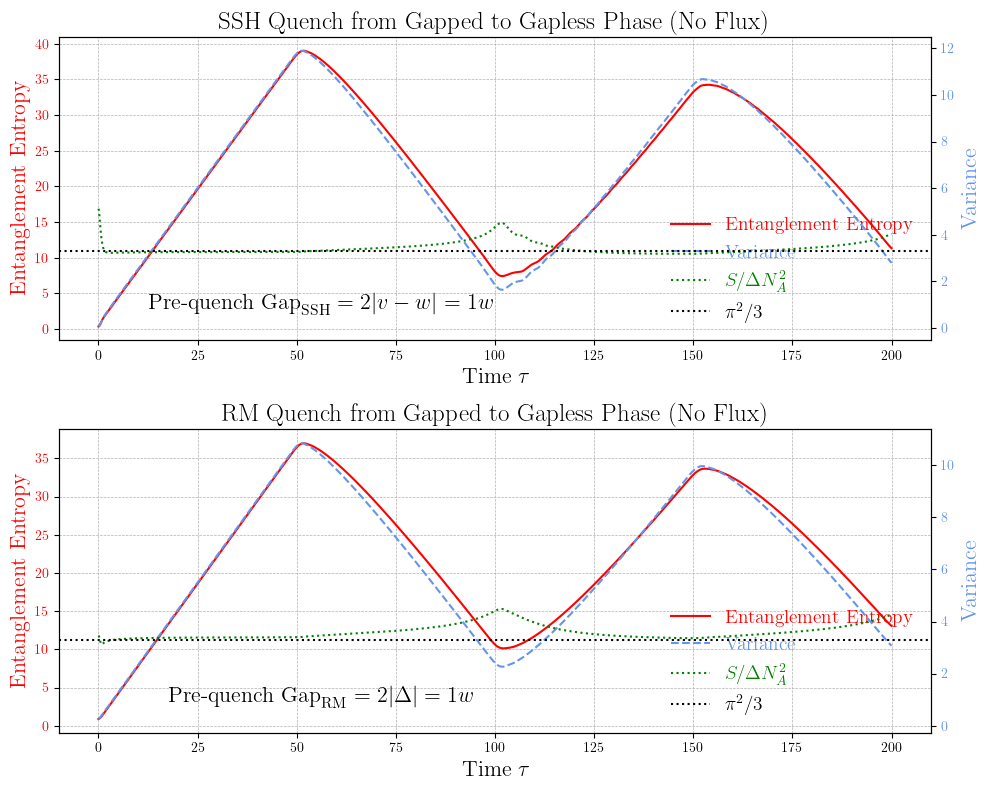

SSH -> $S/\Delta N_A^2 (t=0) = $5.12
RM  -> $S/\Delta N_A^2 (t=0) = $3.46
Expected $\pi^2/3 \approx $3.29


In [12]:
plot_SSH_and_RM_free_gapped_to_gapless_no_flux()

In [28]:
def plot_quench_gapless_with_flux_to_gapless_without_flux():
    df = pd.read_csv(data_quench_dir / "run_TB_free_quench_gapless_with_flux_to_gapless_no_flux_L100cells_200sec_v99999_plus_pi_div_2N.csv")
    df_subset = df[df["Time"] <= 50]

    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax2 = ax1.twinx()
    l1, = ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"TB Quench from Gapless with Flux to Gapless without Flux", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)

    plt.tight_layout()
    plt.savefig(plot_dir / "run_TB_free_quench_gapless_with_flux_to_gapless_no_flux_L100cells_200sec_v99999_plus_pi_div_2N.pdf")
    plt.show()

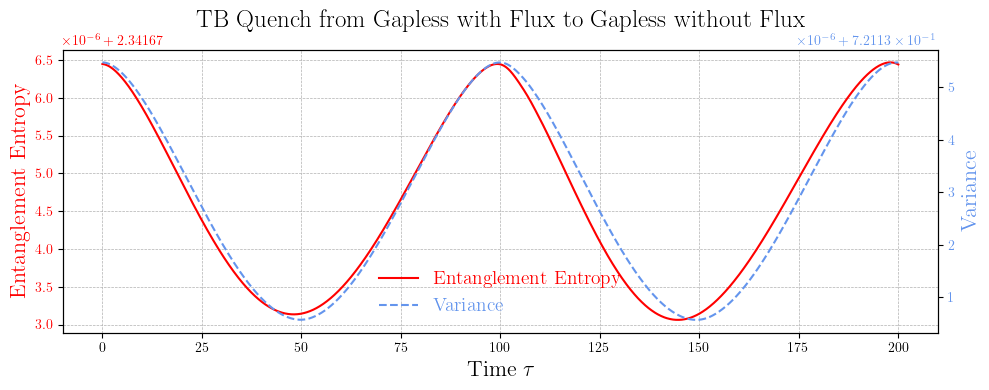

In [29]:
plot_quench_gapless_with_flux_to_gapless_without_flux()

In [19]:
def plot_SSH_free_quench_gapless_with_flux_to_gapless_no_flux():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_SSH_free_quench_gapless_with_flux_to_gapless_no_flux_L100cells_200sec_v99999.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"SSH Quench from Gapless with Flux to Gapless without Flux", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "SSH_free_quench_gapless_with_flux_to_gapless_no_flux.pdf")
    plt.show()

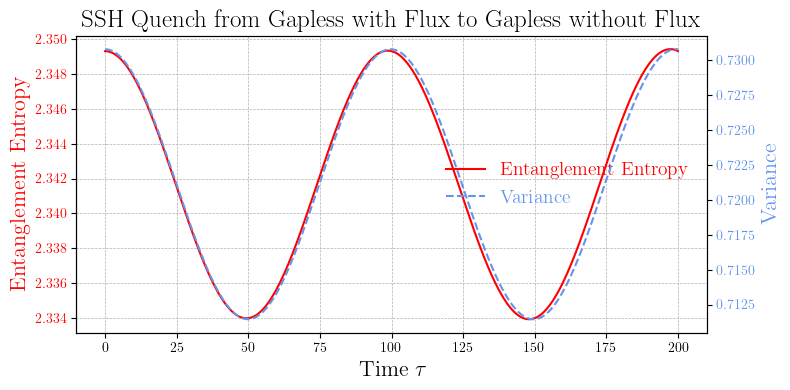

In [20]:
plot_SSH_free_quench_gapless_with_flux_to_gapless_no_flux()

In [21]:
def plot_RM_free_quench_gapped_to_gapless_no_flux():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_RM_free_quench_gapped_to_gapless_v99999_L100cells_200sec.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"RM Quench from Gapped to Gapless Phase (No Flux)", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "RM_free_quench_gapped_to_gapless_no_flux.pdf")
    plt.show()

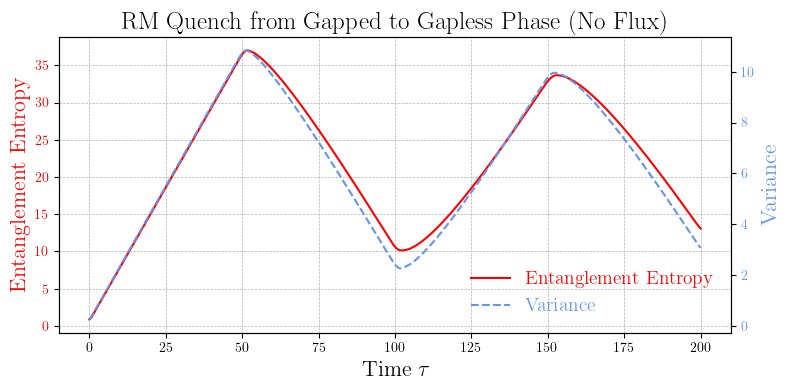

In [22]:
plot_RM_free_quench_gapped_to_gapless_no_flux()

In [13]:
def plot_TB_quench_interacting_gapped_to_non_interacting_gapless():
    # Load data 
    df_1 = pd.read_csv(data_quench_dir / "run_TB_quench_interacting_gapped_to_non_interacting_gapless_200sites_10sec_BondDim1000.csv")
    df_2 = pd.read_csv(data_quench_dir / "run_TB_quench_interacting_gapped_to_non_interacting_gapless_200sites_10sec_BondDim1200.csv")
    df_3 = pd.read_csv(data_quench_dir / "run_TB_quench_interacting_gapped_to_non_interacting_gapless_200sites_10sec_BondDim1500.csv")
    
    # Extract data
    time_1 = df_1["Time"].values
    entropy_1 = df_1["Entropy"].values
    variance_1 = df_1["Variance"].values

    time_2 = df_2["Time"].values
    entropy_2 = df_2["Entropy"].values
    variance_2 = df_2["Variance"].values

    time_3 = df_3["Time"].values
    entropy_3 = df_3["Entropy"].values
    variance_3 = df_3["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(10, 14))
    spec = gridspec.GridSpec(ncols=1, nrows=3, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()
    ax3 = fig.add_subplot(spec[1, 0])
    ax4 = ax3.twinx()
    ax5 = fig.add_subplot(spec[2, 0])
    ax6 = ax5.twinx()


    # Plot - BondDim 1000
    l1, =ax1.plot(time_1, entropy_1, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time_1, variance_1, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"TB Quench from Interacting Gapped to Non-Interacting Gapless Phase (BondDim 1000)",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)

    # Plot - BondDim 1200
    l7, = ax3.plot(time_2, entropy_2, color="red", label=r"Entanglement Entropy")
    l8, = ax4.plot(time_2, variance_2, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax3.set_xlabel(r"Time $\tau$", size=16)
    ax3.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax4.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax3.tick_params(axis="y", labelcolor="red")
    ax4.tick_params(axis="y", labelcolor="cornflowerblue")
    ax3.set_title(r"TB Quench from Interacting Gapped to Non-Interacting Gapless Phase (BondDim 1200)",size=18)
    ax3.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax3.legend(handles=[l7, l8], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)

    # Plot - BondDim 1500
    l9, = ax5.plot(time_3, entropy_3, color="red", label=r"Entanglement Entropy")
    l10, = ax6.plot(time_3, variance_3, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax5.set_xlabel(r"Time $\tau$", size=16)
    ax5.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax6.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax5.tick_params(axis="y", labelcolor="red")
    ax6.tick_params(axis="y", labelcolor="cornflowerblue")
    ax5.set_title(r"TB Quench from Interacting Gapped to Non-Interacting Gapless Phase (BondDim 1500)",size=18)
    ax5.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax5.legend(handles=[l9, l10], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)


    plt.tight_layout()
    plt.savefig(plot_dir / "TB_quench_interacting_gapped_to_non_interacting_gapless_different_BondDims(1000-1500).pdf")
    plt.show()

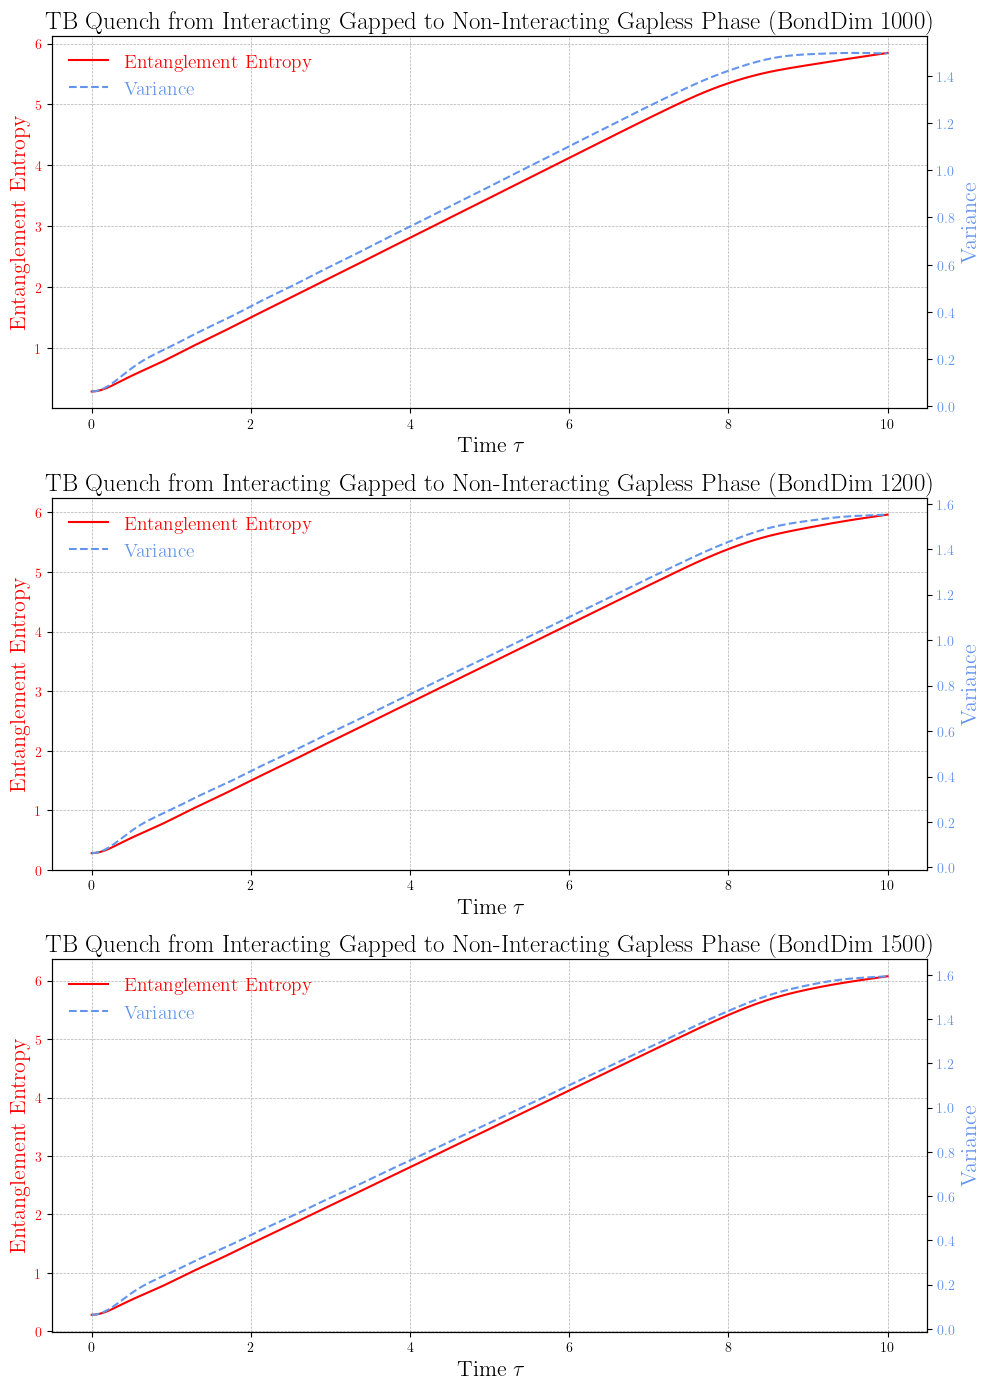

In [14]:
plot_TB_quench_interacting_gapped_to_non_interacting_gapless()

In [7]:
def plot_TB_quench_interacting_gapless_to_non_interacting_gapless():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_TB_quench_interacting_gapless_to_non_interacting_gapless_200sites_10sec_BondDim1500.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="cornflowerblue", label=r"Variance", linestyle="--")
    #l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    #l4  = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"TB Quench from Interacting Gapless to Non-Interacting Gapless Phase",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="lower right", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "TB_quench_interacting_gapless_to_non_interacting_gapless.pdf")
    plt.show()

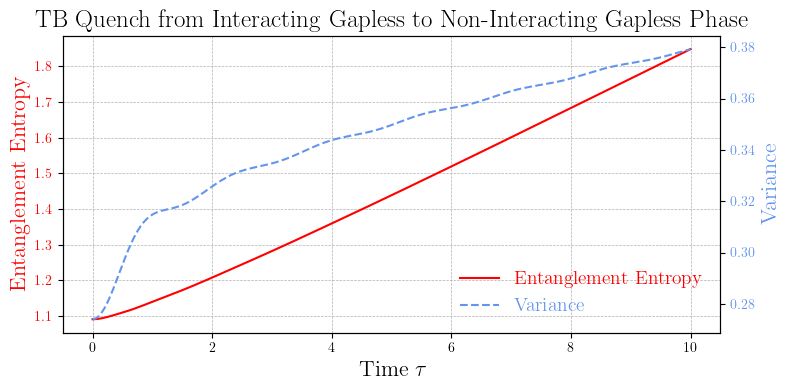

In [8]:
plot_TB_quench_interacting_gapless_to_non_interacting_gapless()

In [14]:
def plot_quench_results_inital_state_disordered_bd_1000():

    search_pattern = "run_TB_quench_disordered_to_non_interacting_gapless_200sites_10sec_BondDim1000_run*.csv"
    files = glob.glob(str(data_quench_dir / search_pattern))

    if not files:
        print("No files found matching the pattern.")
    else:
        print(f"Found {len(files)} files matching the pattern.")

    dataframes = [pd.read_csv(file) for file in files]
    combined_df = pd.concat(dataframes)

    average_df = combined_df.groupby('Time').mean().reset_index()

    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, = ax1.plot(average_df["Time"], average_df["Entropy"], color="red", label=r"Average Entanglement Entropy")
    l2, = ax2.plot(average_df["Time"], average_df["Variance"], color="navy", label=r"Average Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"TB Quench from Disordered to Non-Interacting Gapless Phase (Average over 10 Runs)", size=14)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    
    plt.savefig(plot_dir / "TB_quench_disordered_to_non_interacting_gapless_average_over_runs_bd_1000.pdf")
    plt.show()

Found 10 files matching the pattern.


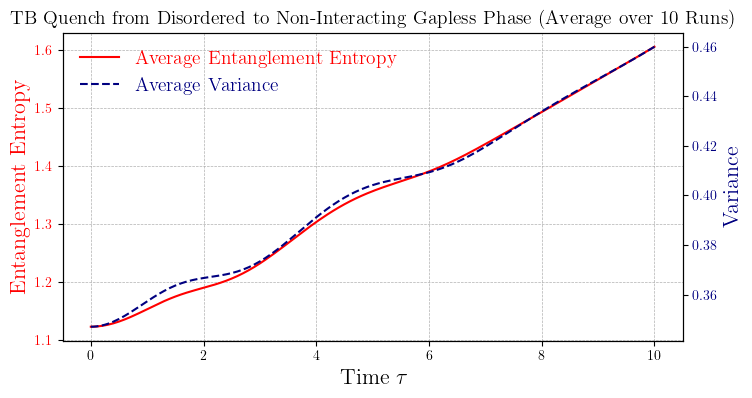

In [15]:
plot_quench_results_inital_state_disordered_bd_1000()

In [16]:
def plot_quench_TB_disordered_to_gapless_whole_10_runs_bd_1000():

    fig = plt.figure(figsize=(16, 20))
    spec = gridspec.GridSpec(ncols=2, nrows=5, figure=fig)

    search_pattern = "run_TB_quench_disordered_to_non_interacting_gapless_200sites_10sec_BondDim1000_run*.csv"
    files = glob.glob(str(data_quench_dir / search_pattern))
    if not files:
        print("No files found matching the pattern.")
    else:
        print(f"Found {len(files)} files matching the pattern.")

    for i, file in enumerate(files):
        df = pd.read_csv(file)
        time = df["Time"].values
        entropy = df["Entropy"].values
        variance = df["Variance"].values

        row = i // 2
        col = i % 2

        ax1 = fig.add_subplot(spec[row, col])
        ax2 = ax1.twinx()

        l1, = ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
        l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")

        ax1.set_xlabel(r"Time $\tau$", size=12)
        ax1.set_ylabel(r"Entanglement Entropy", color="red", size=12)
        ax2.set_ylabel(r"Variance", color="navy", size=12)
        ax1.tick_params(axis="y", labelcolor="red")
        ax2.tick_params(axis="y", labelcolor="navy")
        ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
        leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=10, frameon=False)
        for text, color in zip(leg.get_texts(), ["red", "navy"]):
            text.set_color(color)

    fig.suptitle(r"TB Quench from Disordered to Non-Interacting Gapless Phase", size=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(plot_dir / "TB_quench_disordered_to_non_interacting_gapless_all_10_runs_bd_1000.pdf")
    plt.show()    
    

Found 10 files matching the pattern.


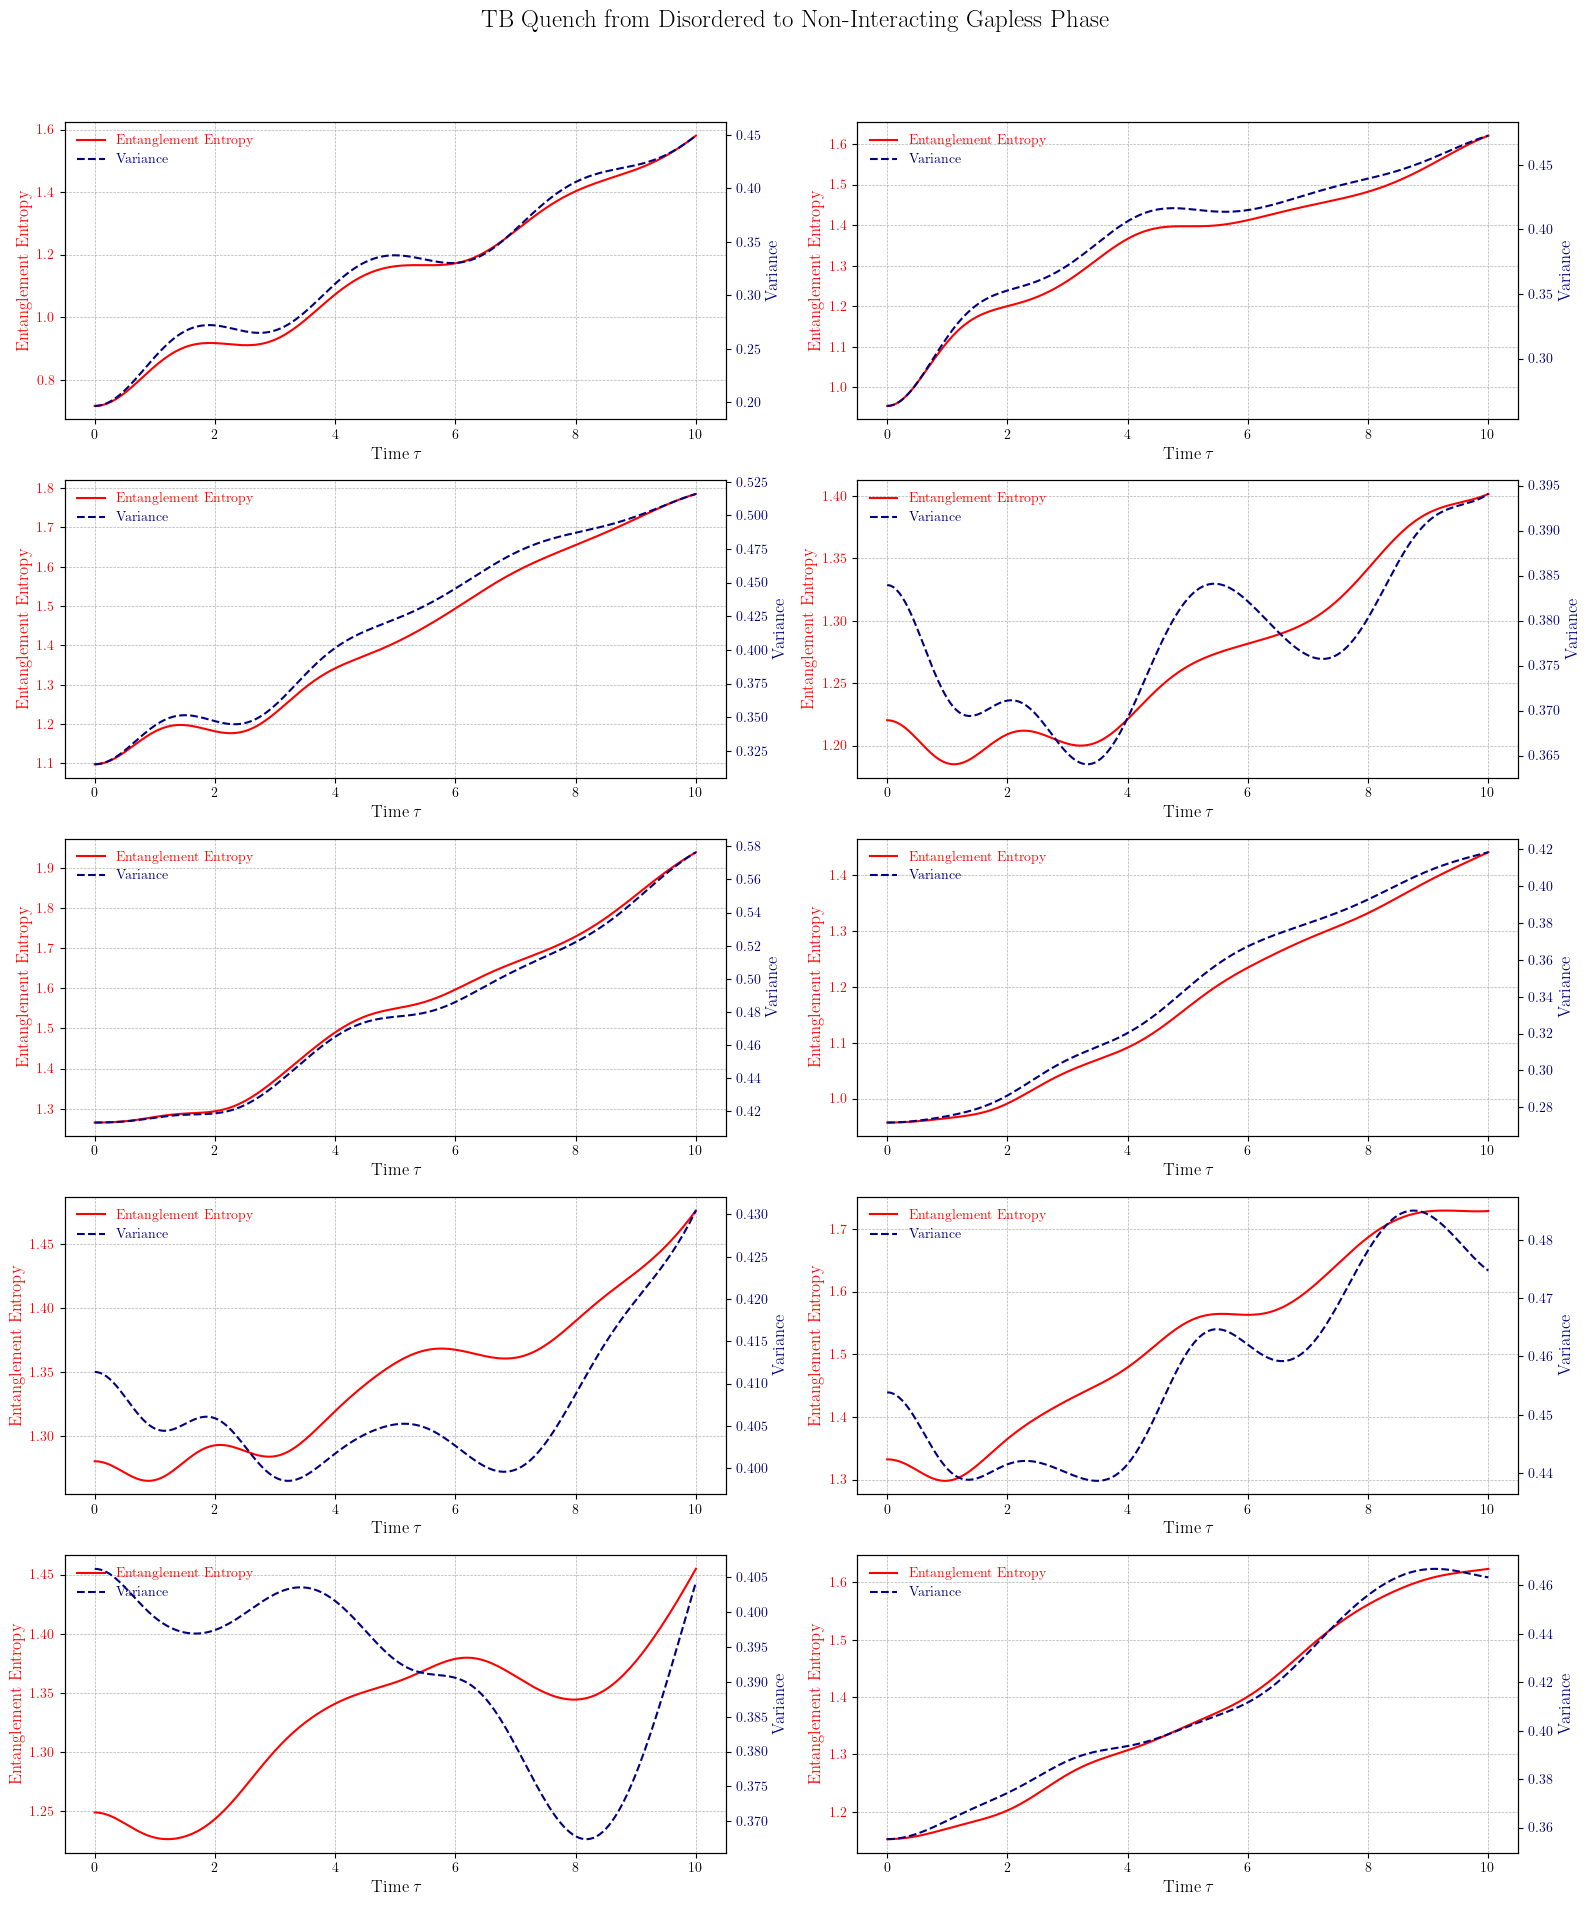

In [17]:
plot_quench_TB_disordered_to_gapless_whole_10_runs_bd_1000()

In [22]:
def plot_quench_TB_disordered_to_gapless_whole_10_runs_bd_1500():

    fig = plt.figure(figsize=(16, 20))
    spec = gridspec.GridSpec(ncols=2, nrows=5, figure=fig)

    search_pattern = "run_TB_quench_disordered_to_non_interacting_gapless_200sites_10sec_BondDim1500_run*.csv"
    files = glob.glob(str(data_quench_dir / search_pattern))
    if not files:
        print("No files found matching the pattern.")
    else:
        print(f"Found {len(files)} files matching the pattern.")

    for i, file in enumerate(files):
        df = pd.read_csv(file)
        time = df["Time"].values
        entropy = df["Entropy"].values
        variance = df["Variance"].values

        row = i // 2
        col = i % 2

        ax1 = fig.add_subplot(spec[row, col])
        ax2 = ax1.twinx()

        l1, = ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
        l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")

        ax1.set_xlabel(r"Time $\tau$", size=12)
        ax1.set_ylabel(r"Entanglement Entropy", color="red", size=12)
        ax2.set_ylabel(r"Variance", color="navy", size=12)
        ax1.tick_params(axis="y", labelcolor="red")
        ax2.tick_params(axis="y", labelcolor="navy")
        ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
        leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=10, frameon=False)
        for text, color in zip(leg.get_texts(), ["red", "navy"]):
            text.set_color(color)

    fig.suptitle(r"TB Quench from Disordered to Non-Interacting Gapless Phase", size=24)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(plot_dir / "TB_quench_disordered_to_non_interacting_gapless_all_10_runs_bd_1500.pdf")
    plt.show()    
    

Found 10 files matching the pattern.


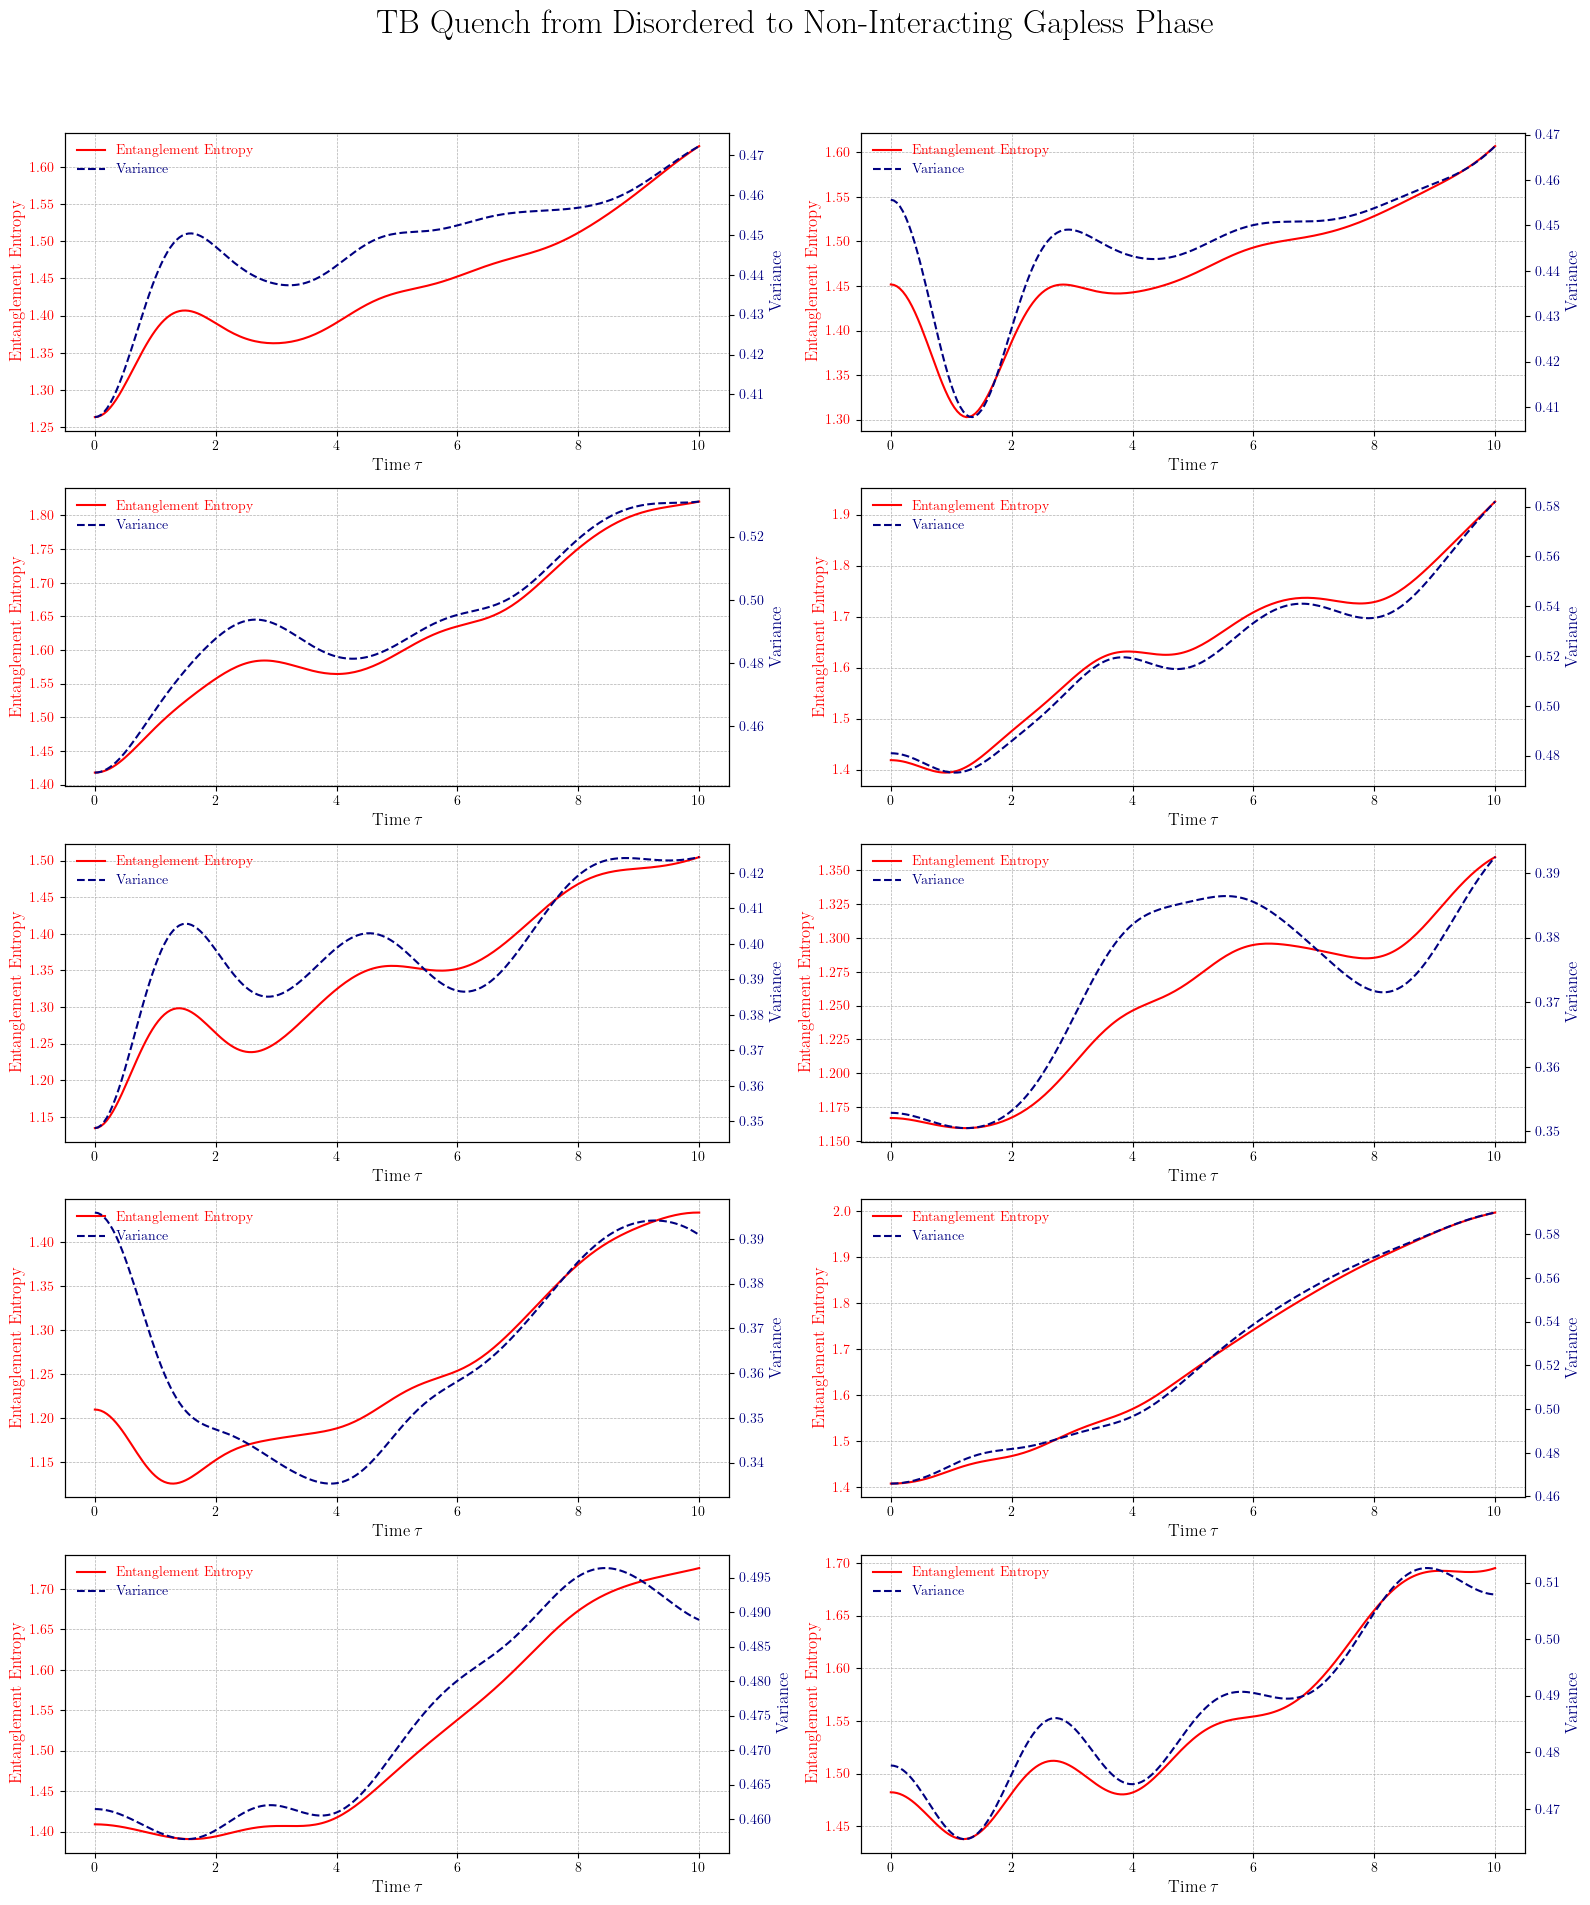

In [23]:
plot_quench_TB_disordered_to_gapless_whole_10_runs_bd_1500()

In [ ]:
def plot_quench_results_inital_state_disordered_bd_1500():

    search_pattern = "run_TB_quench_disordered_to_non_interacting_gapless_200sites_10sec_BondDim1500_run*.csv"
    files = glob.glob(str(data_quench_dir / search_pattern))

    if not files:
        print("No files found matching the pattern.")
    else:
        print(f"Found {len(files)} files matching the pattern.")

    dataframes = [pd.read_csv(file) for file in files]
    combined_df = pd.concat(dataframes)

    average_df = combined_df.groupby('Time').mean().reset_index()

    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, = ax1.plot(average_df["Time"], average_df["Entropy"], color="red", label=r"Average Entanglement Entropy")
    l2, = ax2.plot(average_df["Time"], average_df["Variance"], color="navy", label=r"Average Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"TB Quench from Disordered to Non-Interacting Gapless Phase (Average over 10 Runs)", size=20)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    
    plt.savefig(plot_dir / "TB_quench_disordered_to_non_interacting_gapless_average_over_runs_bd_1500.pdf")
    plt.show()

Found 10 files matching the pattern.


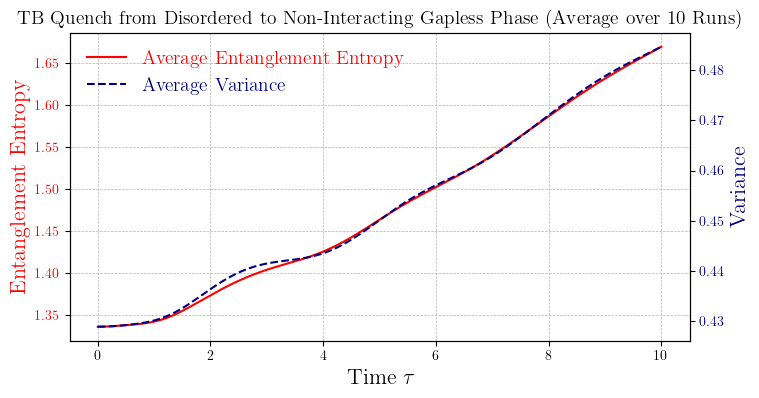

In [21]:
plot_quench_results_inital_state_disordered_bd_1500()

In [17]:
def plot_quench_CDW_to_Luttinger_Liquid():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_CDW_to_Luttinger_liquid_200sites_10sec_BondDim1500.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"TB Quench from CDW to LL phase $V_i = 4.0 \rightarrow V_f = 1.0$",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="lower right", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "TB_quench_CDW_to_Luttinger_liquid.pdf")
    plt.show()

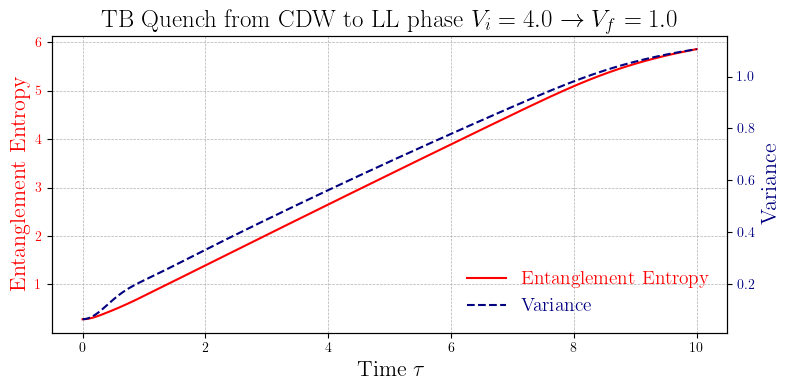

In [18]:
plot_quench_CDW_to_Luttinger_Liquid()

In [15]:
def plot_quench_CDW_to_LL_8sec():
    # Load data 
    path = checkpoint_dir/"quench_from_CDW_to_LL_small_transition.h5"

    # Extract data
    with h5py.File(path, "r") as f: 
        print(list(f.keys()))

        step = f["step"][()]
        t_final = f["t"][()]
        S_EE_vals = f["S_EE_vals"][:]
        F_vals = f["F_vals"][:]
        total_fidelity = f["total_fidelity"][()]
    
    dt = 0.05
    times = np.arange(len(S_EE_vals)) * dt

    print(f"checkpoint step: {step}, final time: {t_final}, total fidelity: {total_fidelity:.6f}")


    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(times, S_EE_vals, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(times, F_vals, color="navy", label=r"Variance", linestyle="--")
    #l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    #l4 = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from CDW to LL $V_i = 2.5 \rightarrow V_f = 1.5$",size=18)
    ax1.set_xlim(0, 10)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "LL_quench_from_CDW_to_LL_8sec.pdf")
    plt.show()

['F_vals', 'S_EE_vals', 'psi', 'step', 't', 'total_fidelity']
checkpoint step: 180, final time: 8.95, total fidelity: 0.998765


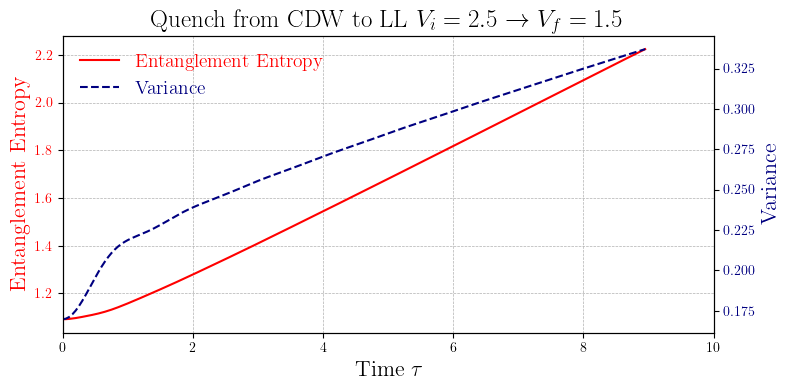

In [16]:
plot_quench_CDW_to_LL_8sec()

In [13]:
def plot_quench_Luttinger_Liquid_to_Luttinger_Liquid():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_increase_V_200sites_10sec_bonddim2000_cutoff1.0e-8.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"TB Quench from LL to LL phase $V_i = 0.5 \rightarrow V_f = 1.0$",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="lower right", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "quench_Luttinger_liquid_to_Luttinger_liquid_increase_V.pdf")
    plt.show()

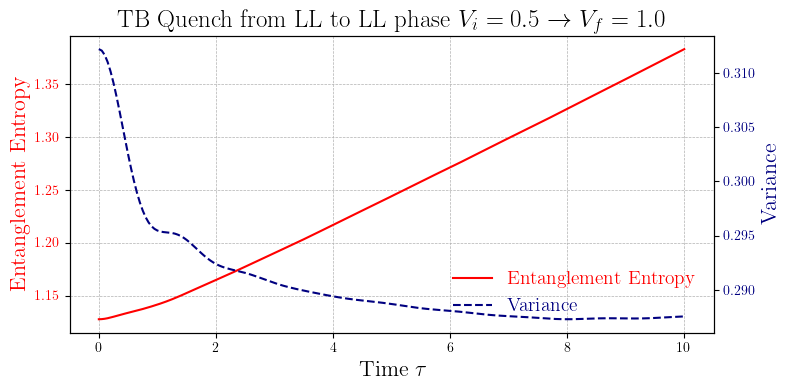

In [14]:
plot_quench_Luttinger_Liquid_to_Luttinger_Liquid()

In [9]:
def plot_quench_Luttinger_Liquid_to_Luttinger_Liquid_decrease_V():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_200sites_10sec_bonddim2000_cutoff1.0e-8.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()
    ax3 = fig.add_subplot(spec[1, 0])

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from LL to LL phase $V_i = 1.0 \rightarrow V_f = 0.5$",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="lower right", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    
    l3, = ax3.semilogx(time, variance, color="navy", label=r"Variance", linestyle="--")
    ax3.set_xlabel(r"$\log(\tau)$", size=16)
    ax3.set_ylabel(r"Variance", color="navy", size=16)
    ax3.tick_params(axis="y", labelcolor="navy")
    ax3.set_title(r"Variance in Log Scale",size=18)
    ax3.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax3.legend(handles=[l3], loc="lower right", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy"]):
        text.set_color(color)


    plt.tight_layout()
    plt.savefig(plot_dir / "quench_Luttinger_liquid_to_Luttinger_liquid_decrease_V.pdf")
    plt.show()

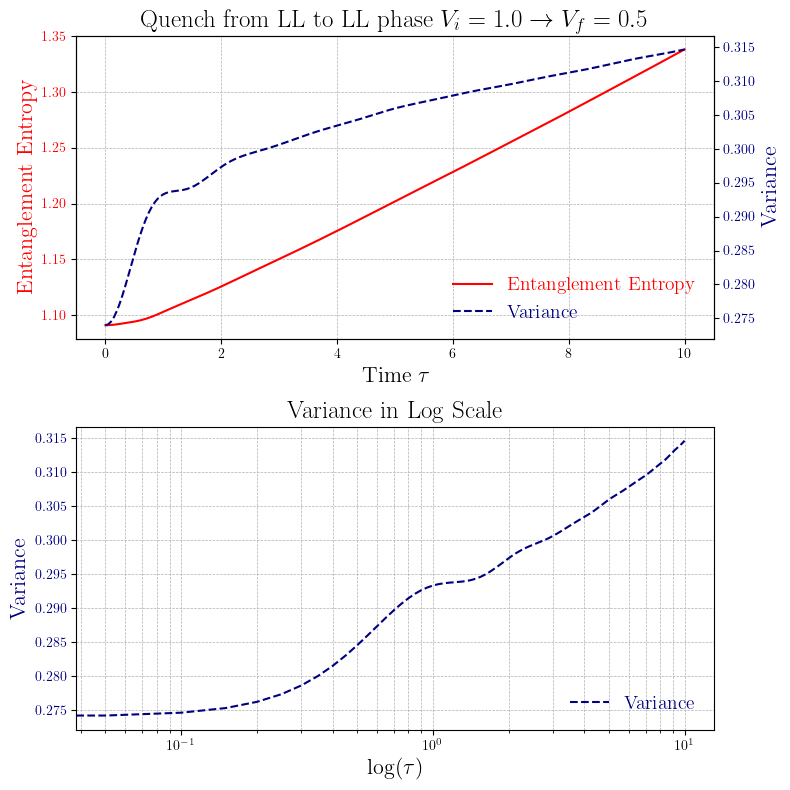

In [10]:
plot_quench_Luttinger_Liquid_to_Luttinger_Liquid_decrease_V()

In [ ]:
def plot_quench_Luttinger_Liquid_to_Luttinger_Liquid_decrease_V_DV02():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_10sec_bonddim2000_cutoff1.0e-8.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()
    ax3 = fig.add_subplot(spec[1, 0])

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from LL to LL phase $V_i = 0.7 \rightarrow V_f = 0.5$",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="lower right", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)

    l4, = ax3.semilogx(time, variance, color="navy", label=r"Variance", linestyle="--")
    ax3.set_xlabel(r"$\log(\tau)$", size=16)
    ax3.set_ylabel(r"Variance", color="navy", size=16)
    ax3.tick_params(axis="y", labelcolor="navy")
    ax3.set_title(r"Variance in log scale",size=18)
    ax3.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax3.legend(handles=[l4], loc="lower right", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy"]):
        text.set_color(color)    

    plt.tight_layout()
    plt.savefig(plot_dir / "quench_Luttinger_liquid_to_Luttinger_liquid_decrease_V_DV02.pdf")
    plt.show()

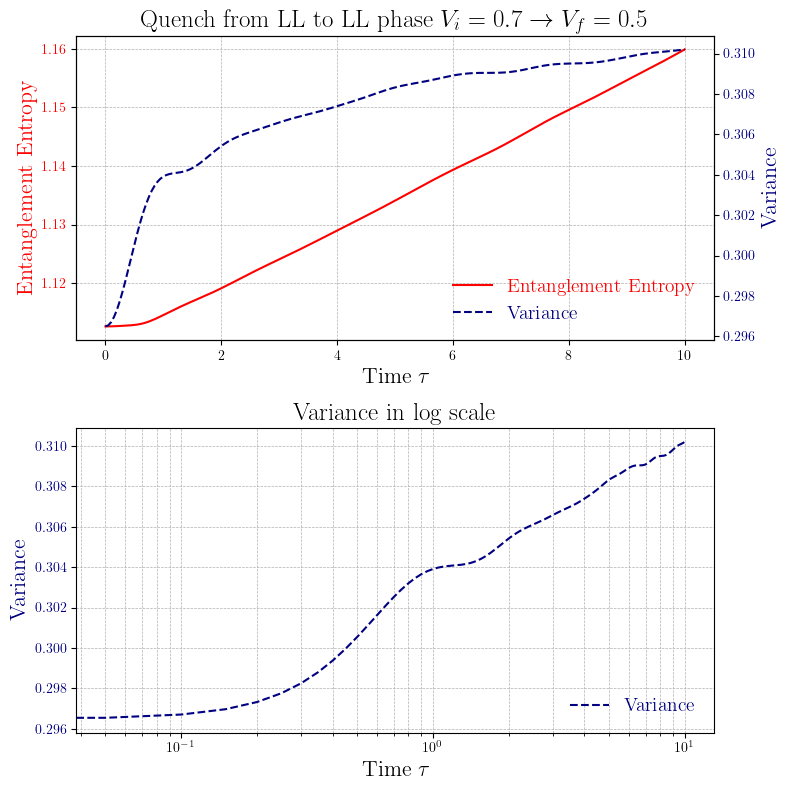

In [50]:
plot_quench_Luttinger_Liquid_to_Luttinger_Liquid_decrease_V_DV02()

In [45]:
def plot_quench_Luttinger_Liquid_to_Luttinger_Liquid_decrease_V_DV02_20sec():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time20.0_bonddim2000_cutoff1.0e-8.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()
    ax3 = fig.add_subplot(spec[1, 0])

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from LL to LL phase $V_i = 0.7 \rightarrow V_f = 0.5$",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="lower right", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)   
    
    l3, = ax3.semilogx(time, variance, color="navy", label=r"Variance", linestyle="--")
    ax3.set_xlabel(r"Time $\tau$", size=16)
    ax3.set_ylabel(r"Variance", color="navy", size=16)
    ax3.tick_params(axis="y", labelcolor="navy")
    ax3.set_title(r"Variance in log scale",size=18)
    ax3.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax3.legend(handles=[l3], loc="lower right", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy"]):
        text.set_color(color)

    plt.tight_layout()
    plt.savefig(plot_dir / "quench_Luttinger_liquid_to_Luttinger_liquid_decrease_V_DV02_20sec.pdf")
    plt.show()

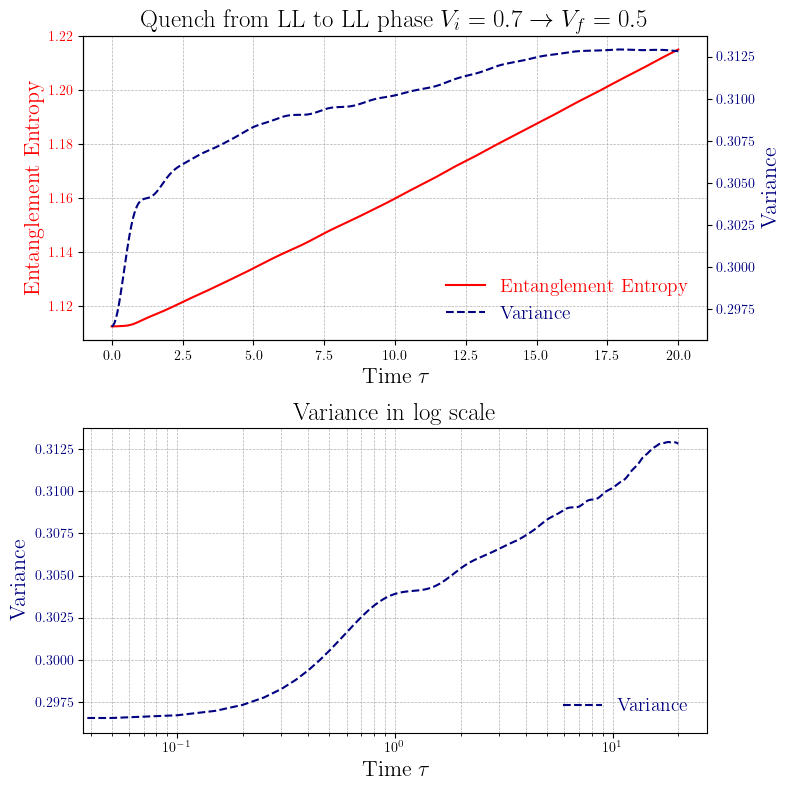

In [46]:
plot_quench_Luttinger_Liquid_to_Luttinger_Liquid_decrease_V_DV02_20sec()

# Post-quench GAPPED

In [31]:
def plot_TB_quench_gapless_no_flux_to_RM_and_SSH_gapped_no_flux():
    # Load data
    df_SSH = pd.read_csv(data_quench_dir / "run_TB_free_quench_gapless_no_flux_to_SSH_gapped_no_flux_L100cells_200sec.csv")
    df_RM = pd.read_csv(data_quench_dir / "run_TB_free_quench_gapless_no_flux_to_RM_gapped_no_flux_L100cells_200sec.csv")

    # Extract data
    time_SSH = df_SSH["Time"].values
    entropy_SSH = df_SSH["Entropy"].values
    variance_SSH = df_SSH["Variance"].values
    time_RM = df_RM["Time"].values
    entropy_RM = df_RM["Entropy"].values
    variance_RM = df_RM["Variance"].values
    ratio_SSH = entropy_SSH / variance_SSH
    ratio_RM = entropy_RM / variance_RM

    # Plotting
    fig = plt.figure(figsize=(10, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()
    ax3 = fig.add_subplot(spec[1, 0])
    ax4 = ax3.twinx()

    # SSH Plot - ax1 and ax2
    l1, =ax1.plot(time_SSH, entropy_SSH, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time_SSH, variance_SSH, color="cornflowerblue", label=r"Variance")
    l5, = ax2.plot(time_SSH, ratio_SSH, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    l6  = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"TB Quench from Gapless without Flux to SSH Gapped without Flux", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax1.text(0.5, 0.1, r"Post-quench $\text{Gap}_{\text{SSH}} = 2 \vert v-w \vert = 1w$", transform=ax1.transAxes, fontsize=16, fontweight="bold", color="black", ha="center")
    leg1 = ax1.legend(handles=[l1, l2, l5, l6], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg1.get_texts(), ["red", "cornflowerblue", "green", "black"]):
        text.set_color(color)

    # RM Plot - ax3 and ax4
    l3, =ax3.plot(time_RM, entropy_RM, color="red", label=r"Entanglement Entropy")
    l4, = ax4.plot(time_RM, variance_RM, color="cornflowerblue", label=r"Variance")
    l7, = ax4.plot(time_RM, ratio_RM, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    l8  = ax4.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax3.set_xlabel(r"Time $\tau$", size=16)
    ax3.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax4.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax3.tick_params(axis="y", labelcolor="red")
    ax4.tick_params(axis="y", labelcolor="cornflowerblue")
    ax3.set_title(r"TB Quench from Gapless without Flux to RM Gapped without Flux", size=18)
    ax3.text(0.5, 0.1, r"Post-quench $\text{Gap}_{\text{RM}} = 2 \vert \Delta \vert = 1w$", transform=ax3.transAxes, fontsize=16, fontweight="bold", color="black", ha="center")
    ax3.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg2 = ax3.legend(handles=[l3, l4, l7, l8], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg2.get_texts(), ["red", "cornflowerblue", "green", "black"]):
        text.set_color(color)
    
    plt.tight_layout()
    plt.savefig(plot_dir / "TB_quench_gapless_no_flux_to_RM_and_SSH_gapped_no_flux.pdf")
    plt.show()

    print(r"SSH -> $S/\Delta N_A^2 (t=0) = $" + f"{ratio_SSH[0]:.2f}")
    print(r"RM  -> $S/\Delta N_A^2 (t=0) = $" + f"{ratio_RM[0]:.2f}")
    print(r"Expected $\pi^2/3 \approx $" + f"{np.pi**2/3:.2f}")

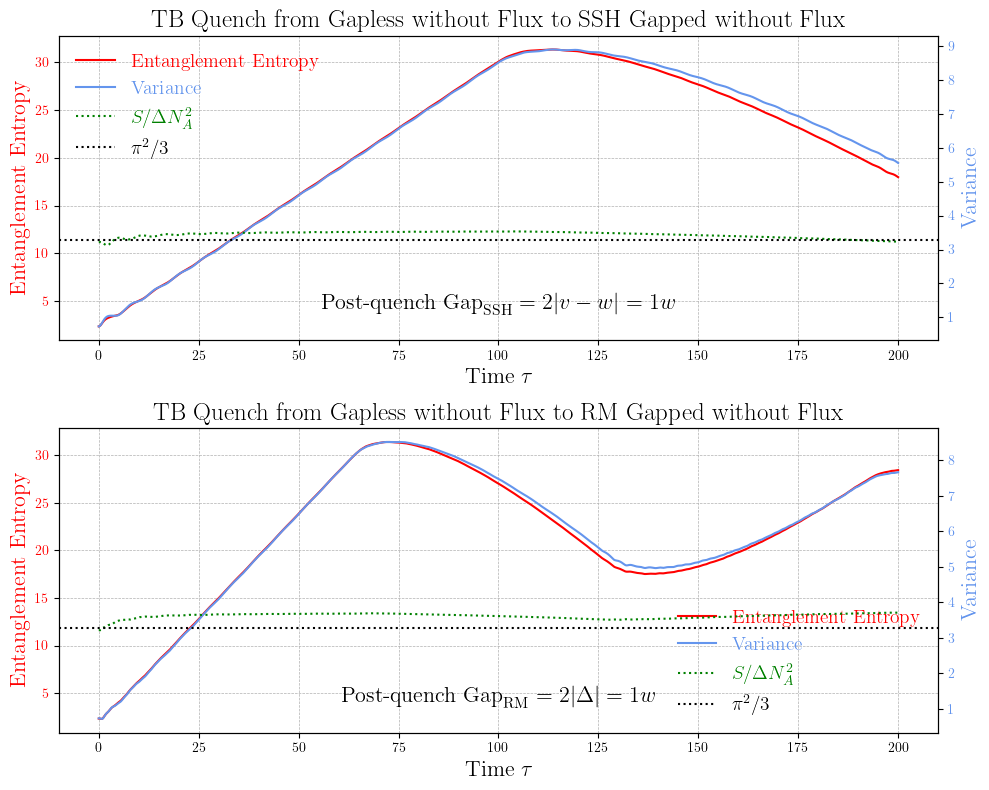

SSH -> $S/\Delta N_A^2 (t=0) = $3.21
RM  -> $S/\Delta N_A^2 (t=0) = $3.21
Expected $\pi^2/3 \approx $3.29


In [32]:
plot_TB_quench_gapless_no_flux_to_RM_and_SSH_gapped_no_flux()

In [15]:
def plot_RM_and_SSH_free_gapped_with_flux_to_gapped_no_flux():
    # Load data 
    df_SSH = pd.read_csv(data_quench_dir / "run_SSH_free_quench_gapped_with_flux_to_gapped_no_flux_L100cells_200sec.csv")
    df_RM = pd.read_csv(data_quench_dir / "run_RM_free_quench_gapped_with_flux_to_gapped_no_flux_L100cells_200sec_flux_pi.csv")

    # Extract data
    time_SSH = df_SSH["Time"].values
    entropy_SSH = df_SSH["Entropy"].values
    variance_SSH = df_SSH["Variance"].values

    time_RM = df_RM["Time"].values
    entropy_RM = df_RM["Entropy"].values
    variance_RM = df_RM["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(10, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()
    ax3 = fig.add_subplot(spec[1, 0])
    ax4 = ax3.twinx()

    # SSH Plot - ax1 and ax2
    l1, =ax1.plot(time_SSH, entropy_SSH, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time_SSH, variance_SSH, color="cornflowerblue", label=r"Variance")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"SSH Quench from Gapped with Flux to Gapped without Flux", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax1.text(0.5, 0.1, r"$\text{Gap}_{\text{SSH}} = 2 \vert v-w \vert = 1w$", transform=ax1.transAxes, fontsize=16, fontweight="bold", color="black", ha="center")
    leg1 = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg1.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)
    
    # RM Plot - ax3 and ax4
    l3, =ax3.plot(time_RM, entropy_RM, color="red", label=r"Entanglement Entropy")
    l4, = ax4.plot(time_RM, variance_RM, color="cornflowerblue", label=r"Variance")
    ax3.set_xlabel(r"Time $\tau$", size=16)
    ax3.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax4.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax3.tick_params(axis="y", labelcolor="red")
    ax4.tick_params(axis="y", labelcolor="cornflowerblue")
    ax3.set_title(r"RM Quench from Gapped with Flux to Gapped without Flux", size=18)
    ax3.text(0.5, 0.1, r"$\text{Gap}_{\text{RM}} = 2 \vert \Delta \vert = 1w$", transform=ax3.transAxes, fontsize=16, fontweight="bold", color="black", ha="center")
    ax3.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg2 = ax3.legend(handles=[l3, l4], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg2.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)

    plt.tight_layout()
    plt.savefig(plot_dir / "RM_and_SSH_free_quench_gapped_with_flux_to_gapped_no_flux.pdf")
    plt.show()

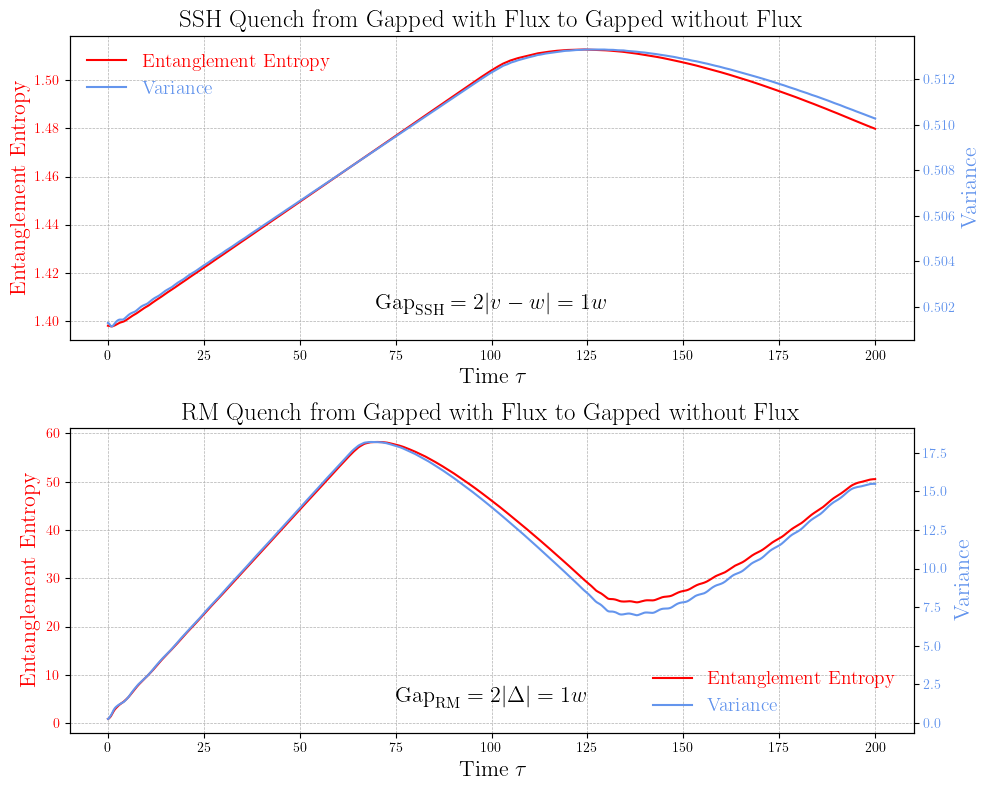

In [16]:
plot_RM_and_SSH_free_gapped_with_flux_to_gapped_no_flux()

In [49]:
def plot_TB_quench_interacting_gapped_to_non_interacting_gapped():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_TB_quench_interacting_gapped_to_non_interacting_gapped_SSH_200sites_10sec.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="cornflowerblue", label=r"Variance", linestyle="--")
    l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    l4  = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"TB Quench from Interacting Gapped to Non-Interacting Gapped Phase",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2, l3, l4], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue", "green", "black"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "TB_quench_interacting_gapped_to_non_interacting_gapped.pdf")
    plt.show()

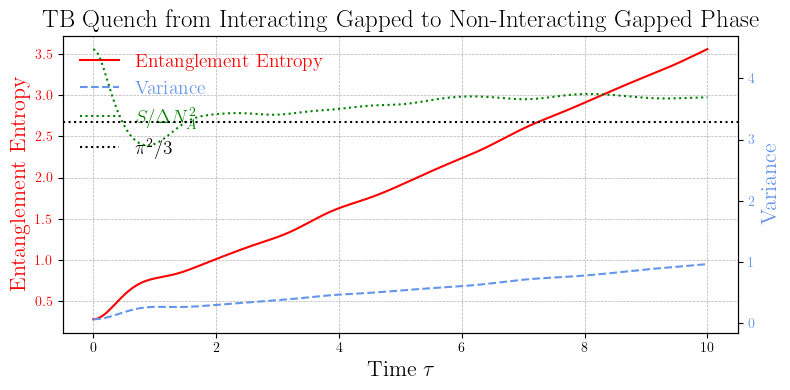

In [50]:
plot_TB_quench_interacting_gapped_to_non_interacting_gapped()

In [47]:
def plot_TB_quench_interacting_gapless_to_non_interacting_gapped():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_TB_quench_interacting_gapless_to_non_interacting_gapped_SSH_200sites_10sec.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="cornflowerblue", label=r"Variance", linestyle="--")
    l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    l4 = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"TB Quench from Interacting Gapless to Non-Interacting Gapped Phase",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2, l3, l4], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue", "green", "black"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "TB_quench_interacting_gapless_to_non_interacting_gapped_plot_ratio.pdf")
    plt.show()

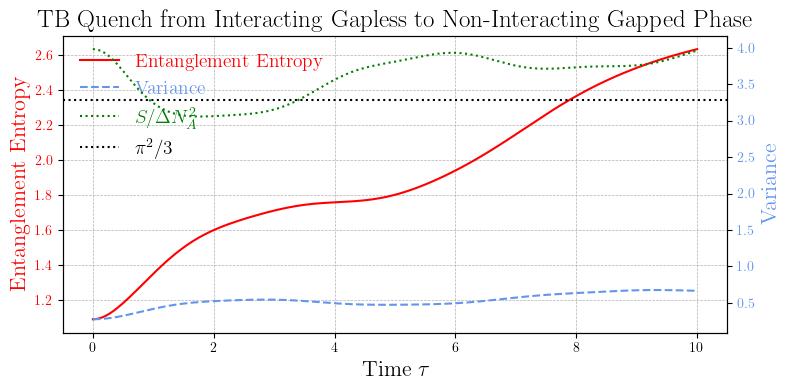

In [48]:
plot_TB_quench_interacting_gapless_to_non_interacting_gapped()

In [5]:
def plot_quench_TB_disordered_to_gapped_whole_10_runs():

    fig = plt.figure(figsize=(16, 20))
    spec = gridspec.GridSpec(ncols=2, nrows=5, figure=fig)

    search_pattern = "run_TB_quench_disordered_to_non_interacting_gapped_200sites_10sec_BondDim1000_run*.csv"
    files = glob.glob(str(data_quench_dir / search_pattern))
    if not files:
        print("No files found matching the pattern.")
    else:
        print(f"Found {len(files)} files matching the pattern.")

    for i, file in enumerate(files):
        df = pd.read_csv(file)
        time = df["Time"].values
        entropy = df["Entropy"].values
        variance = df["Variance"].values

        row = i // 2
        col = i % 2

        ax1 = fig.add_subplot(spec[row, col])
        ax2 = ax1.twinx()

        l1, = ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
        l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")

        ax1.set_xlabel(r"Time $\tau$", size=12)
        ax1.set_ylabel(r"Entanglement Entropy", color="red", size=12)
        ax2.set_ylabel(r"Variance", color="navy", size=12)
        ax1.tick_params(axis="y", labelcolor="red")
        ax2.tick_params(axis="y", labelcolor="navy")
        ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
        leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=10, frameon=False)
        for text, color in zip(leg.get_texts(), ["red", "navy"]):
            text.set_color(color)

    fig.suptitle(r"TB Quench from Disordered to Non-Interacting Gapped Phase", size=18)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(plot_dir / "TB_quench_disordered_to_non_interacting_gapped_all_10_runs.pdf")
    plt.show()  

Found 10 files matching the pattern.


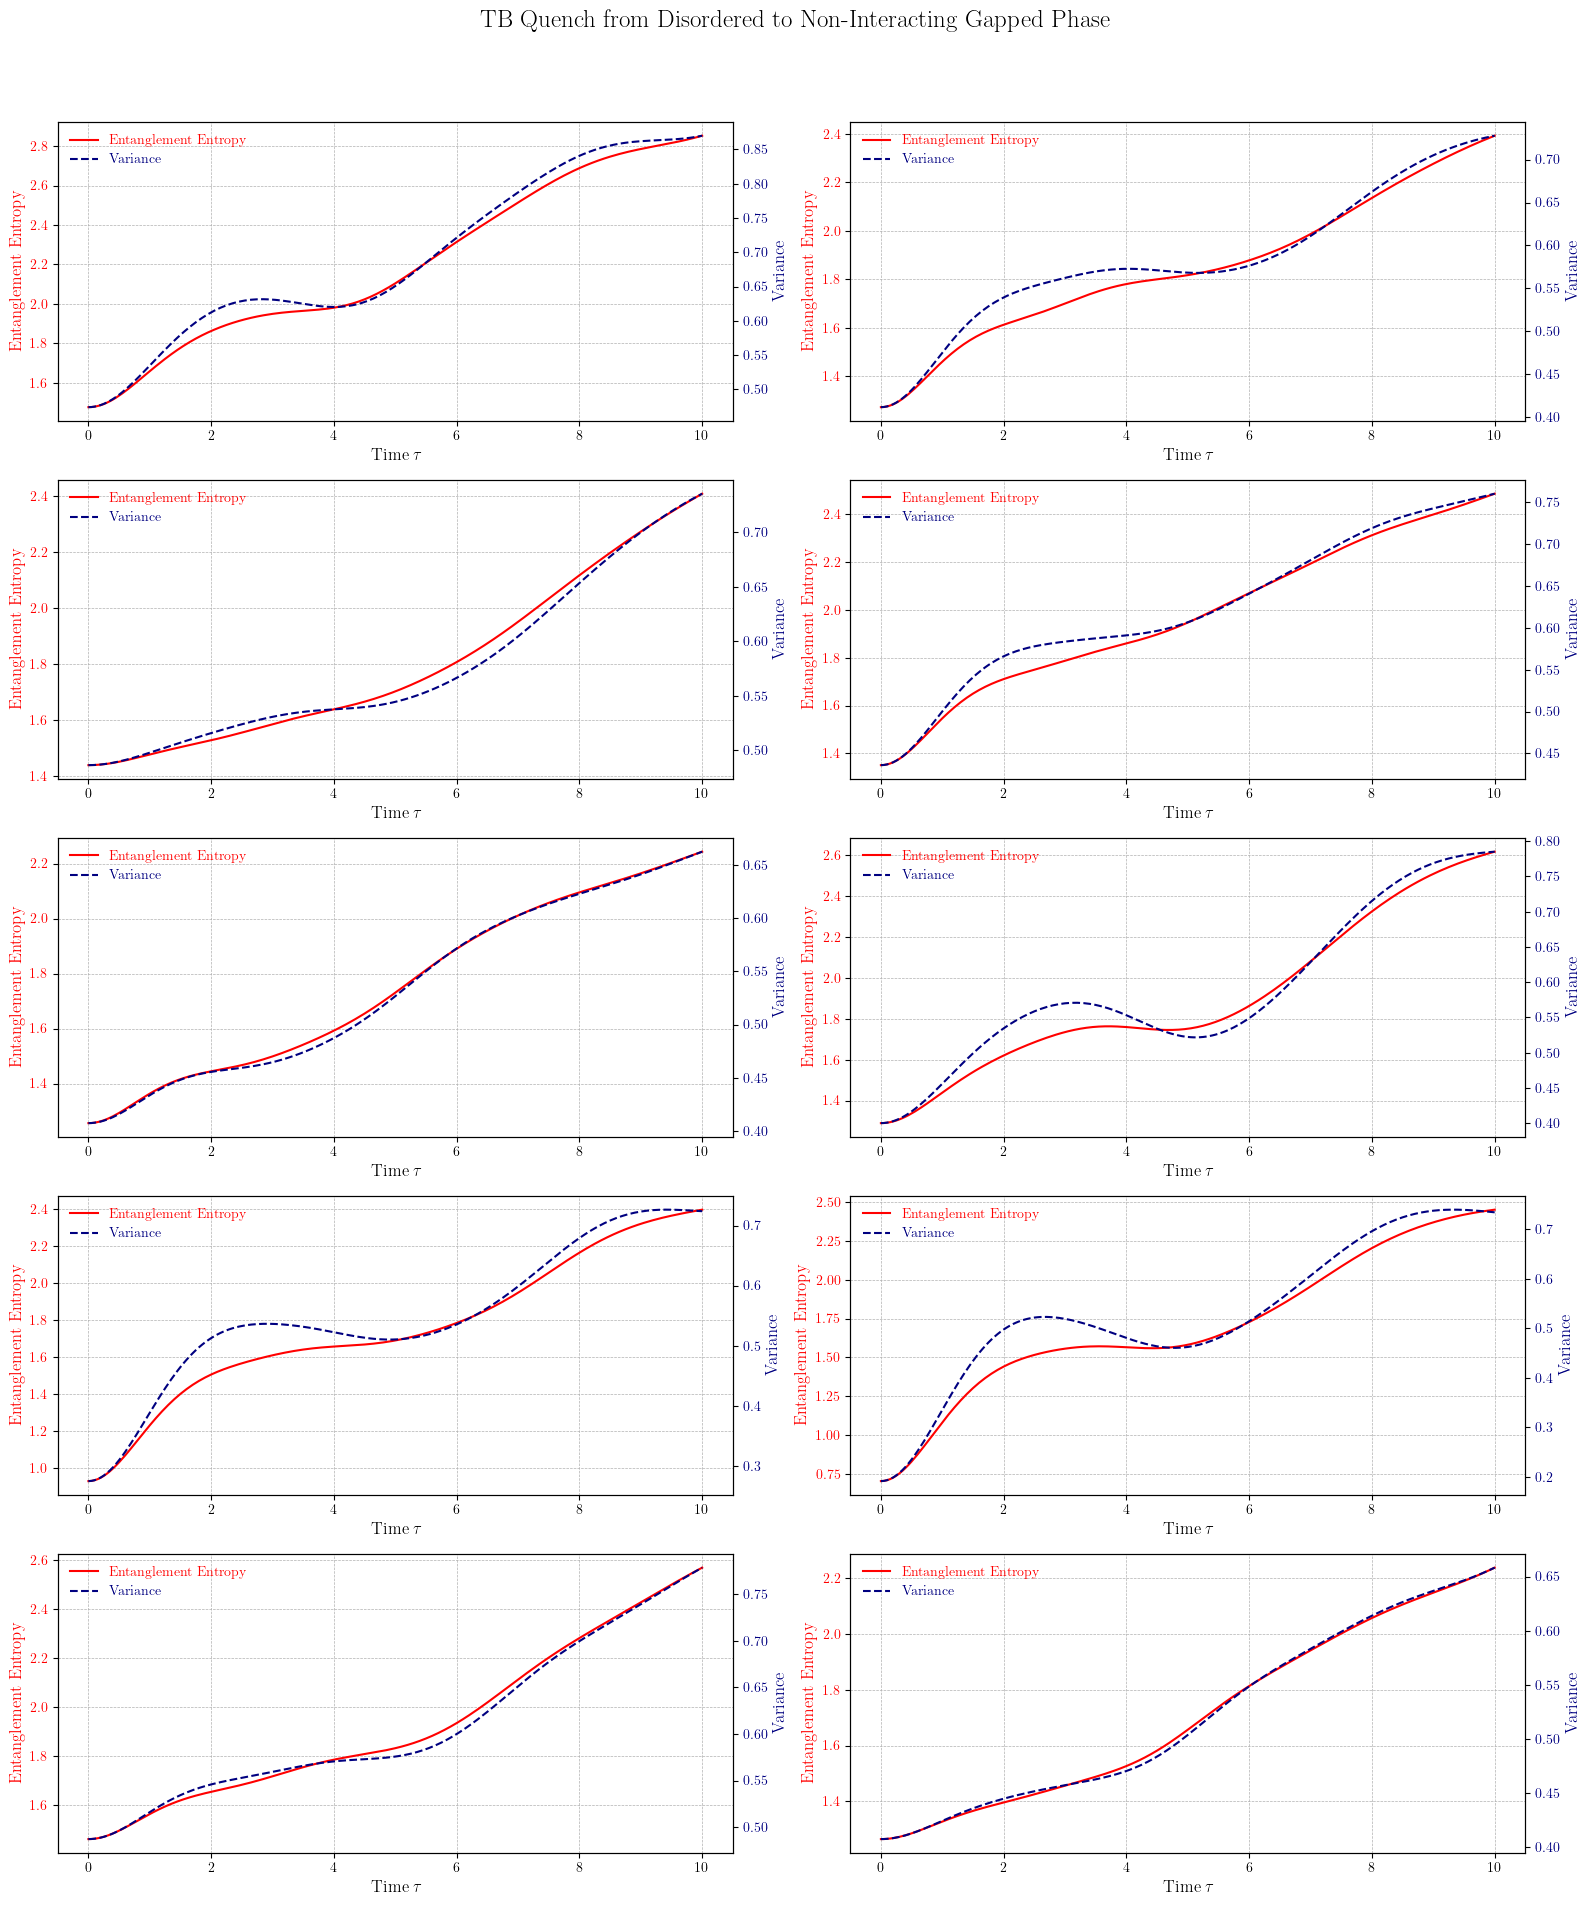

In [6]:
plot_quench_TB_disordered_to_gapped_whole_10_runs()

In [7]:
def plot_quench_results_inital_state_disordered_to_gapped():

    search_pattern = "run_TB_quench_disordered_to_non_interacting_gapped_200sites_10sec_BondDim1000_run*.csv"
    files = glob.glob(str(data_quench_dir / search_pattern))

    if not files:
        print("No files found matching the pattern.")
    else:
        print(f"Found {len(files)} files matching the pattern.")

    dataframes = [pd.read_csv(file) for file in files]
    combined_df = pd.concat(dataframes)

    average_df = combined_df.groupby('Time').mean().reset_index()

    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, = ax1.plot(average_df["Time"], average_df["Entropy"], color="red", label=r"Average Entanglement Entropy")
    l2, = ax2.plot(average_df["Time"], average_df["Variance"], color="navy", label=r"Average Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"TB Quench from Disordered to Non-Interacting Gapped Phase (Average over 10 Runs)", size=14)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    
    plt.savefig(plot_dir / "TB_quench_disordered_to_non_interacting_gapped_average_over_runs.pdf")
    plt.show()

Found 10 files matching the pattern.


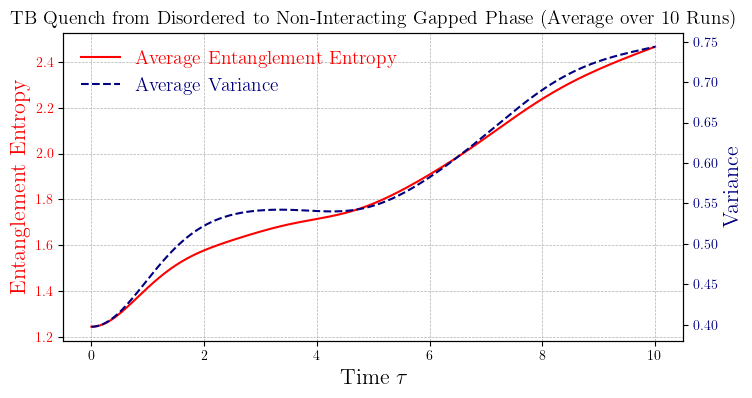

In [8]:
plot_quench_results_inital_state_disordered_to_gapped()

In [17]:
def plot_quench_LL_to_CDW():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_CDW_200sites_10sec_bonddim1700_cutoff1.0e-8.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    #l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    #l4 = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from LL to CDW $V_i = 1.0 \rightarrow V_f = 4.0$",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "LL_quench_from_LL_to_CDW.pdf")
    plt.show()

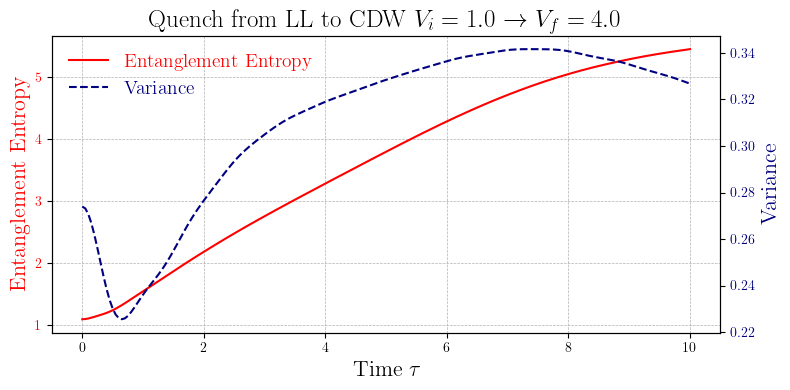

In [18]:
plot_quench_LL_to_CDW()

In [21]:
def plot_quench_CDW_to_CDW():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_CDW_to_CDW_200sites_10sec_bonddim1700_cutoff1.0e-8.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    #l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    #l4 = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from CDW to CDW $V_i = 5.0 \rightarrow V_f = 4.0$",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "LL_quench_from_CDW_to_CDW.pdf")
    plt.show()

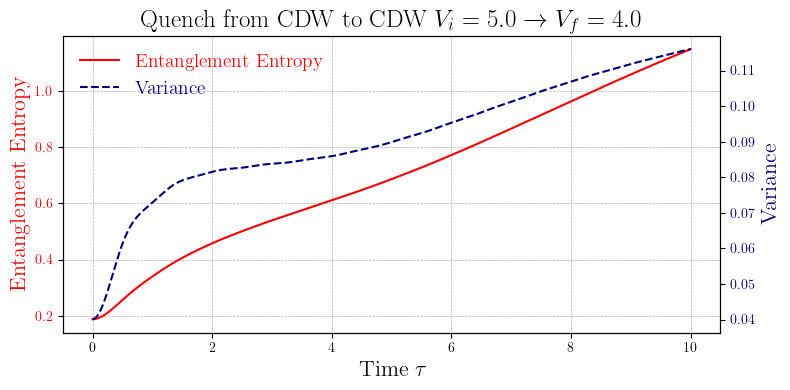

In [22]:
plot_quench_CDW_to_CDW()

In [19]:
def plot_quench_LL_to_CDW_5sec():
    # Load data 
    path = checkpoint_dir/"quench_from_LL_to_CDW.h5"

    # Extract data
    with h5py.File(path, "r") as f: 
        print(list(f.keys()))

        step = f["step"][()]
        t_final = f["t"][()]
        S_EE_vals = f["S_EE_vals"][:]
        F_vals = f["F_vals"][:]
        total_fidelity = f["total_fidelity"][()]
    
    dt = 0.05
    times = np.arange(len(S_EE_vals)) * dt

    print(f"checkpoint step: {step}, final time: {t_final}, total fidelity: {total_fidelity:.6f}")


    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(times, S_EE_vals, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(times, F_vals, color="navy", label=r"Variance", linestyle="--")
    #l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    #l4 = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from LL to CDW $V_i = 1.0 \rightarrow V_f = 4.0$",size=18)
    ax1.set_xlim(0, 10)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "LL_quench_from_LL_to_CDW_5sec.pdf")
    plt.show()

['F_vals', 'S_EE_vals', 'psi', 'step', 't', 'total_fidelity']
checkpoint step: 100, final time: 4.95, total fidelity: 0.998756


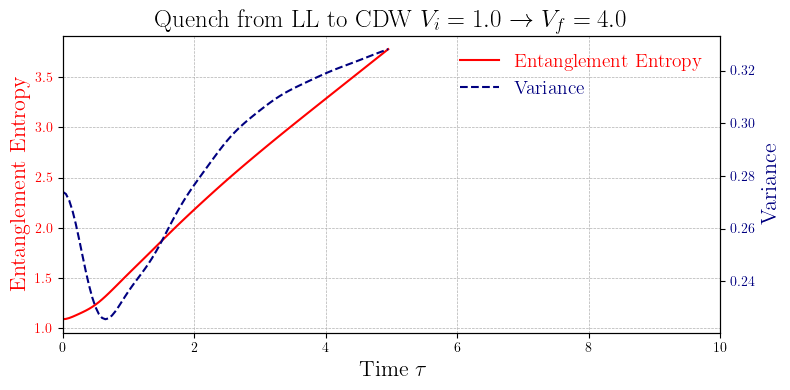

In [20]:
plot_quench_LL_to_CDW_5sec()

In [25]:
def plot_quench_LL_to_CDW_DV1():
    # Load data 
    path = checkpoint_dir/"quench_from_LL_to_CDW_deltaV1.h5"

    # Extract data
    with h5py.File(path, "r") as f: 
        print(list(f.keys()))

        step = f["step"][()]
        t_final = f["t"][()]
        S_EE_vals = f["S_EE_vals"][:]
        F_vals = f["F_vals"][:]
        total_fidelity = f["total_fidelity"][()]
    
    dt = 0.05
    times = np.arange(len(S_EE_vals)) * dt

    print(f"checkpoint step: {step}, final time: {t_final}, total fidelity: {total_fidelity:.6f}")


    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(times, S_EE_vals, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(times, F_vals, color="navy", label=r"Variance", linestyle="--")
    #l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    #l4 = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from LL to CDW $V_i = 1.5 \rightarrow V_f = 2.5$",size=18)
    ax1.set_xlim(0, 10)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "LL_quench_from_LL_to_CDW_deltaV1.pdf")
    plt.show()

['F_vals', 'S_EE_vals', 'psi', 'step', 't', 'total_fidelity']
checkpoint step: 140, final time: 6.95, total fidelity: 0.999478


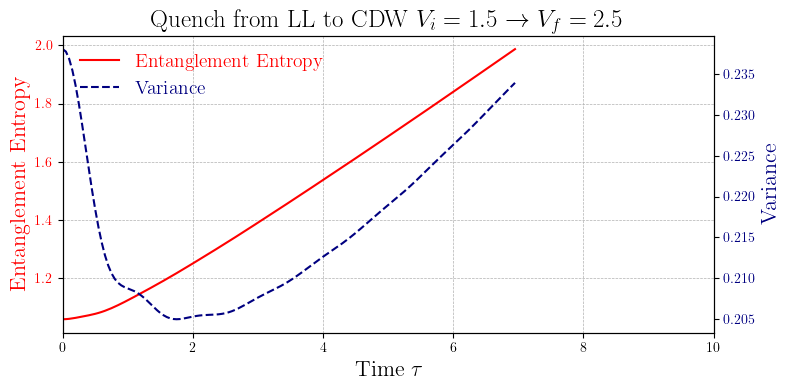

In [26]:
plot_quench_LL_to_CDW_DV1()

In [13]:
def plot_quench_SSH_to_SSH_10sec():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_SSH_free_quench_gapped_to_gapped_no_flux_L200cells_10sec.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    #l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    #l4 = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from SSH to SSH $v_i = 5.0 \rightarrow v_f = 1.0$",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "LL_quench_from_CDW_to_CDW.pdf")
    plt.show()

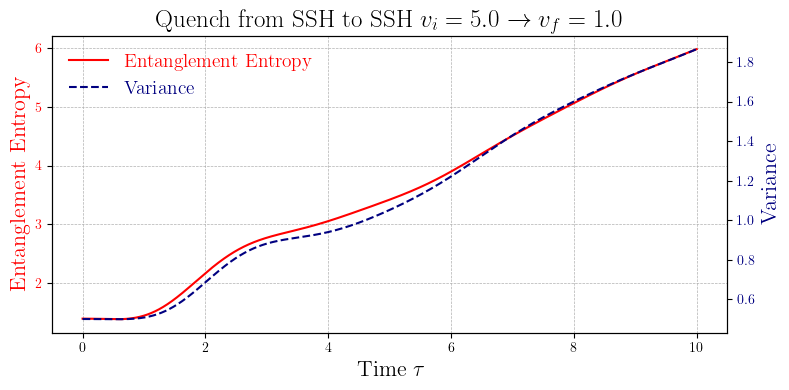

In [14]:
plot_quench_SSH_to_SSH_10sec()

In [141]:
def plot_quench_SSH_to_SSH_100sec():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_SSH_free_quench_gapped_to_gapped_no_flux_L200cells_100sec.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    #l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    #l4 = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from SSH to SSH $v_i = 5.0 \rightarrow v_f = 1.0$",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "LL_quench_from_CDW_to_CDW.pdf")
    plt.show()

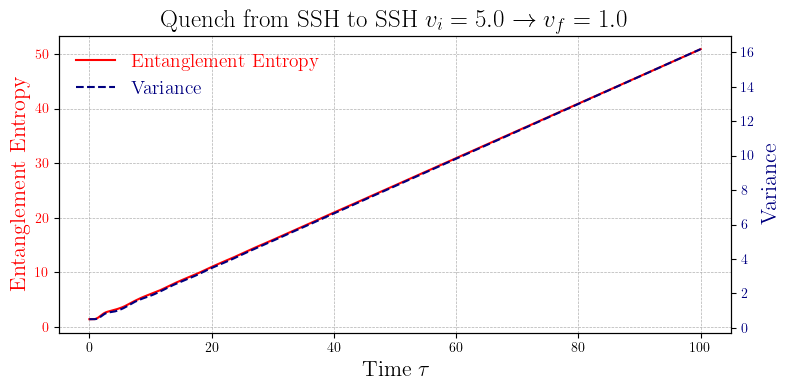

In [142]:
plot_quench_SSH_to_SSH_100sec()

In [21]:
def plot_quench_SSH_to_TB_10sec():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_SSH_free_quench_gapped_to_gapless_v99999_L100cells_10sec.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    #l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    #l4 = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from SSH gapped to TB gapless",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "quench_from_SSH_to_TB_10sec.pdf")
    plt.show()

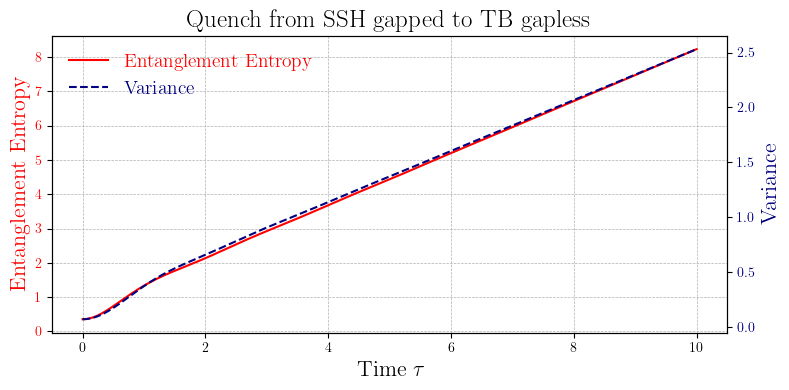

In [22]:
plot_quench_SSH_to_TB_10sec()

In [27]:
def plot_quench_SSH_to_TB_3sec():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_SSH_free_quench_gapped_to_gapless_v99999_L100cells_3sec.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    #l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    #l4 = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from SSH gapped to TB gapless",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "quench_from_SSH_to_TB_3sec.pdf")
    plt.show()

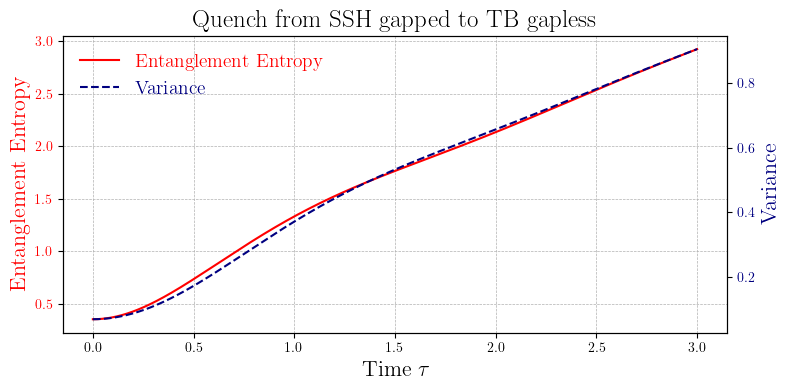

In [28]:
plot_quench_SSH_to_TB_3sec()

In [39]:
def plot_quench_SSH_to_TB_1sec():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_SSH_free_quench_gapped_to_gapless_v99999_L100cells_1sec.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    print(variance[3])

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])

    l1, = ax1.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    l2, = ax1.plot(time, 2*time**2, color="green", label=r"$2\tau^2$", linestyle=":")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from SSH gapped to TB gapless", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy", "green"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "quench_from_SSH_to_TB_1sec_variance.pdf")
    plt.show()

0.0693977993486737


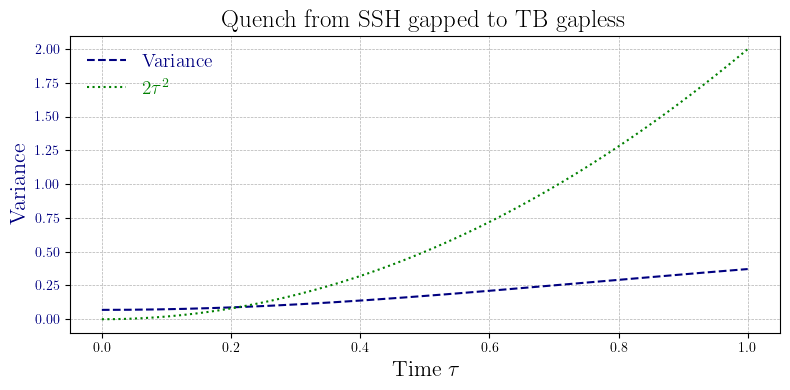

In [40]:
plot_quench_SSH_to_TB_1sec()

In [212]:
def plot_quench_CDW_to_CDW_increase_V_10sec():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_quench_from_CDW_to_CDW_increase_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l80.csv")

    # Extract data
    time = df["Time"].values
    variance = df["Variance"].values

    print(variance[3])

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])

    l1, = ax1.plot(time, variance, color="navy", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from CDW gapped to CDW $V_i = 4.0 \to V_f = 4.2$", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "quench_from_CDW_to_CDW_increase_V.pdf")
    plt.show()

0.1244947507348115


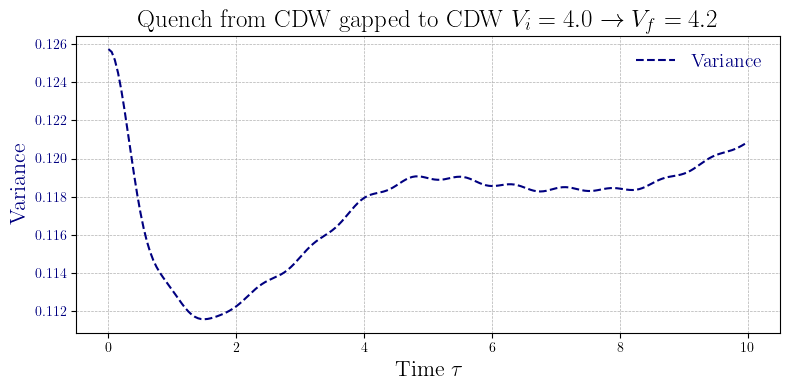

In [213]:
plot_quench_CDW_to_CDW_increase_V_10sec()

## Luttinger Liquid Quenches

In [11]:
def plot_quench_LL_to_LL_centered_subsystem_half():
    # Load data 
    path = checkpoint_dir/"quench_from_LL_to_LL_decrease_V_DV02_10.0_centered_subsystem.h5"

    # Extract data
    with h5py.File(path, "r") as f: 
        print(list(f.keys()))

        step = f["step"][()]
        t_final = f["t"][()]
        S_EE_vals = f["S_EE_vals"][:]
        F_vals = f["F_vals"][:]
        total_fidelity = f["total_fidelity"][()]
    
    dt = 0.05
    times = np.arange(len(S_EE_vals)) * dt

    print(f"checkpoint step: {step}, final time: {t_final}, total fidelity: {total_fidelity:.6f}")


    # Plotting
    fig = plt.figure(figsize=(8, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()
    ax3 = fig.add_subplot(spec[1, 0])

    l1, =ax1.plot(times, S_EE_vals, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(times, F_vals, color="navy", label=r"Variance", linestyle="--")
    #l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    #l4 = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from LL to LL $V_i = 0.7 \rightarrow V_f = 0.5$",size=18)
    ax1.set_xlim(0, 10)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    
    l3, = ax3.semilogx(times, F_vals, color="navy", label=r"Variance", linestyle="--")
    ax3.set_xlabel(r"$\log \tau$", size=16)
    ax3.set_ylabel(r"Variance", color="navy", size=16)
    ax3.tick_params(axis="y", labelcolor="navy")
    ax3.set_title(r"Variance in log scale",size=18)
    ax3.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax3.legend(handles=[l3], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy"]):
        text.set_color(color)

    plt.tight_layout()
    plt.savefig(plot_dir / "LL_quench_from_LL_to_LL_decrease_V_DV02_10.0_centered_subsystem.pdf")
    plt.show()

['F_vals', 'S_EE_vals', 'psi', 'step', 't', 'total_fidelity']
checkpoint step: 200, final time: 9.95, total fidelity: 0.999370


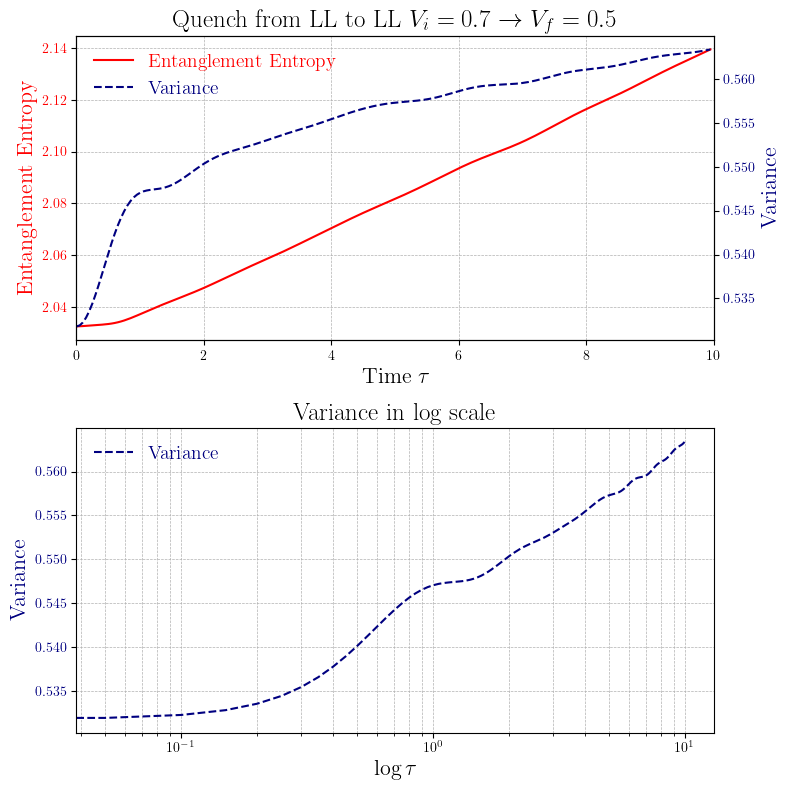

In [12]:
plot_quench_LL_to_LL_centered_subsystem_half()

In [278]:
def plot_quench_LL_to_LL_centered_subsystem_l40():
    # Load data 
    path = checkpoint_dir/"quench_from_LL_to_LL_decrease_V_DV02_10.0_centered_subsystem_l40.h5"

    # Extract data
    with h5py.File(path, "r") as f: 
        print(list(f.keys()))

        step = f["step"][()]
        t_final = f["t"][()]
        S_EE_vals = f["S_EE_vals"][:]
        F_vals = f["F_vals"][:]
        total_fidelity = f["total_fidelity"][()]
    
    dt = 0.05
    times = np.arange(len(S_EE_vals)) * dt

    print(f"checkpoint step: {step}, final time: {t_final}, total fidelity: {total_fidelity:.6f}")


    # Plotting
    fig = plt.figure(figsize=(8, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()
    ax3 = fig.add_subplot(spec[1, 0])

    l1, =ax1.plot(times, S_EE_vals, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(times, F_vals, color="navy", label=r"Variance", linestyle="--")
    #l3, = ax2.plot(time, entropy/variance, color="green", label=r"$S/\Delta N_A^2$", linestyle=":")
    #l4 = ax2.axhline(y = np.pi**2/3, color="black", linestyle=":", label=r"$\pi^2/3$")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from LL to LL $V_i = 0.7 \rightarrow V_f = 0.5$, $L = 40$",size=18)
    ax1.set_xlim(0, 10)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "navy"]):
        text.set_color(color)
    
    l3, = ax3.semilogx(times, F_vals, color="navy", label=r"Variance", linestyle="--")
    ax3.set_xlabel(r"$\log \tau$", size=16)
    ax3.set_ylabel(r"Variance", color="navy", size=16)
    ax3.tick_params(axis="y", labelcolor="navy")
    ax3.set_title(r"Variance in log scale",size=18)
    ax3.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax3.legend(handles=[l3], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy"]):
        text.set_color(color)

    plt.tight_layout()
    plt.savefig(plot_dir / "LL_quench_from_LL_to_LL_decrease_V_DV02_10.0_centered_subsystem_l40.pdf")
    plt.show()

['F_vals', 'S_EE_vals', 'psi', 'step', 't', 'total_fidelity']
checkpoint step: 200, final time: 9.95, total fidelity: 0.999370


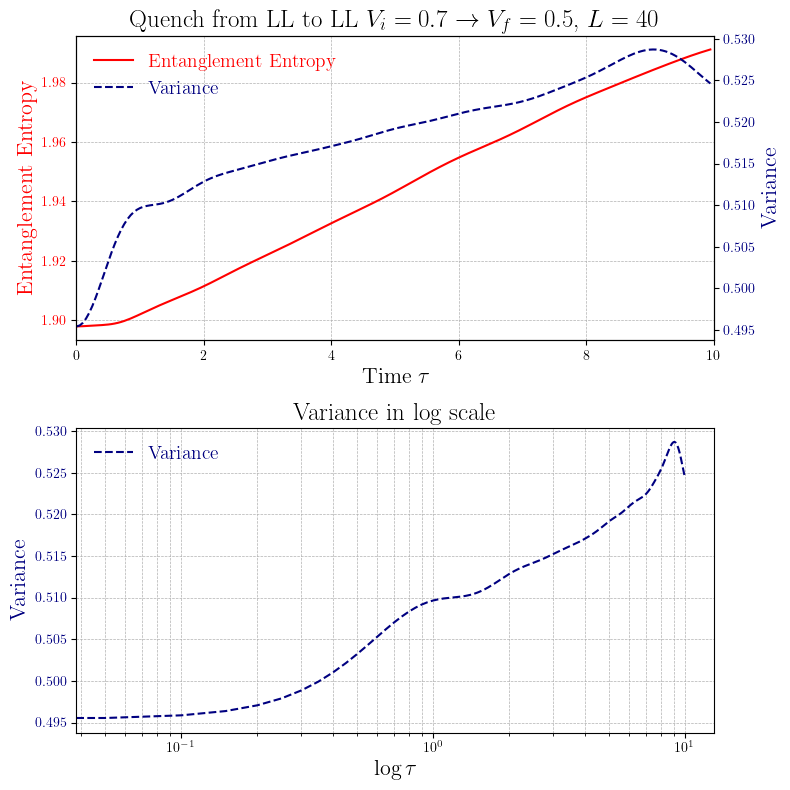

In [279]:
plot_quench_LL_to_LL_centered_subsystem_l40()

In [154]:
def plot_comparison_variation_of_fluctuations_subsystem_different_sizes():
    path1 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l30.csv"
    path2 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l40.csv"
    path2_1 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l46.csv"
    path3 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l50.csv"
    path3_1 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_300sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l54.csv"
    path4 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l60.csv"
    path5 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l70.csv"
    path6 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l80.csv"
    path7 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l90.csv"
    # Load data
    df1 = pd.read_csv(path1)
    df2 = pd.read_csv(path2)
    df2_1 = pd.read_csv(path2_1)
    df3 = pd.read_csv(path3)
    df3_1 = pd.read_csv(path3_1)
    df4 = pd.read_csv(path4)
    df5 = pd.read_csv(path5)
    df6 = pd.read_csv(path6)
    df7 = pd.read_csv(path7)
    # subtracting the first value of the fluctuations to make the initial value zero for comparison
    df1["Variance"] -= df1["Variance"].iloc[0]
    df2["Variance"] -= df2["Variance"].iloc[0]
    df2_1["Variance"] -= df2_1["Variance"].iloc[0]
    df3["Variance"] -= df3["Variance"].iloc[0]
    df3_1["Variance"] -= df3_1["Variance"].iloc[0]
    df4["Variance"] -= df4["Variance"].iloc[0]
    df5["Variance"] -= df5["Variance"].iloc[0]
    df6["Variance"] -= df6["Variance"].iloc[0]
    df7["Variance"] -= df7["Variance"].iloc[0]

    # removing the first row of every dataframe to avoid the initial value at time 0
    df1 = df1.iloc[1:]
    df2 = df2.iloc[1:]
    df2_1 = df2_1.iloc[1:]
    df3 = df3.iloc[1:]
    df3_1 = df3_1.iloc[1:]
    df4 = df4.iloc[1:]
    df5 = df5.iloc[1:]
    df6 = df6.iloc[1:]
    df7 = df7.iloc[1:]

    #theoretical data
    mu_i = np.arccos(0.7 / 2.0)
    mu_f = np.arccos(0.5 / 2.0)

    K_i = np.pi / (2 * (np.pi - mu_i))
    K_f = np.pi / (2 * (np.pi - mu_f))

    u_f = np.pi * np.sin(mu_f) / (mu_f)

    B_param = 0.5 * (K_i**2 - K_f**2)/(K_i * K_f)

    print(f"mu_i: {mu_i}, mu_f: {mu_f}, K_i: {K_i}, K_f: {K_f}, u_f: {u_f}, B_param: {B_param}")

    m_theory = -B_param * K_f / (np.pi**2)
    mask = (df4["Time"] > 4.0) & (df4["Time"] < 8.0)
    t_fit = df4["Time"][mask]
    variance_fit = df4["Variance"][mask]

    x_data = np.log(t_fit)
    y_data = variance_fit

    m_fit, q_fit, r_value, p_value, std_err = linregress(x_data, y_data)

    error_percentage = np.abs((m_fit - m_theory) / m_theory) * 100

    print(f" --- Fit results ---")
    print(f"Fit slope: {m_fit:.5f}")
    print(f"Theoretical slope: {m_theory:.5f}")
    print(f"Error percentage: {error_percentage:.2f}%")
    print(f"R-squared: {r_value**2:.5f}")

    t_line = np.linspace(0.5, 10.0, 200)
    fit_curve = m_fit * np.log(t_line) + q_fit
    theory_curve = m_theory * np.log(t_line) + q_fit


    # Plotting
    fig = plt.figure(figsize=(8, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = fig.add_subplot(spec[1, 0])

    l1, = ax1.plot(df1["Time"], df1["Variance"], color="navy", label=r"Variance $L = 30$", linestyle="--")
    l2, = ax1.plot(df2["Time"], df2["Variance"], color="green", label=r"Variance $L = 40$", linestyle="--")
    l2_1, = ax1.plot(df2_1["Time"], df2_1["Variance"], color="cyan", label=r"Variance $L = 46$", linestyle="--")
    l3, = ax1.plot(df3["Time"], df3["Variance"], color="red", label=r"Variance $L = 50$", linestyle="--")
    l3_1, = ax1.plot(df3_1["Time"], df3_1["Variance"], color="magenta", label=r"Variance $L = 54$", linestyle="--")
    l4, = ax1.plot(df4["Time"], df4["Variance"], color="purple", label=r"Variance $L = 60$", linestyle="--")
    l5, = ax1.plot(df5["Time"], df5["Variance"], color="orange", label=r"Variance $L = 70$", linestyle="--")
    l6, = ax1.plot(df6["Time"], df6["Variance"], color="brown", label=r"Variance $L = 80$", linestyle="--")
    l7, = ax1.plot(df7["Time"], df7["Variance"], color="gray", label=r"Variance $L = 90$", linestyle="--")
    l_fit, = ax1.plot(t_line, fit_curve, color="black", label=r"Fit: $\Delta F(t) = m \log t + q$", linestyle="-")
    l_theory, = ax1.plot(t_line, theory_curve, color="lightgray", label=r"Theory: $\Delta F(t) = m_{theory} \log t + q$", linestyle=":")

    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"$\Delta F(t)$", color="black", size=16)
    ax1.tick_params(axis="y", labelcolor="black")
    ax1.set_title(r"Comparison of Variance for Different Subsystem Sizes", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2, l2_1, l3, l3_1, l4, l5, l6, l7, l_fit, l_theory], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy", "green", "cyan", "red", "magenta", "purple", "orange", "brown", "gray", "black", "lightgray"]):
        text.set_color(color)
    
    l8, = ax2.semilogx(df1["Time"], df1["Variance"], color="navy", label=r"Variance $L = 30$", linestyle="--")
    l9, = ax2.semilogx(df2["Time"], df2["Variance"], color="green", label=r"Variance $L = 40$", linestyle="--")
    l8_1, = ax2.semilogx(df2_1["Time"], df2_1["Variance"], color="cyan", label=r"Variance $L = 46$", linestyle="--")
    l10, = ax2.semilogx(df3["Time"], df3["Variance"], color="red", label=r"Variance $L = 50$", linestyle="--")
    l10_1, = ax2.semilogx(df3_1["Time"], df3_1["Variance"], color="magenta", label=r"Variance $L = 54$", linestyle="--")
    l11, = ax2.semilogx(df4["Time"], df4["Variance"], color="purple", label=r"Variance $L = 60$", linestyle="--")
    l12, = ax2.semilogx(df5["Time"], df5["Variance"], color="orange", label=r"Variance $L = 70$", linestyle="--")
    l13, = ax2.semilogx(df6["Time"], df6["Variance"], color="brown", label=r"Variance $L = 80$", linestyle="--")
    l14, = ax2.semilogx(df7["Time"], df7["Variance"], color="gray", label=r"Variance $L = 90$", linestyle="--")
    l_fit_log, = ax2.semilogx(t_line, fit_curve, color="black", label=r"Fit: $\Delta F(t) = m \log t + q$", linestyle="-")
    l_theory_log, = ax2.semilogx(t_line, theory_curve, color="lightgray", label=r"Theory: $\Delta F(t) = m_{theory} \log t + q$", linestyle=":")

    ax2.set_xlabel(r"$\log \tau$", size=16)
    ax2.set_ylabel(r"$\Delta F(t)$", color="black", size=16)
    ax2.tick_params(axis="y", labelcolor="black")
    ax2.set_title(r"Comparison of Variance for Different Subsystem Sizes (Log Scale)", size=18)
    ax2.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax2.legend(handles=[l8, l9, l8_1, l10, l10_1, l11, l12, l13, l14, l_fit_log, l_theory_log], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy", "green", "cyan", "red", "magenta", "purple", "orange", "brown", "gray", "black", "lightgray"]):
        text.set_color(color)
    
    plt.tight_layout()
    plt.savefig(plot_dir / "comparison_variation_of_fluctuations_subsystem_different_sizes.pdf")
    plt.show()

    for l, df in zip([30,40,46,50,54,60,70,80,90], [df1,df2,df2_1,df3,df3_1,df5,df6, df7]):
        t_l = l/(2*u_f)
        mask = (df["Time"]>1.0) & (df["Time"]<0.3*t_l)
        m_fit,_,r,_,_ = linregress(np.log(df["Time"][mask]), df["Variance"][mask])
        print(f"l={l}: t_l={t_l:.1f}, fit window up to {0.3*t_l:.1f}, "
             f"m_fit={m_fit:.5f}, diff={100*abs(m_fit-m_theory)/m_theory:.1f}%")
    
    mask_common = (df["Time"] > 1.0) & (df["Time"] < 4.0)  # same window, every l
    print("second check, same window for every l")
    for l, df in zip([30,40,46,50,54,60,70,80,90], [df1,df2,df2_1,df3,df3_1,df5,df6,df7]):
        m_fit, *_ = linregress(np.log(df["Time"][mask_common]), df["Variance"][mask_common])
        print(f"l={l}: m_fit={m_fit:.5f}, diff={100*abs(m_fit-m_theory)/m_theory:.1f}%")

mu_i: 1.2132252231493863, mu_f: 1.318116071652818, K_i: 0.8145731472119673, K_f: 0.8614293939143047, u_f: 2.307713313263815, B_param: -0.05595802766847076
 --- Fit results ---
Fit slope: 0.00767
Theoretical slope: 0.00488
Error percentage: 57.13%
R-squared: 0.99579


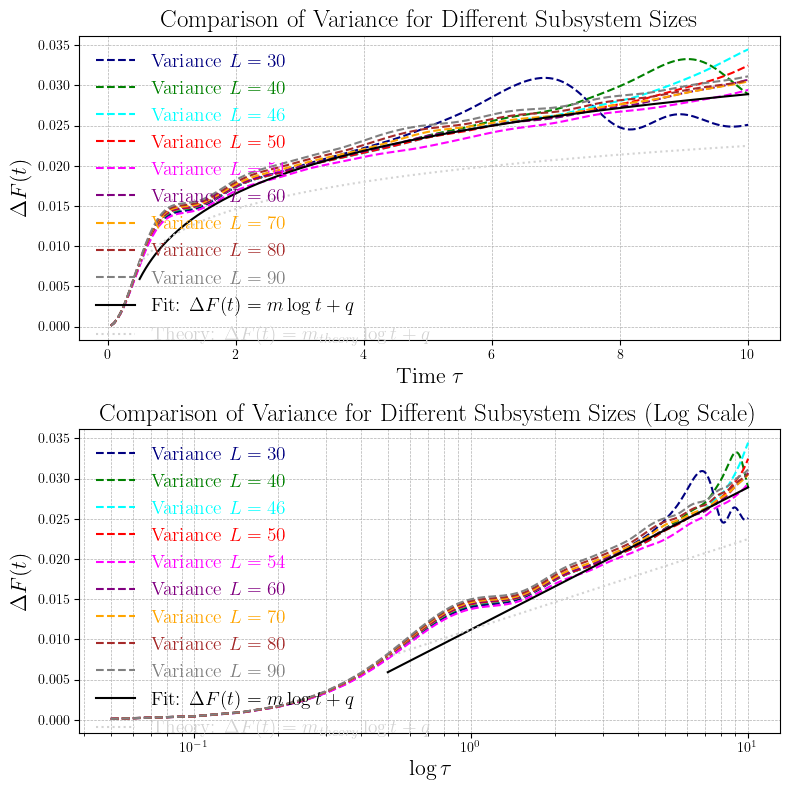

l=30: t_l=6.5, fit window up to 1.9, m_fit=0.00455, diff=6.9%
l=40: t_l=8.7, fit window up to 2.6, m_fit=0.00580, diff=18.7%
l=46: t_l=10.0, fit window up to 3.0, m_fit=0.00578, diff=18.3%
l=50: t_l=10.8, fit window up to 3.2, m_fit=0.00579, diff=18.6%
l=54: t_l=11.7, fit window up to 3.5, m_fit=0.00589, diff=20.5%
l=60: t_l=13.0, fit window up to 3.9, m_fit=0.00610, diff=24.9%
l=70: t_l=15.2, fit window up to 4.5, m_fit=0.00655, diff=34.0%
l=80: t_l=17.3, fit window up to 5.2, m_fit=0.00705, diff=44.3%
second check, same window for every l
l=30: m_fit=0.00655, diff=34.1%
l=40: m_fit=0.00601, diff=23.1%
l=46: m_fit=0.00591, diff=21.1%
l=50: m_fit=0.00589, diff=20.6%
l=54: m_fit=0.00594, diff=21.6%
l=60: m_fit=0.00612, diff=25.2%
l=70: m_fit=0.00630, diff=29.0%
l=80: m_fit=0.00651, diff=33.2%


In [517]:
plot_comparison_variation_of_fluctuations_subsystem_different_sizes()

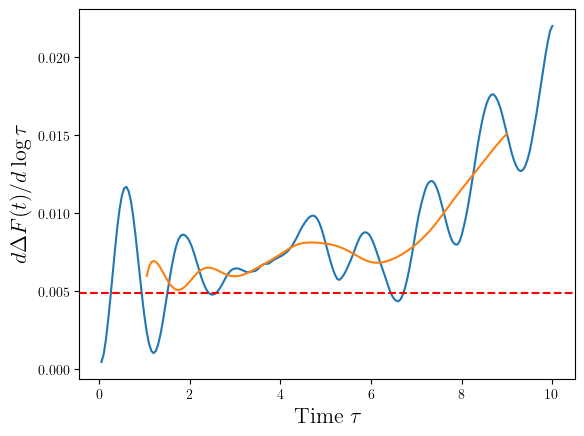

In [155]:
path4 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l60.csv"
df4 = pd.read_csv(path4)

t = df4["Time"].values
t = t[1:]  # Remove the first value to avoid log(0)

# Added .copy() to make the array writable
variance = df4["Variance"].values.copy()
variance -= variance[0]  # Subtract the initial value to make it zero at t=0
variance = variance[1:]  # Remove the first value

logt = np.log(t)
local_slope = np.gradient(variance, logt)

plt.plot(t, local_slope)
plt.axhline(y=0.00488, color="red", linestyle="--", label="Theoretical slope")
plt.xlabel(r"Time $\tau$", size=16)
plt.ylabel(r"$d\Delta F(t)/d\log\tau$", size=16)

window = 20  # ~1.0 time unit of points, adjust to taste
slopes = []
t_centers = []
for i in range(window, len(t) - window):
    tt = logt[i-window:i+window]
    ff = variance[i-window:i+window]
    m, *_ = linregress(tt, ff)
    slopes.append(m)
    t_centers.append(t[i])

plt.plot(t_centers, slopes)

In [144]:
def plot_for_finding_the_best_size_for_fit_variances():
    path1 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l40.csv"
    path2 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l46.csv"
    path3 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l50.csv"
    path4 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_300sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l54.csv"
    path5 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l60.csv"

    # Load data
    df1 = pd.read_csv(path1)
    df2 = pd.read_csv(path2)
    df3 = pd.read_csv(path3)   
    df4 = pd.read_csv(path4)
    df5 = pd.read_csv(path5)

    # subtracting the first value of the fluctuations to make the initial value zero for comparison
    df1["Variance"] -= df1["Variance"].iloc[0]
    df2["Variance"] -= df2["Variance"].iloc[0]
    df3["Variance"] -= df3["Variance"].iloc[0]
    df4["Variance"] -= df4["Variance"].iloc[0]
    df5["Variance"] -= df5["Variance"].iloc[0]

    # removing the first row of every dataframe to avoid the initial value at time 0
    df1 = df1.iloc[1:]
    df2 = df2.iloc[1:]
    df3 = df3.iloc[1:]
    df4 = df4.iloc[1:]
    df5 = df5.iloc[1:]  

    #theoretical data
    mu_i = np.arccos(0.7 / 2.0)
    mu_f = np.arccos(0.5 / 2.0)

    K_i = np.pi / (2 * (np.pi - mu_i))
    K_f = np.pi / (2 * (np.pi - mu_f))

    u_f = np.pi * np.sin(mu_f) / (mu_f)

    B_param = 0.5 * (K_i**2 - K_f**2)/(K_i * K_f)
    m_theory = -B_param * K_f / (np.pi**2)

    for l, df in zip([40,46,50,54,60], [df1,df2,df3,df4,df5]):
        t_l = l/(2*u_f)
        mask = (df["Time"]>1.0) & (df["Time"]<0.3*t_l)
        m_fit,_,r,_,_ = linregress(np.log(df["Time"][mask]), df["Variance"][mask])
        print(f"l={l}: t_l={t_l:.1f}, fit window up to {0.3*t_l:.1f}, "
             f"m_fit={m_fit:.5f}, diff={100*abs(m_fit-m_theory)/m_theory:.1f}%")
    
    mask_common = (df["Time"] > 2.0) & (df["Time"] < 3.0)  # same window, every l
    print("second check, same window for every l")
    for l, df in zip([40,46,50,54,60], [df1,df2,df3,df4,df5]):
        m_fit, *_ = linregress(np.log(df["Time"][mask_common]), df["Variance"][mask_common])
        print(f"l={l}: m_fit={m_fit:.5f}, diff={100*abs(m_fit-m_theory)/m_theory:.1f}%")

    


In [125]:
def plot_variations_fluctuations_l80_for_fit():
    path = (
        data_quench_dir
        / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_sites200_time10.0_bonddim2400_cutoff1.0e-10_centered_subsystem_l80.csv"
    )
    df = pd.read_csv(path)

    path_500 = (
            data_quench_dir
            / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_sites500_time8.0_bonddim1800_cutoff1.0e-10_centered_subsystem_l80.csv"
        )
    df = pd.read_csv(path_500)

    path_larger = data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_sites400_time10.0_bonddim2400_cutoff1.0e-10_centered_subsystem_l80.csv"
    path_convergence_2 = data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_sites400_time10.0_bonddim2500_cutoff1.0e-10_centered_subsystem_l80.csv"
    path_convergence_1 = data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_sites400_time10.0_bonddim2200_cutoff1.0e-10_centered_subsystem_l80.csv"

    df_larger = pd.read_csv(path_larger)
    df_convergence_1 = pd.read_csv(path_convergence_1)
    df_convergence_2 = pd.read_csv(path_convergence_2)

    # Subtract initial value and drop time 0
    df["Variance"] -= df["Variance"].iloc[0]
    df = df.iloc[1:]

    df_larger["Variance"] -= df_larger["Variance"].iloc[0]
    df = df.iloc[1:]

    df_convergence_1["Variance"] -= df_convergence_1["Variance"].iloc[0]
    df_convergence_1 = df_convergence_1.iloc[1:]

    df_convergence_2["Variance"] -= df_convergence_2["Variance"].iloc[0]
    df_convergence_2 = df_convergence_2.iloc[1:]

    # Theoretical parameters
    mu_i = np.arccos(0.7 / 2.0)
    mu_f = np.arccos(0.5 / 2.0)

    K_i = np.pi / (2 * (np.pi - mu_i))
    K_f = np.pi / (2 * (np.pi - mu_f))

    u_f = np.pi * np.sin(mu_f) / mu_f

    B_param = 0.5 * (K_i**2 - K_f**2) / (K_i * K_f)
    m_theory = -B_param * K_f / (np.pi**2)

    t_l = 80 / (2 * u_f)

    # --- Small system ---
    # Perform Fit
    mask1 = (df["Time"] > 1.0) & (df["Time"] < 6.0)
    t_fit = df["Time"][mask1]
    var_fit = df["Variance"][mask1]

    x_data = np.log(t_fit)
    y_data = var_fit
    m_fit, q_fit, r_value, p_value, std_err = linregress(x_data, y_data)

    error_percentage = abs(m_fit - m_theory) / m_theory * 100

    # Curves for plotting
    t_line = np.linspace(0.5, 10, 200)
    fit_curve = m_fit * np.log(t_line) + q_fit
    theory_curve = m_theory * np.log(t_line) + q_fit

    # --- Large system ---
    mask2 = (df_larger["Time"] > 2.0) & (df_larger["Time"] < 6.0)
    t_fit_larger = df_larger["Time"][mask2]
    var_fit_larger = df_larger["Variance"][mask2]

    x_data_larger = np.log(t_fit_larger)
    y_data_larger = var_fit_larger
    m_fit_larger, q_fit_larger, r_value_larger, p_value_larger, std_err_larger = linregress(x_data_larger, y_data_larger)

    error_percentage_larger = abs(m_fit_larger - m_theory) / m_theory * 100

    # Curves for plotting
    t_line = np.linspace(0.5, 10, 200)
    fit_curve = m_fit * np.log(t_line) + q_fit
    theory_curve = m_theory * np.log(t_line) + q_fit

    fit_curve_larger = m_fit_larger * np.log(t_line) + q_fit_larger
    theory_curve_larger = m_theory * np.log(t_line) + q_fit_larger

    # --- Styling Settings ---
    c_data = "#0D3B66"  # Deep Navy
    c_fit = "#D62728"  # Crimson Red (high contrast against data)
    c_theory = "#2B2D42"  # Dark Slate/Charcoal

    fig = plt.figure(figsize=(16, 16))
    spec = gridspec.GridSpec(ncols=2, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = fig.add_subplot(spec[1, 0])
    ax3 = fig.add_subplot(spec[0, 1])
    ax4 = fig.add_subplot(spec[1, 1])    


    # --- Top-left Plot: Linear Scale ---
    ax1.plot(
        df["Time"], df["Variance"], color=c_data, label=r"Simulation data", lw=3.5
    )
    ax1.plot(
        t_line,
        fit_curve,
        color=c_fit,
        label=r"Fit: $\Delta F(t) = m_{\text{fit}}\ln \tau + q_{\text{fit}}$",
        lw=3,
        linestyle="--",
    )
    ax1.plot(
        t_line,
        theory_curve,
        color=c_theory,
        label=r"Theory: $\Delta F(t) = m_{\text{theory}}\ln \tau + q_{\text{fit}}$",
        lw=3,
        linestyle=":",
    )

    ax1.set_title(
        r"$\Delta F(t)$ for $l=80$ and $L=200$",
        fontsize=28,
        pad=10,
    )
    ax1.set_xlabel(r"$\tau$", fontsize=24)
    ax1.set_ylabel(r"$\Delta F(t)$", fontsize=24)
    ax1.grid(True, which="both", linestyle="--", alpha=0.5)
    ax1.tick_params(axis="both", labelcolor="black", labelsize= 20)

    # Shared Legend on top plot
    ax1.legend(
        loc="lower right",
        fontsize=18,
        frameon=True,
        facecolor="white",
        edgecolor="#cccccc",
    )

    # --- Bottom-left Plot: Log Scale ---
    ax2.semilogx(df["Time"], df["Variance"], color=c_data, lw=3.5)
    ax2.semilogx(t_line, fit_curve, color=c_fit, lw=3, linestyle="--")
    ax2.semilogx(t_line, theory_curve, color=c_theory, lw=3, linestyle=":")

    ax2.set_xlabel(r"$\tau$ (log scale)", fontsize=24)
    ax2.set_ylabel(r"$\Delta F(t)$", fontsize=24)
    ax2.grid(True, which="both", linestyle="--", alpha=0.5)
    ax2.tick_params(axis="both", labelcolor="black", labelsize= 20)

    # --- Fit Results Box (Placed in empty top-left space of ax2) ---
    stats_text = (
        r"\textbf{Fit Results}"
        + "\n"
        + f"$m_\\text{{fit}} = {m_fit:.5f}$\n"
        + f"$m_\\text{{theory}} = {m_theory:.5f}$\n"
        + f"Diff: ${error_percentage:.2f}\\%$\n"
        + f"$R^2 = {r_value**2:.4f}$"
    )

    bbox_props = dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#b0b0b0",
        alpha=0.9,
    )
    ax2.text(
        0.04,
        0.92,
        stats_text,
        transform=ax2.transAxes,
        fontsize=20,
        verticalalignment="top",
        bbox=bbox_props,
    )

    # ---------------------------------------------------------------

    # --- Top-right Plot: Linear Scale ---    
    ax3.plot(
        df_larger["Time"], df_larger["Variance"], color=c_data, label=r"Simulation data (bd=2400)", lw=3.5
    )

    ax3.plot(df_convergence_1["Time"], df_convergence_1["Variance"], label=r"Simulation data (bd=2200)")
    ax3.plot(df_convergence_2["Time"], df_convergence_2["Variance"], label=r"Simulation data (bd=2500)")

    ax3.plot(
        t_line,
        fit_curve_larger,
        color=c_fit,
        label=r"Fit: $\Delta F(t) = m_{\text{fit}}\ln \tau + q_{\text{fit}}$",
        lw=3,
        linestyle="--",
    )
    ax3.plot(
        t_line,
        theory_curve_larger,
        color=c_theory,
        label=r"Theory: $\Delta F(t) = m_{\text{theory}}\ln \tau + q_{\text{fit}}$",
        lw=3,
        linestyle=":",
    )

    ax3.set_title(
        r"$\Delta F(t)$ for $l=80$ and $L=400$",
        fontsize=28,
        pad=10,
    )
    ax3.set_xlabel(r"$\tau$", fontsize=24)
    ax3.set_ylabel(r"$\Delta F(t)$", fontsize=24)
    ax3.grid(True, which="both", linestyle="--", alpha=0.5)
    ax3.tick_params(axis="both", labelcolor="black", labelsize= 20)

    # Shared Legend on top plot
    ax3.legend(
        loc="lower right",
        fontsize=18,
        frameon=True,
        facecolor="white",
        edgecolor="#cccccc",
    )

    # --- Bottom-right Plot: Log Scale ---
    ax4.semilogx(df_larger["Time"], df_larger["Variance"], color=c_data, lw=3.5)
    ax4.semilogx(t_line, fit_curve_larger, color=c_fit, lw=3, linestyle="--")
    ax4.semilogx(t_line, theory_curve_larger, color=c_theory, lw=3, linestyle=":")

    ax4.set_xlabel(r"$\tau$ (log scale)", fontsize=24)
    ax4.set_ylabel(r"$\Delta F(t)$", fontsize=24)
    ax4.grid(True, which="both", linestyle="--", alpha=0.5)
    ax4.tick_params(axis="both", labelcolor="black", labelsize= 20)

    # --- Fit Results Box (Placed in empty top-left space of ax2) ---
    stats_text_larger = (
        r"\textbf{Fit Results}"
        + "\n"
        + f"$m_\\text{{fit}} = {m_fit_larger:.5f}$\n"
        + f"$m_\\text{{theory}} = {m_theory:.5f}$\n"
        + f"Diff: ${error_percentage_larger:.2f}\\%$\n"
        + f"$R^2 = {r_value_larger**2:.4f}$"
    )

    bbox_props_larger = dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#b0b0b0",
        alpha=0.9,
    )
    ax4.text(
        0.04,
        0.92,
        stats_text_larger,
        transform=ax4.transAxes,
        fontsize=20,
        verticalalignment="top",
        bbox=bbox_props_larger,
    )
    

    plt.savefig(plot_dir / "plot_variations_fluctuations_l80_for_fit_comparison_L200_L400.pdf")
    plt.show()

In [126]:
def plot_variations_fluctuations_l80_for_fit_larger_system():
    path = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_400sites_time10.0_bonddim2400_cutoff1.0e-10_centered_subsystem_l80.csv"
    df = pd.read_csv(path)

    # Subtract initial value and drop time 0
    df["Variance"] -= df["Variance"].iloc[0]
    df = df.iloc[1:]

    # Theoretical parameters
    mu_i = np.arccos(0.7 / 2.0)
    mu_f = np.arccos(0.5 / 2.0)

    K_i = np.pi / (2 * (np.pi - mu_i))
    K_f = np.pi / (2 * (np.pi - mu_f))

    u_f = np.pi * np.sin(mu_f) / mu_f

    B_param = 0.5 * (K_i**2 - K_f**2) / (K_i * K_f)
    m_theory = -B_param * K_f / (np.pi**2)

    t_l = 80 / (2 * u_f)

    # Perform Fit
    mask = (df["Time"] > 3.0) & (df["Time"] < 9.0)
    t_fit = df["Time"][mask]
    var_fit = df["Variance"][mask]

    x_data = np.log(t_fit)
    y_data = var_fit
    m_fit, q_fit, r_value, p_value, std_err = linregress(x_data, y_data)

    error_percentage = abs(m_fit - m_theory) / m_theory * 100

    # Curves for plotting
    t_line = np.linspace(0.5, 10, 200)
    fit_curve = m_fit * np.log(t_line) + q_fit
    theory_curve = 2*m_theory * np.log(t_line) + q_fit

    # --- Styling Settings ---
    c_data = "#0D3B66"  # Deep Navy
    c_fit = "#D62728"  # Crimson Red (high contrast against data)
    c_theory = "#2B2D42"  # Dark Slate/Charcoal

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(8, 7.5), layout="constrained"
    )

    # --- Top Plot: Linear Scale ---
    ax1.plot(
        df["Time"], df["Variance"], color=c_data, label=r"Data ($l = 80$)", lw=2
    )
    ax1.plot(
        t_line,
        fit_curve,
        color=c_fit,
        label=r"Linear Fit",
        lw=1.8,
        linestyle="--",
    )
    ax1.plot(
        t_line,
        theory_curve,
        color=c_theory,
        label=r"Theory",
        lw=1.8,
        linestyle=":",
    )

    ax1.set_title(
        r"$\Delta F(t)$ for $l=80$ and $L=400$, $V_i=0.7 \to V_f=0.5$",
        fontsize=15,
        pad=10,
    )
    ax1.set_xlabel(r"$\tau$", fontsize=13)
    ax1.set_ylabel(r"$\Delta F(t)$", fontsize=13)
    ax1.grid(True, which="both", linestyle="--", alpha=0.5)

    # Shared Legend on top plot
    ax1.legend(
        loc="lower right",
        fontsize=11,
        frameon=True,
        facecolor="white",
        edgecolor="#cccccc",
    )

    # --- Bottom Plot: Log Scale ---
    ax2.semilogx(df["Time"], df["Variance"], color=c_data, lw=2)
    ax2.semilogx(t_line, fit_curve, color=c_fit, lw=1.8, linestyle="--")
    ax2.semilogx(t_line, theory_curve, color=c_theory, lw=1.8, linestyle=":")

    ax2.set_xlabel(r"$\tau$ (log scale)", fontsize=13)
    ax2.set_ylabel(r"$\Delta F(t)$", fontsize=13)
    ax2.grid(True, which="both", linestyle="--", alpha=0.5)

    # --- Fit Results Box (Placed in empty top-left space of ax2) ---
    stats_text = (
        r"\textbf{Fit Results}"
        + "\n"
        + f"$m_\\text{{fit}} = {m_fit:.5f}$\n"
        + f"$m_\\text{{theory}} = {m_theory:.5f}$\n"
        + f"Diff: ${error_percentage:.2f}\\%$\n"
        + f"$R^2 = {r_value**2:.4f}$"
    )

    bbox_props = dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#b0b0b0",
        alpha=0.9,
    )
    ax2.text(
        0.04,
        0.92,
        stats_text,
        transform=ax2.transAxes,
        fontsize=15,
        verticalalignment="top",
        bbox=bbox_props,
    )

    plt.savefig(plot_dir / "plot_variations_fluctuations_l80_for_fit.pdf")
    plt.show()

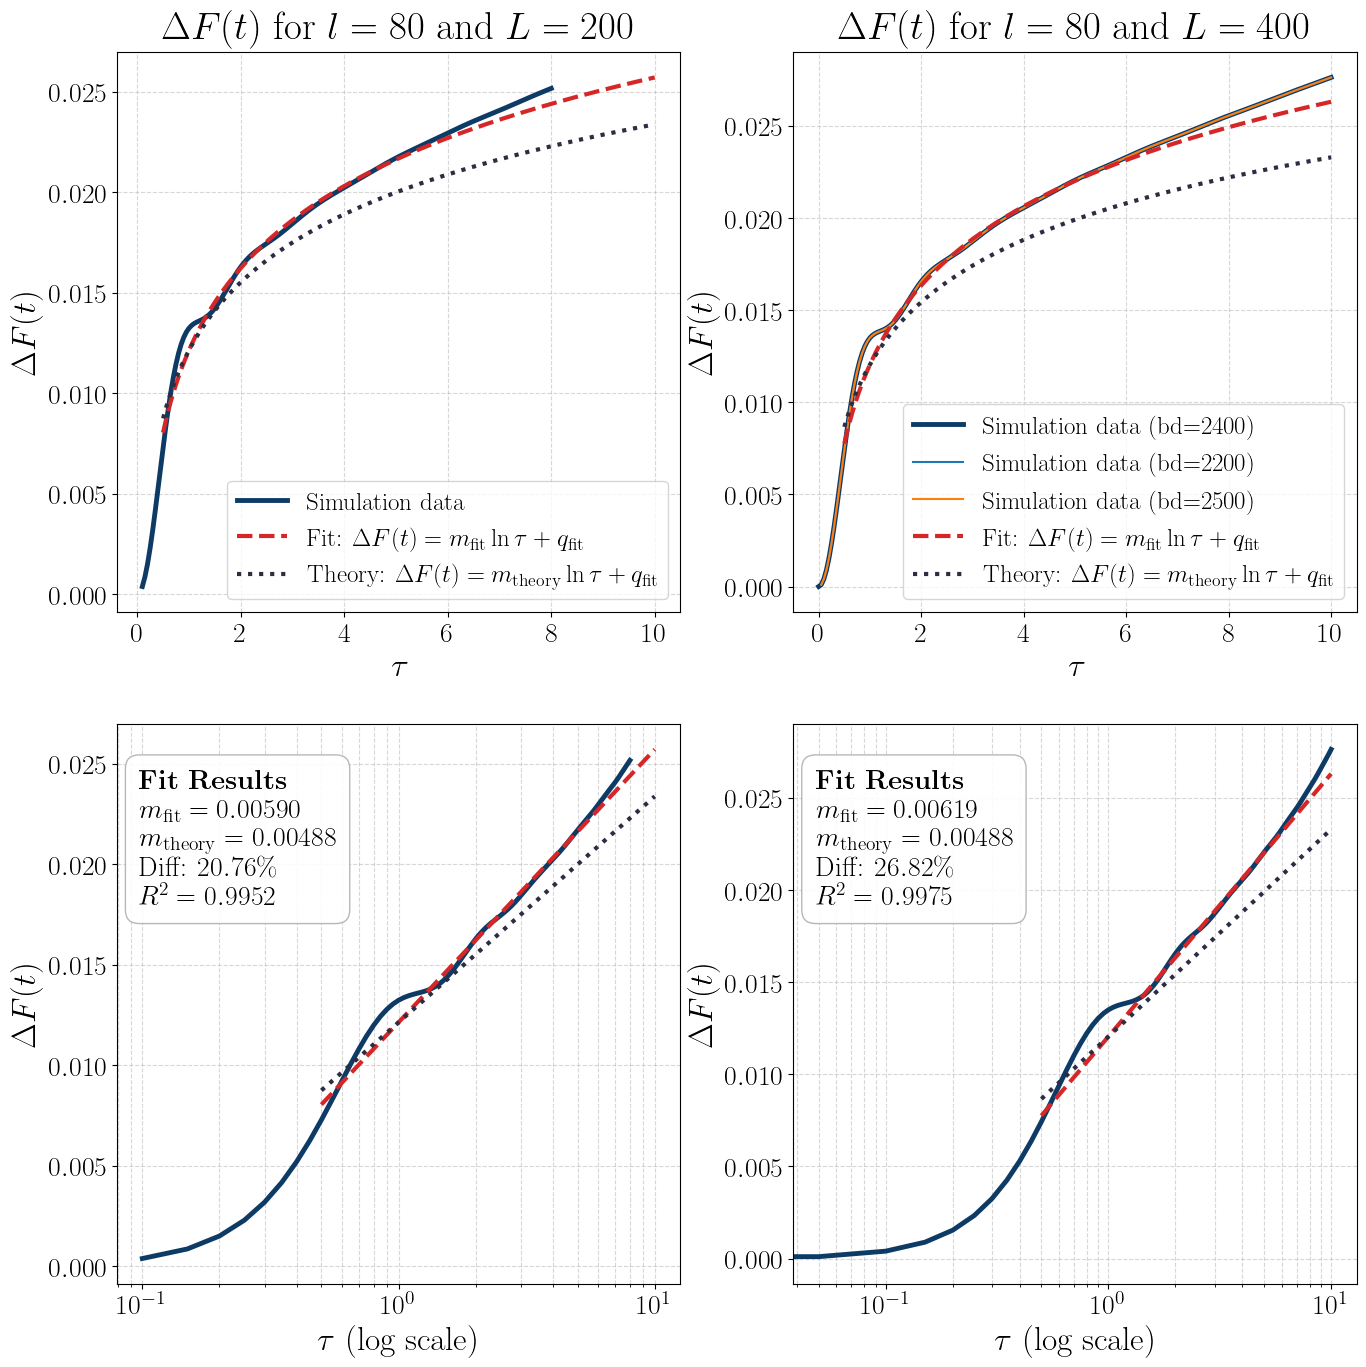

In [127]:
plot_variations_fluctuations_l80_for_fit()

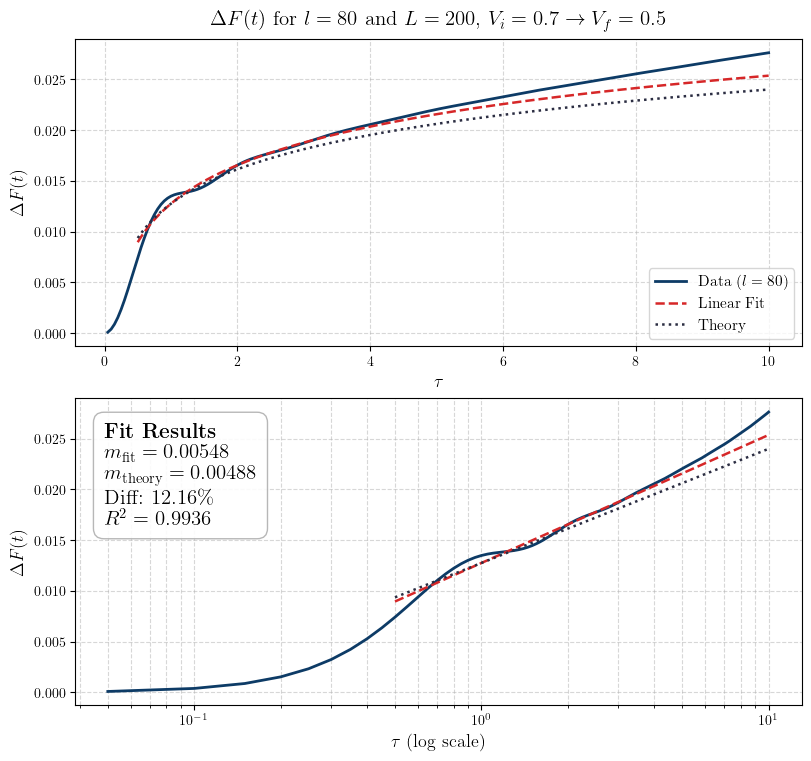

In [391]:
plot_variations_fluctuations_l80_for_fit_larger_system()

In [230]:
def plot_variations_fluctuations_l160_for_fit():
    path = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV01_400sites_time20.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l160.csv"
    df = pd.read_csv(path)

    # subtracting the first value of the fluctuations to make the initial value zero for comparison
    df["Variance"] -= df["Variance"].iloc[0]

    # removing the first row of the dataframe to avoid the initial value at time 0
    df = df.iloc[1:]

    #theoretical data
    mu_i = np.arccos(0.3 / 2.0)
    mu_f = np.arccos(0.2 / 2.0)

    K_i = np.pi / (2 * (np.pi - mu_i))
    K_f = np.pi / (2 * (np.pi - mu_f))

    u_f = np.pi * np.sin(mu_f) / (mu_f)

    B_param = 0.5 * (K_i**2 - K_f**2)/(K_i * K_f)
    m_theory = -B_param * K_f / (np.pi**2)

    t_l = 160/(2*u_f)
    print(t_l)

    def exact_fluctuations(t, m, q):
        # The fraction is inverted to absorb the minus sign, allowing 'm' to stay positive
        log_arg = (2 * u_f * t)**2 / (160**2 - (2 * u_f * t)**2)
        return m * 0.5 * np.log(log_arg) + q



    # fit 
    mask = (df["Time"]> 3.0) & (df["Time"] < 20.0 )
    t_fit = df["Time"][mask]
    var_fit = df["Variance"][mask]

    popt, pcov = curve_fit(exact_fluctuations, t_fit, var_fit, p0=[m_theory, 0.01])
    m_fit_exact, q_fit_exact = popt

    #show results

    error_percentage = abs(m_fit_exact - m_theory) / m_theory * 100
    print(f"Theoretical slope: {m_theory:.5f}")
    print(f"Fitted exact m:    {m_fit_exact:.5f}")
    print(f"Error:             {error_percentage:.2f}%")

    
    t_line = np.linspace(0.5, 20, 400)
    # Generate the curves using the exact finite-size function
    fit_curve = exact_fluctuations(t_line, m_fit_exact, q_fit_exact)
    
    # Generate the theoretical curve (using the fitted 'q' to align the offsets)
    theory_curve = exact_fluctuations(t_line, m_theory, q_fit_exact)

    # plot 
    fig = plt.figure(figsize=(8, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = fig.add_subplot(spec[1, 0])

    l1, = ax1.plot(df["Time"], df["Variance"], color="navy", label=r"Variance $l = 160$", linestyle="--")
    l2, = ax2.semilogx(df["Time"], df["Variance"], color="navy", label=r"Variance $l = 160$", linestyle="--")
    
    # Now you can safely uncomment these!
    l3, = ax1.plot(t_line, fit_curve, color="gray", label=r"fit\_curve")
    l4, = ax2.semilogx(t_line, fit_curve, color="gray", label=r"fit\_curve")
    l5, = ax1.plot(t_line, theory_curve, color="black", label=r"theory\_curve")
    l6, = ax2.semilogx(t_line, theory_curve, color="black", label=r"theory\_curve")

    ax1.set_title(r"Variation of fluctuations for $V_i = 0.3 \to V_f=0.2$", size=18)
    ax1.set_xlabel(r"$\tau$", size=18)
    ax1.set_ylabel(r"$\Delta F(t)$", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l3, l5], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy", "gray", "black"]):
        text.set_color(color)

    ax2.set_xlabel(r"$\log \tau$", size=18)
    ax2.set_ylabel(r"$\Delta F(t)$", size=18)
    ax2.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax2.legend(handles=[l2, l4, l6], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy", "gray", "black"]):
        text.set_color(color)

    plt.show()


37.63792000686965
Theoretical slope: 0.00283
Fitted exact m:    0.00554
Error:             95.75%


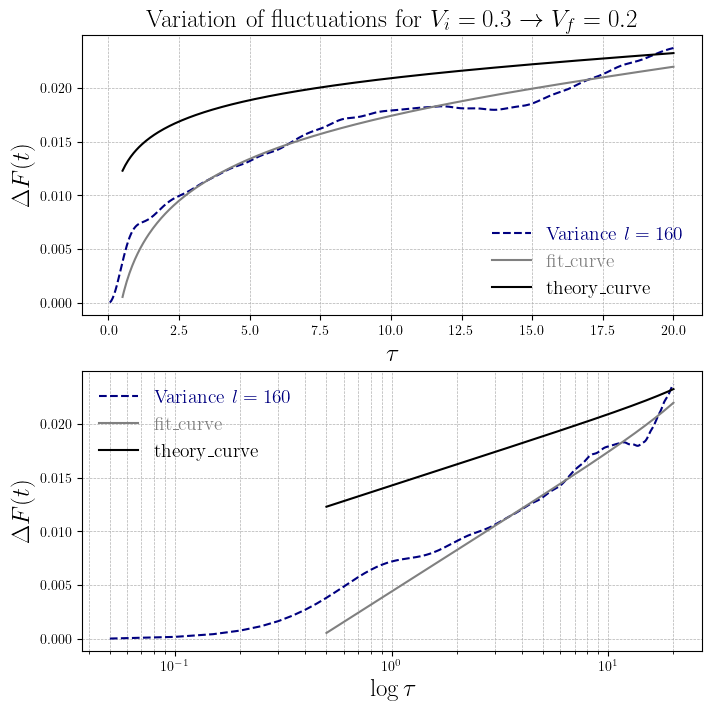

In [231]:
plot_variations_fluctuations_l160_for_fit()

In [464]:
def plot_comparison_LL_to_LL_and_CDW_to_CDW(): 
    path1 = data_quench_dir/"run_LL_quench_from_LL_to_LL_increase_V_DV02_200sites_time15.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l80_comparison.csv"
    path2 = data_quench_dir/"run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time15.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l80_comparison.csv" 
    path3 = data_quench_dir/"run_quench_from_CDW_to_CDW_increase_V_DV02_200sites_time15.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l80.csv"
    path4 = data_quench_dir/"run_quench_from_CDW_to_CDW_decrease_V_DV02_200sites_time15.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l80.csv"

    df1 = pd.read_csv(path1)
    df2 = pd.read_csv(path2)
    df3 = pd.read_csv(path3)
    df4 = pd.read_csv(path4)

    fig = plt.figure(figsize=(18,10))
        
    spec = gridspec.GridSpec(ncols=2, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = fig.add_subplot(spec[0, 1])

    l1, = ax1.plot(df1["Time"], df1["Variance"], color="navy", label=r"$V_i = 0.3 \to V_f = 0.5$", linestyle="--", lw= 5)
    l2, = ax1.plot(df2["Time"], df2["Variance"], color="navy", label=r"$V_i = 0.5 \to V_f = 0.3$", linestyle="-", lw = 5)
    l3, = ax2.plot(df3["Time"], df3["Variance"], color="navy", label=r"$V_i = 4.0 \to V_f = 4.2$", linestyle="--", lw = 5)
    l4, = ax2.plot(df4["Time"], df4["Variance"], color="navy", label=r"$V_i = 4.2 \to V_f = 4.0$", linestyle="-", lw = 5)

    ax1.set_title(r"Quench LL $\to$ LL", size=28)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax1.set_xlabel(r"$\tau$", size=28)
    ax1.set_ylabel(r"$F(t)$", size=28, color = "navy")
    ax1.tick_params(axis="both", labelcolor="black", labelsize= 20)

    leg_LL = ax1.legend(handles=[l1, l2], loc="best", fontsize=27, frameon=True)
    for text, linestyle in zip(leg_LL.get_texts(), ["--", "-"]):
        text.set_label(linestyle)

    ax2.set_title(r"Quench CDW $\to$ CDW", size=28)
    ax2.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax2.set_xlabel(r"$\tau$", size=28)
    ax2.set_ylabel(r"$F(t)$", size=28, color = "navy")
    ax2.tick_params(axis="both", labelcolor="black", labelsize= 20)

    leg_CDW = ax2.legend(handles=[l3, l4], loc="lower right", fontsize=27, frameon=True)
    for text, linestyle in zip(leg_CDW.get_texts(), ["--", "-"]):
        text.set_label(linestyle)
    plt.tight_layout()
    plt.savefig(plot_dir / "plot_fluctuations_l80_L200_comparison_LL_CDW.pdf")

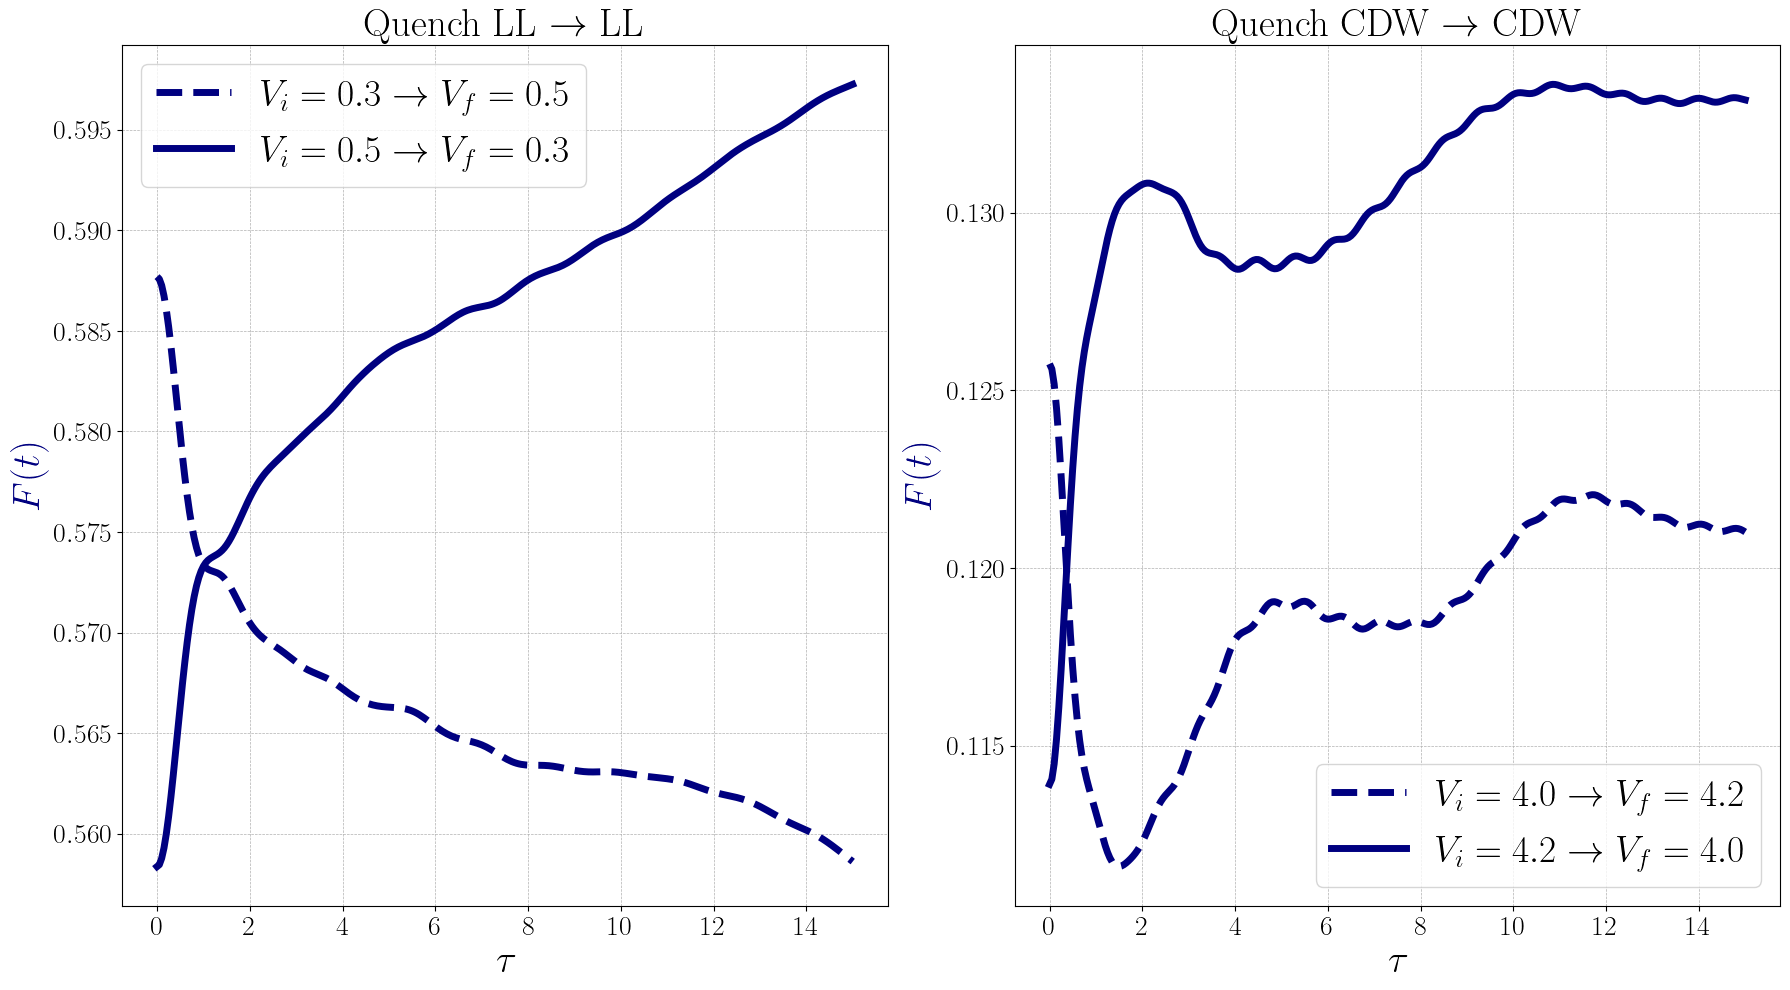

In [490]:
plot_comparison_LL_to_LL_and_CDW_to_CDW()

In [497]:
def plot_comparison_CDW_LL(): 
    path1 = data_quench_dir/"run_quench_from_CDW_to_LL_decrease_V_DV04_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l60.csv"
    path2 = data_quench_dir/"run_quench_from_LL_to_CDW_increase_V_DV04_200sites_time10.0_bonddim2000_cutoff1.0e-8_centered_subsystem_l60.csv"
    df1 = pd.read_csv(path1)
    df2 = pd.read_csv(path2)

    fig = plt.figure(figsize=(8,6))
        
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])

    l1, = ax1.plot(df1["Time"], df1["Variance"], color="navy", label=r"$V_i = 2.2 \to V_f = 1.8$", linestyle="-", lw= 5)
    l2, = ax1.plot(df2["Time"], df2["Variance"], color="navy", label=r"$V_i = 1.8 \to V_f = 2.2$", linestyle="--", lw= 5)
    
    ax1.set_title(r"Quench CDW $\leftrightarrow$ LL", size=28)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax1.set_xlabel(r"$\tau$", size=28)
    ax1.set_ylabel(r"$F(t)$", size=28, color = "navy")
    ax1.tick_params(axis="both", labelcolor="black", labelsize= 20)

    leg_CDW = ax1.legend(handles=[l1, l2], loc="best", fontsize=27, frameon=True)
    for text, linestyle in zip(leg_CDW.get_texts(), ["-", "--"]):
        text.set_label(linestyle)

    plt.tight_layout()
    plt.savefig(plot_dir / "plot_fluctuations_CDW_LL_back_forth.pdf")

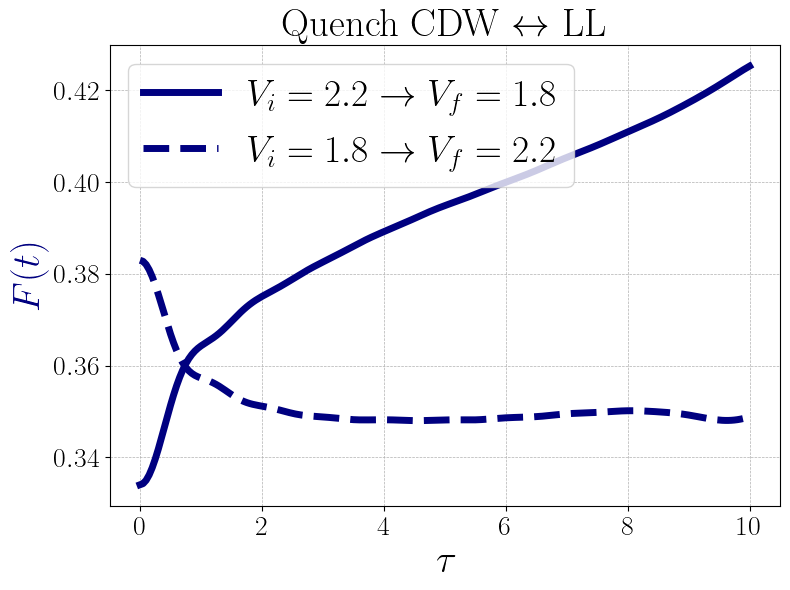

In [498]:
plot_comparison_CDW_LL()

In [558]:
def fit_and_plot_formula_fluctuations_article():
    
    path = (data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_200sites_time10.0_bonddim2400_cutoff1.0e-10_centered_subsystem_l80.csv")

    df = pd.read_csv(path)

    def conf_mapping(x, L):
        return (L / np.pi) * np.sin(np.pi * x / L)
    
    def model(t, p1, p2, p3):
        l_subsystem = 80
        L_system = 200
        d_l = conf_mapping(l_subsystem, L_system)
        d_2uft = conf_mapping(p2 * t, L_system)
        return p1 * np.log((d_l**2 - d_2uft**2) / d_2uft**2) + p3
    
    times = df["Time"].values
    F_vals = df["Variance"].values

    delta_F = F_vals - F_vals[0]

    mu_i = np.arccos(0.7 / 2.0)
    mu_f = np.arccos(0.5 / 2.0)

    K_i = np.pi / (2 * (np.pi - mu_i))
    K_f = np.pi / (2 * (np.pi - mu_f))

    u_f = np.pi * np.sin(mu_f) / mu_f

    B_theory = 0.5 * (K_i**2 - K_f**2) / (K_i * K_f)

    mask = times > 0.8
    t_fit = times[mask]
    delta_F_fit = delta_F[mask]

    p0 = [0.05, 2.0, delta_F_fit[0]]
    fit_bounds = ([-np.inf, 0.0, -np.inf], [np.inf, 10.0, np.inf])
    popt, pcov = curve_fit(model, t_fit, delta_F_fit, p0=p0, bounds= fit_bounds)
    P1_fit, P2_fit, P3_fit = popt

    P1_theory = (B_theory * K_f) / (2 * np.pi**2)
    P2_theory = 2 * u_f
    P3_theory = P3_fit

    error_percentage = abs((P1_fit - P1_theory)/ P1_theory) * 100

    print("-" * 40)
    print(f"FITTED PARAMETERS:")
    print(f"Amplitude (B*K_f / 2pi^2): {P1_fit:.6f}")
    print(f"Velocity (2u_f)          : {P2_fit:.6f}  => u_f = {P2_fit/2:.6f}")
    print(f"THEORY PARAMETERS:")
    print(f"Amplitude (B*K_f / 2\u03c0\u00b2): {P1_theory:.6f}")
    print(f"Velocity (2u_f)          : {P2_theory:.6f}  => u_f = {u_f:.6f}")

    print(f"error percentage of the coefficient of the logarithm: {error_percentage:.2f}%")
    print("-" * 40)
    

    fig = plt.figure(figsize=(8,6))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])

    # Plot 1: raw data
    l1, = ax1.plot(times, delta_F, label= "Simulation data", color='black', linewidth=2)

    # Plot 2: Fitted curve
    l2, = ax1.plot(t_fit, model(t_fit, *popt), label= "Fit curve", color='red', linestyle='--', linewidth=2)

    # Plot 2: Theoretical curve with conformal mapping
    theory_curve = model(t_fit, P1_theory, P2_theory, P3_theory)
    l3, = ax1.plot(t_fit, theory_curve, label="Theory curve", color='blue', linestyle=':', linewidth=2)

    ax1.set_title(r"Fitting equation 4.7.47")
    ax1.set_xlabel(r"Time $(\tau)$")
    ax1.set_ylabel(r"$\Delta F(t)$")
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax1.tick_params(axis="both", labelcolor="black", labelsize= 20)
    leg_CDW = ax1.legend(handles=[l1, l2, l3], loc="best", fontsize=18, frameon=True)
    for text, color in zip(leg_CDW.get_texts(), ["black", "red", "blue"]):
        text.set_color(color)

----------------------------------------
FITTED PARAMETERS:
Amplitude (B*K_f / 2pi^2): -0.002912
Velocity (2u_f)          : 5.973435  => u_f = 2.986717
THEORY PARAMETERS:
Amplitude (B*K_f / 2π²): -0.002442
Velocity (2u_f)          : 4.615427  => u_f = 2.307713
error percentage of the coefficient of the logarithm: 19.26%
----------------------------------------


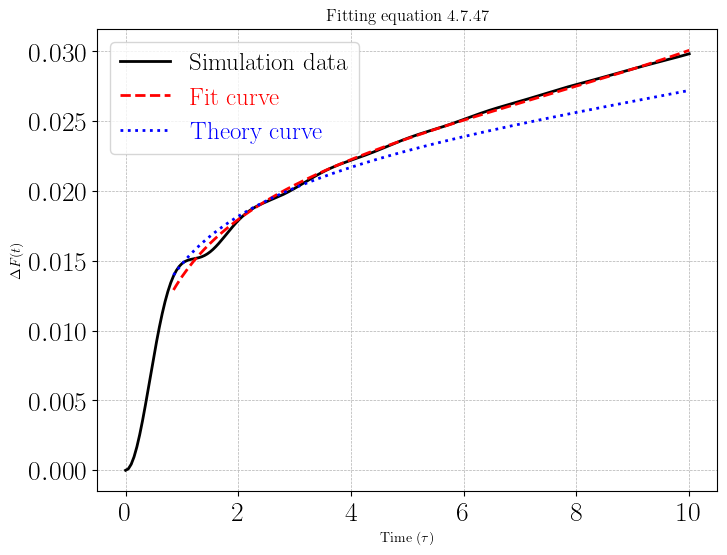

In [559]:
fit_and_plot_formula_fluctuations_article()

In [560]:
def fit_and_plot_formula_fluctuations_article_larger_system():
    
    path = (data_quench_dir / "run_LL_quench_from_LL_to_LL_decrease_V_DV02_400sites_time10.0_bonddim2400_cutoff1.0e-10_centered_subsystem_l80.csv")

    df = pd.read_csv(path)

    def conf_mapping(x, L):
        return (L / np.pi) * np.sin(np.pi * x / L)
    
    def model(t, p1, p2, p3):
        l_subsystem = 80
        L_system = 400
        d_l = conf_mapping(l_subsystem, L_system)
        d_2uft = conf_mapping(p2 * t, L_system)
        return p1 * np.log((d_l**2 - d_2uft**2) / d_2uft**2) + p3
    
    times = df["Time"].values
    F_vals = df["Variance"].values

    delta_F = F_vals - F_vals[0]

    mu_i = np.arccos(0.7 / 2.0)
    mu_f = np.arccos(0.5 / 2.0)

    K_i = np.pi / (2 * (np.pi - mu_i))
    K_f = np.pi / (2 * (np.pi - mu_f))

    u_f = np.pi * np.sin(mu_f) / mu_f

    B_theory = 0.5 * (K_i**2 - K_f**2) / (K_i * K_f)

    mask = times > 0.8
    t_fit = times[mask]
    delta_F_fit = delta_F[mask]

    p0 = [0.05, 2.0, delta_F_fit[0]]
    fit_bounds = ([-np.inf, 0.0, -np.inf], [np.inf, 10.0, np.inf])
    popt, pcov = curve_fit(model, t_fit, delta_F_fit, p0=p0, bounds= fit_bounds)
    P1_fit, P2_fit, P3_fit = popt

    P1_theory = (B_theory * K_f) / (2 * np.pi**2)
    P2_theory = 2 * u_f
    P3_theory = P3_fit

    error_percentage = abs((P1_fit - P1_theory)/ P1_theory) * 100

    print("-" * 40)
    print(f"FITTED PARAMETERS:")
    print(f"Amplitude (B*K_f / 2pi^2): {P1_fit:.6f}")
    print(f"Velocity (2u_f)          : {P2_fit:.6f}  => u_f = {P2_fit/2:.6f}")
    print(f"THEORY PARAMETERS:")
    print(f"Amplitude (B*K_f / 2\u03c0\u00b2): {P1_theory:.6f}")
    print(f"Velocity (2u_f)          : {P2_theory:.6f}  => u_f = {u_f:.6f}")

    print(f"error percentage of the coefficient of the logarithm: {error_percentage:.2f}%")
    print("-" * 40)
    

    fig = plt.figure(figsize=(8,6))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])

    # Plot 1: raw data
    l1, = ax1.plot(times, delta_F, label= "Simulation data", color='black', linewidth=2)

    # Plot 2: Fitted curve
    l2, = ax1.plot(t_fit, model(t_fit, *popt), label= "Fit curve", color='red', linestyle='--', linewidth=2)

    # Plot 2: Theoretical curve with conformal mapping
    theory_curve = model(t_fit, P1_theory, P2_theory, P3_theory)
    l3, = ax1.plot(t_fit, theory_curve, label="Theory curve", color='blue', linestyle=':', linewidth=2)

    ax1.set_title(r"Fitting equation 4.7.47")
    ax1.set_xlabel(r"Time $(\tau)$")
    ax1.set_ylabel(r"$\Delta F(t)$")
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax1.tick_params(axis="both", labelcolor="black", labelsize= 20)
    leg_CDW = ax1.legend(handles=[l1, l2, l3], loc="best", fontsize=18, frameon=True)
    for text, color in zip(leg_CDW.get_texts(), ["black", "red", "blue"]):
        text.set_color(color)

----------------------------------------
FITTED PARAMETERS:
Amplitude (B*K_f / 2pi^2): -0.002756
Velocity (2u_f)          : 6.113557  => u_f = 3.056779
THEORY PARAMETERS:
Amplitude (B*K_f / 2π²): -0.002442
Velocity (2u_f)          : 4.615427  => u_f = 2.307713
error percentage of the coefficient of the logarithm: 12.87%
----------------------------------------


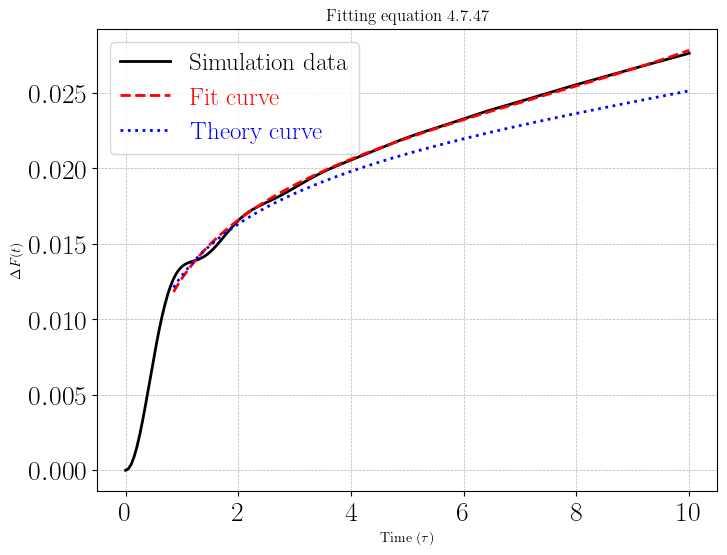

In [561]:
fit_and_plot_formula_fluctuations_article_larger_system()

In [566]:
def plot_check_convergence_l80_L400():
    # Load data 
    path1 = checkpoint_dir/"quench_from_LL_to_LL_bd300_decrease_V_DV02_10.0_centered_subsystem_l80.h5"
    path2 = checkpoint_dir/"quench_from_LL_to_LL_bd400_decrease_V_DV02_10.0_centered_subsystem_l80.h5"

    # Extract data
    with h5py.File(path1, "r") as f: 
        print(list(f.keys()))

        step1 = f["step"][()]
        t_final1 = f["t"][()]
        S_EE_vals1 = f["S_EE_vals"][:]
        F_vals1 = f["F_vals"][:]
        total_fidelity1 = f["total_fidelity"][()]
    
    dt = 0.05
    times1 = np.arange(len(F_vals1)) * dt

    print(f"checkpoint step: {step1}, final time: {t_final1}, total fidelity: {total_fidelity1:.6f}")
    print(f"*" * 40)

    with h5py.File(path2, "r") as f: 
        print(list(f.keys()))

        step2 = f["step"][()]
        t_final2 = f["t"][()]
        S_EE_vals2 = f["S_EE_vals"][:]
        F_vals2 = f["F_vals"][:]
        total_fidelity2 = f["total_fidelity"][()]

    dt = 0.05
    times2 = np.arange(len(F_vals2)) * dt

    print(f"checkpoint step: {step2}, final time: {t_final2}, total fidelity: {total_fidelity2:.6f}")
    print(f"*" * 40)

    fig = plt.figure(figsize=(8, 6))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])

    l1, = ax1.plot(times1, F_vals1, label=r"bd $=300$", color = "black")
    l2, = ax1.plot(times1, F_vals2, label=r"bd $=400$", color = "gray")

    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=18, frameon=True)
    for text, color in zip(leg.get_texts(), ["black", "gray"]):
        text.set_color(color)

    plt.show()
    
    


    # Plotting
    

['F_vals', 'S_EE_vals', 'psi', 'step', 't', 'total_fidelity']
checkpoint step: 80, final time: 3.95, total fidelity: 0.999995
****************************************
['F_vals', 'S_EE_vals', 'psi', 'step', 't', 'total_fidelity']
checkpoint step: 80, final time: 3.95, total fidelity: 0.999995
****************************************


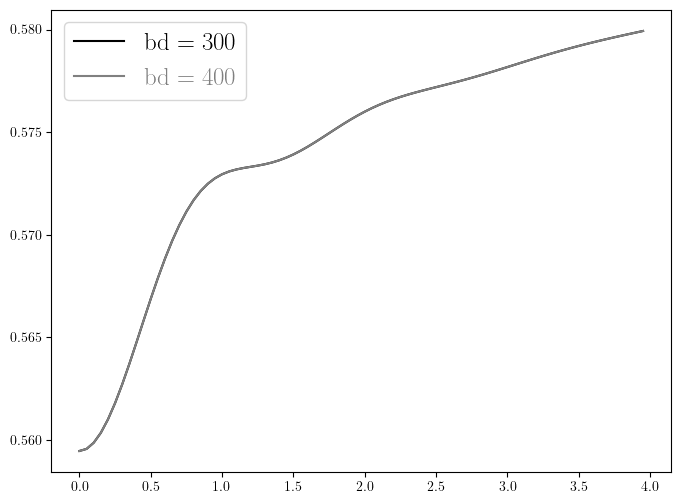

In [567]:
plot_check_convergence_l80_L400()

In [591]:
def plot_u_V_K():
    #1. V  domain
    V_int = np.linspace(-1.999, 2, 1000)

    # 2. Compute mu (Equation 4.7.49)
    mu = np.arccos(V_int / 2)

    # 3. Compute K (Equation 4.7.50)
    K_b = np.pi / (2 * (np.pi - mu))

    # 4. Compute u (Equation 4.7.51)
    u = np.zeros_like(mu)
    # Create a mask for the safe division
    mask = (mu != 0)
    u[mask] = np.pi * np.sin(mu[mask]) / mu[mask]
    u[~mask] = np.pi 

    uK = u * K_b
    u_div_K = u / K_b

    plt.figure(figsize=(8, 6))

    plt.plot(V_int, uK, label=r'$uK$', color='blue', linewidth=2)
    plt.plot(V_int, u_div_K, label=r'$u/K$', color='red', linewidth=2)

    plt.title(r'Dependence of $uK$ and $u/K$ on $V$', fontsize=22)
    plt.xlabel(r'$V$', fontsize=20)
    plt.ylabel(r'Value', fontsize=20)

    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.xlim(-2, 2)
    plt.xticks(size="18")
    plt.ylim(0, 8) 
    plt.yticks(size="18")


    plt.legend(fontsize=20, loc='upper left')
    plt.tight_layout()

    # Save the figure to insert into your document
    plt.savefig(plot_dir/'uK_and_u_over_K_plot.pdf', dpi=300)
    plt.show()

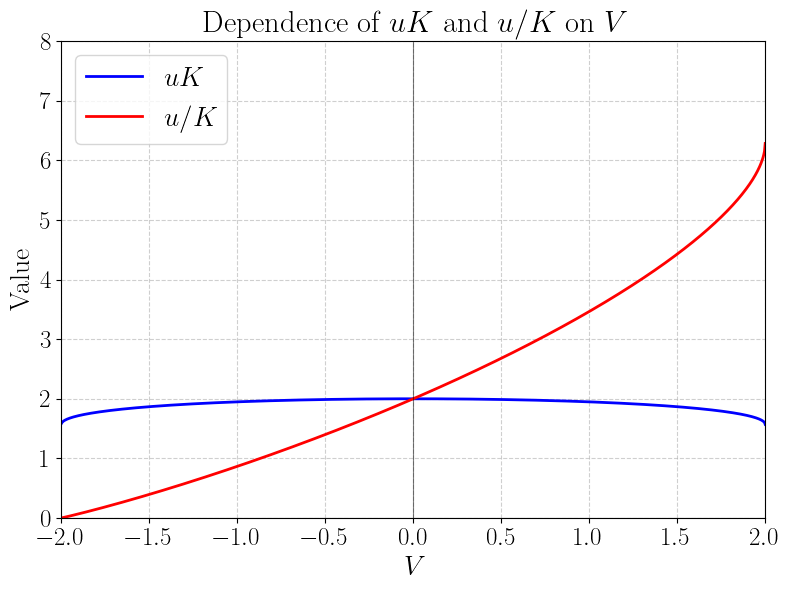

In [592]:
plot_u_V_K()

In [ ]:
def plot_quench_NNN_LL_to_LL_decrease_V_10sec():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_NNN_coupling_increase_V_DV02_sites300_time8.0_bonddim2000_cutoff1.0e-10_centered_subsystem_l60.csv")

    # Extract data
    time = df["Time"].values
    variance = df["Variance"].values
    delta_variance = variance - variance[0]
    # remove first value to avoid log divergenceee
    delta_variance = delta_variance[1:]
    time = time[1:]

    # theory data
    K_i = 0.8219
    K_f = 0.8674

    B_param = 0.5 * (K_i**2 - K_f**2) / (K_i * K_f) 
    m_theory = -B_param * K_f / (np.pi**2)

    # --- Perform Fit ---
    mask = (time > 3.0) & (time < 7.0)
    t_fit = time[mask]
    var_fit = delta_variance[mask]
    x_data = np.log(t_fit)
    y_data = var_fit
    m_fit, q_fit, r_value, p_value, std_err = linregress(x_data, y_data)
    error_percentage = abs(m_fit - m_theory) / m_theory *100

    print(f"Error percentage: {error_percentage:.2f}%")
    t_line = np.linspace(0.5, 8, 200)
    fit_curve = m_fit * np.log(t_line) + q_fit
    theory_curve = m_theory * np.log(t_line) + q_fit


    # Plotting
    fig = plt.figure(figsize=(8, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = fig.add_subplot(spec[1, 0])


    l1, = ax1.plot(time, delta_variance, color="navy", label=r"Variance", linestyle="--")
    l2, = ax2.semilogx(time, delta_variance, color="navy", label=r"Variance", linestyle="--")
    l3, = ax2.semilogx(t_line, fit_curve, color="gray", label=r"fit", linestyle=":")
    l4, = ax2.semilogx(t_line, theory_curve, color="black", label=r"theory", linestyle="-")

    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from NNN LL to LL $V_i = 0.7 \to V_f = 0.5$, sites $N = 300$", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy"]):
        text.set_color(color)
    ax2.set_xlabel(r"Time $\tau$ (log scale)", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax2.tick_params(axis="y", labelcolor="navy")
    ax2.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax2.legend(handles=[l2, l3, l4], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["navy", "gray", "black"]):
        text.set_color(color)

    plt.tight_layout()
    plt.savefig(plot_dir / "quench_from_NNN_LL_to_LL_decrease_V.pdf")
    plt.show()

Error percentage: -310.57%


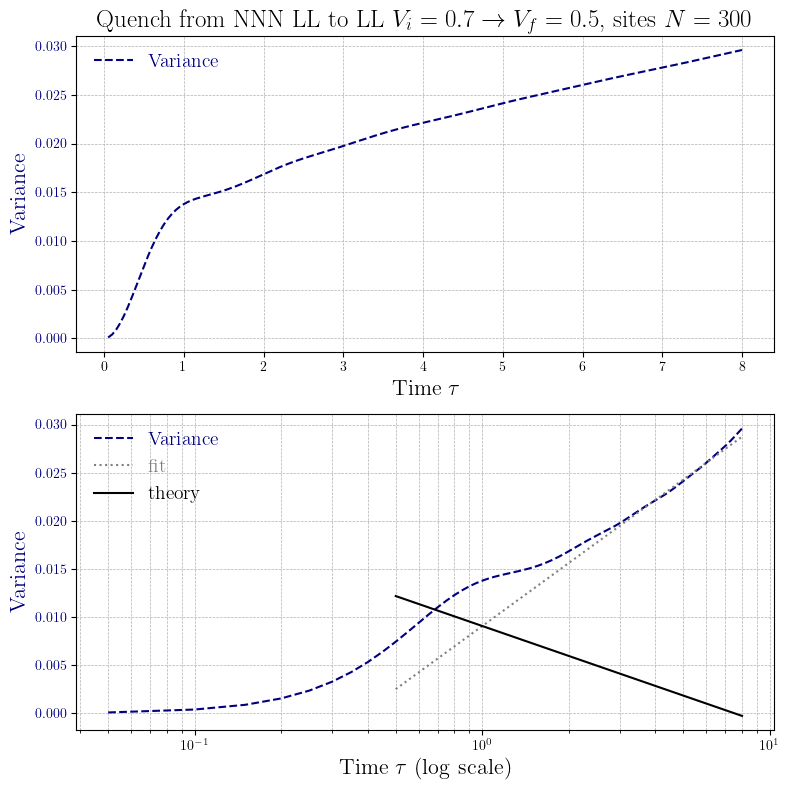

In [6]:
plot_quench_NNN_LL_to_LL_decrease_V_10sec()

In [7]:
def extract_LL_parameter_from_NNN_simulation_V07():
    df = pd.read_csv(project_root / "data/fluctuations/quench_paper/bipartite_fluctuations_pre_quench_N300_l4-150_V07.csv")
    N_sites = 300

    l_raw = df['length_sub'].values
    F_raw = df['Variance'].values

    # --- 3. Apply 4-Site Moving Average ---
    # This eliminates the period-2 and period-4 lattice Friedel oscillations
    window = 4
    F_smooth = np.convolve(F_raw, np.ones(window)/window, mode='valid')
    # Shift the l_values to the center of the moving window
    l_smooth = l_raw[0:len(F_smooth)] + (window - 1) / 2.0

    # --- 4. Conformal Distance Mapping ---
    # d(l) = (N/pi) * sin(pi * l / N)
    d_l = (N_sites / np.pi) * np.sin(np.pi * l_smooth / N_sites)
    ln_d_l = np.log(d_l)

    # --- 5. Linear Fit ---
    # We fit only for l > 30 to avoid short-distance lattice effects and capture the true bulk limit
    fit_mask = l_smooth >= 30
    ln_d_l_fit = ln_d_l[fit_mask]
    F_fit = F_smooth[fit_mask]

    slope, intercept, r_value, p_value, std_err = linregress(ln_d_l_fit, F_fit)

    # Calculate K. 
    # Because this is a centered subsystem (2 entanglement cuts), the prefactor is K/pi^2
    K_extracted = slope * (np.pi ** 2)

    print("="*50)
    print(f"Linear Fit Results (l >= 30):")
    print(f"Slope (m) = {slope:.6f}")
    print(f"R-squared = {r_value**2:.6f}")
    print(f"Extracted Luttinger Parameter K = {K_extracted:.4f}")
    print("="*50)

    # --- 6. Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

    # Plot 1: F vs l (Linear scale, showing raw vs smoothed)
    ax1.plot(l_raw, F_raw, color='lightgray', marker='o', markersize=3, linestyle='-', label="Raw Data (Period-4 Oscillations)")
    ax1.plot(l_smooth, F_smooth, color='red', linewidth=2, label="4-Site Moving Average")
    ax1.set_xlabel(r"Subsystem Length $l$", fontsize=20)
    ax1.set_ylabel(r"Charge Variance $\mathcal{F}(l)$", fontsize=20)
    ax1.set_title("Bipartite Charge Fluctuations", fontsize=20)
    ax1.legend(fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Plot 2: F vs ln(d(l)) (Log scale mapping, showing the linear fit)
    ax2.plot(ln_d_l, F_smooth, color='red', marker='o', markersize=4, linestyle='', label="Smoothed Data")
    # Plot the fit line
    x_fit_line = np.linspace(min(ln_d_l_fit), max(ln_d_l_fit), 100)
    y_fit_line = slope * x_fit_line + intercept
    ax2.plot(x_fit_line, y_fit_line, color='black', linestyle='--', linewidth=2, 
            label=f"Linear Fit\n$m = {slope:.4f}$\n$K = {K_extracted:.4f}$")

    ax2.set_xlabel(r"Conformal Distance $\ln \left[ \frac{N}{\pi} \sin\left(\frac{\pi l}{N}\right) \right]$", fontsize=20)
    ax2.set_ylabel(r"Smoothed Variance $\mathcal{F}$", fontsize=20)
    ax2.set_title(r"Extracting Luttinger Parameter $K$", fontsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.legend(fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)


    plt.tight_layout()
    plt.show()

    plt.savefig(plot_dir / "extract_LL_parameter_from_NNN_simulation_V07.pdf", dpi=300)

Linear Fit Results (l >= 30):
Slope (m) = 0.083279
R-squared = 0.999991
Extracted Luttinger Parameter K = 0.8219


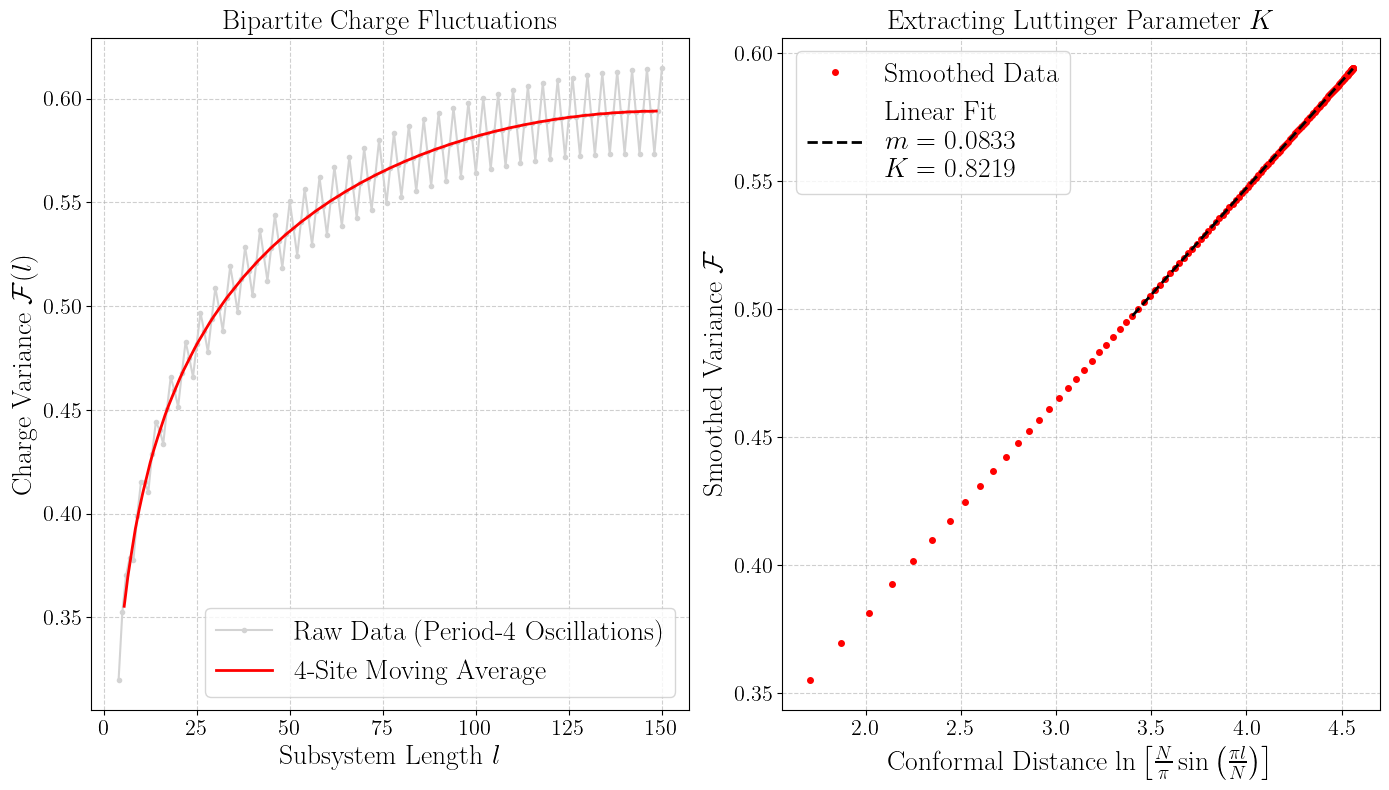

<Figure size 640x480 with 0 Axes>

In [8]:
extract_LL_parameter_from_NNN_simulation_V07()

In [9]:
def extract_LL_parameter_from_NNN_simulation_V05():
    df = pd.read_csv(project_root / "data/fluctuations/quench_paper/bipartite_fluctuations_post_quench_N300_l4-150_V05.csv")
    N_sites = 300

    l_raw = df['length_sub'].values
    F_raw = df['Variance'].values

    # --- 3. Apply 4-Site Moving Average ---
    # This eliminates the period-2 and period-4 lattice Friedel oscillations
    window = 4
    F_smooth = np.convolve(F_raw, np.ones(window)/window, mode='valid')
    # Shift the l_values to the center of the moving window
    l_smooth = l_raw[0:len(F_smooth)] + (window - 1) / 2.0

    # --- 4. Conformal Distance Mapping ---
    # d(l) = (N/pi) * sin(pi * l / N)
    d_l = (N_sites / np.pi) * np.sin(np.pi * l_smooth / N_sites)
    ln_d_l = np.log(d_l)

    # --- 5. Linear Fit ---
    # We fit only for l > 30 to avoid short-distance lattice effects and capture the true bulk limit
    fit_mask = l_smooth >= 30
    ln_d_l_fit = ln_d_l[fit_mask]
    F_fit = F_smooth[fit_mask]

    slope, intercept, r_value, p_value, std_err = linregress(ln_d_l_fit, F_fit)

    # Calculate K. 
    # Because this is a centered subsystem (2 entanglement cuts), the prefactor is K/pi^2
    K_extracted = slope * (np.pi ** 2)

    print("="*50)
    print(f"Linear Fit Results (l >= 30):")
    print(f"Slope (m) = {slope:.6f}")
    print(f"R-squared = {r_value**2:.6f}")
    print(f"Extracted Luttinger Parameter K = {K_extracted:.4f}")
    print("="*50)

    # --- 6. Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

    # Plot 1: F vs l (Linear scale, showing raw vs smoothed)
    ax1.plot(l_raw, F_raw, color='lightgray', marker='o', markersize=3, linestyle='-', label="Raw Data (Period-4 Oscillations)")
    ax1.plot(l_smooth, F_smooth, color='red', linewidth=2, label="4-Site Moving Average")
    ax1.set_xlabel(r"Subsystem Length $l$", fontsize=20)
    ax1.set_ylabel(r"Charge Variance $\mathcal{F}(l)$", fontsize=20)
    ax1.set_title("Bipartite Charge Fluctuations", fontsize=20)
    ax1.legend(fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Plot 2: F vs ln(d(l)) (Log scale mapping, showing the linear fit)
    ax2.plot(ln_d_l, F_smooth, color='red', marker='o', markersize=4, linestyle='', label="Smoothed Data")
    # Plot the fit line
    x_fit_line = np.linspace(min(ln_d_l_fit), max(ln_d_l_fit), 100)
    y_fit_line = slope * x_fit_line + intercept
    ax2.plot(x_fit_line, y_fit_line, color='black', linestyle='--', linewidth=2, 
            label=f"Linear Fit\n$m = {slope:.4f}$\n$K = {K_extracted:.4f}$")

    ax2.set_xlabel(r"Conformal Distance $\ln \left[ \frac{N}{\pi} \sin\left(\frac{\pi l}{N}\right) \right]$", fontsize=20)
    ax2.set_ylabel(r"Smoothed Variance $\mathcal{F}$", fontsize=20)
    ax2.set_title(r"Extracting Luttinger Parameter $K$", fontsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.legend(fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)


    plt.tight_layout()
    plt.show()

    plt.savefig(plot_dir / "extract_LL_parameter_from_NNN_simulation_V05.pdf", dpi=300)

Linear Fit Results (l >= 30):
Slope (m) = 0.087890
R-squared = 0.999993
Extracted Luttinger Parameter K = 0.8674


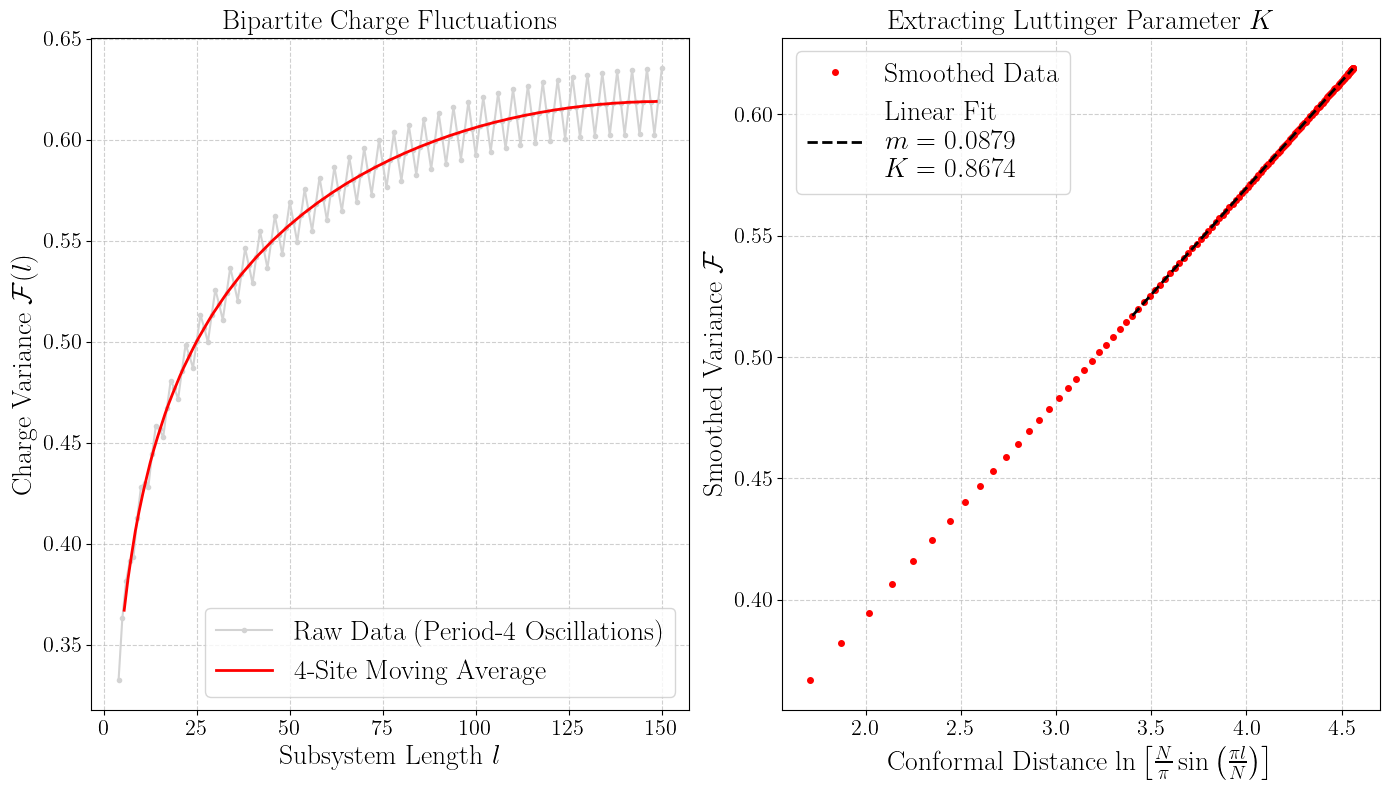

<Figure size 640x480 with 0 Axes>

In [10]:
extract_LL_parameter_from_NNN_simulation_V05()

In [128]:
def extract_LL_parameter_from_NNN_simulation_V05_OBC():
    df = pd.read_csv(project_root / "data/fluctuations/quench_paper/bipartite_fluctuations_post_quench_N400_l4-200_V05.csv")
    N_sites = 400

    l_raw = df['length_sub'].values
    F_raw = df['Variance'].values

    # --- 3. Apply 4-Site Moving Average ---
    # This eliminates the period-2 and period-4 lattice Friedel oscillations
    window = 4
    F_smooth = np.convolve(F_raw, np.ones(window)/window, mode='valid')
    # Shift the l_values to the center of the moving window
    l_smooth = l_raw[0:len(F_smooth)] + (window - 1) / 2.0

    # --- 4. Conformal Distance Mapping ---
    # d(l) = (2N/pi) * sin(pi * l / N)
    d_l = ( 2*N_sites / np.pi) * np.sin(np.pi * l_smooth / (N_sites))
    ln_d_l = np.log(d_l)

    # --- 5. Linear Fit ---
    # We fit only for l > 30 and l < 180 to avoid short-distance lattice effects and capture the true bulk limit
    fit_mask = (l_smooth >= 10) & (l_smooth < 180)
    ln_d_l_fit = ln_d_l[fit_mask]
    F_fit = F_smooth[fit_mask]

    slope, intercept, r_value, p_value, std_err = linregress(ln_d_l_fit, F_fit)

    # Calculate K. 
    # Because this is a centered subsystem (2 entanglement cuts), the prefactor is K/pi^2
    K_extracted = slope * (2 * np.pi ** 2)

    print("="*50)
    print(f"Linear Fit Results (l >= 30):")
    print(f"Slope (m) = {slope:.6f}")
    print(f"R-squared = {r_value**2:.6f}")
    print(f"Extracted Luttinger Parameter K = {K_extracted:.6f}")
    print("="*50)

    # --- 6. Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

    # Plot 1: F vs l (Linear scale, showing raw vs smoothed)
    ax1.plot(l_raw, F_raw, color='lightgray', marker='o', markersize=3, linestyle='-', label="Raw Data (Period-4 Oscillations)")
    ax1.plot(l_smooth, F_smooth, color='red', linewidth=2, label="4-Site Moving Average")
    ax1.set_xlabel(r"Subsystem Length $l$", fontsize=20)
    ax1.set_ylabel(r"Charge Variance $\mathcal{F}(l)$", fontsize=20)
    ax1.set_title("Bipartite Charge Fluctuations", fontsize=20)
    ax1.legend(fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Plot 2: F vs ln(d(l)) (Log scale mapping, showing the linear fit)
    ax2.plot(ln_d_l, F_smooth, color='red', marker='o', markersize=4, linestyle='', label="Smoothed Data")
    # Plot the fit line
    x_fit_line = np.linspace(min(ln_d_l_fit), max(ln_d_l_fit), 100)
    y_fit_line = slope * x_fit_line + intercept
    ax2.plot(x_fit_line, y_fit_line, color='black', linestyle='--', linewidth=2, 
            label=f"Linear Fit\n$m = {slope:.4f}$\n$K = {K_extracted:.4f}$")

    ax2.set_xlabel(r"Conformal Distance $\ln \left[ \frac{2N}{\pi} \sin\left(\frac{\pi l}{N}\right) \right]$", fontsize=20)
    ax2.set_ylabel(r"Smoothed Variance $\mathcal{F}$", fontsize=20)
    ax2.set_title(r"Extracting Luttinger Parameter $K$", fontsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.legend(fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)


    plt.tight_layout()

    plt.savefig(plot_dir / "extract_LL_parameter_from_NNN_simulation_V05_N400.pdf", dpi=300)
    plt.show()



Linear Fit Results (l >= 30):
Slope (m) = 0.042519
R-squared = 0.999951
Extracted Luttinger Parameter K = 0.839299


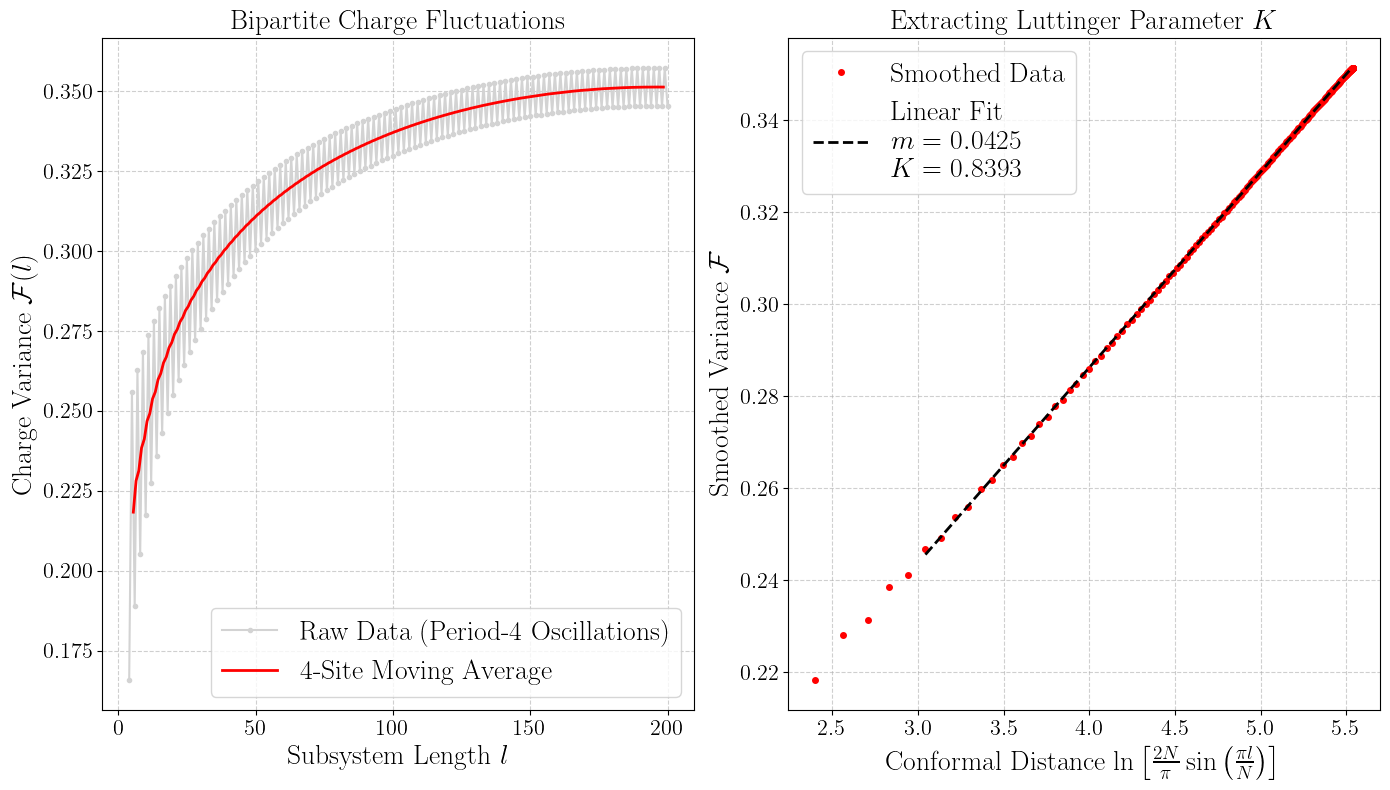

In [129]:
extract_LL_parameter_from_NNN_simulation_V05_OBC()

In [97]:
def extract_LL_parameter_from_NNN_simulation_V07_OBC():
    df = pd.read_csv(project_root / "data/fluctuations/quench_paper/bipartite_fluctuations_post_quench_N400_l4-200_V07.csv")
    N_sites = 400

    l_raw = df['length_sub'].values
    F_raw = df['Variance'].values

    # --- 3. Apply 4-Site Moving Average ---
    # This eliminates the period-2 and period-4 lattice Friedel oscillations
    window = 4
    F_smooth = np.convolve(F_raw, np.ones(window)/window, mode='valid')
    # Shift the l_values to the center of the moving window
    l_smooth = l_raw[0:len(F_smooth)] + (window - 1) / 2.0

    # --- 4. Conformal Distance Mapping ---
    # d(l) = (N/pi) * sin(pi * l / N)
    d_l = ( 2*N_sites / np.pi) * np.sin(np.pi * l_smooth / (N_sites))
    ln_d_l = np.log(d_l)

    # --- 5. Linear Fit ---
    # We fit only for l > 30 and l < 180 to avoid short-distance lattice effects and capture the true bulk limit
    fit_mask = (l_smooth >= 10) & (l_smooth < 180)
    ln_d_l_fit = ln_d_l[fit_mask]
    F_fit = F_smooth[fit_mask]

    slope, intercept, r_value, p_value, std_err = linregress(ln_d_l_fit, F_fit)

    # Calculate K. 
    # Because this is a centered subsystem (2 entanglement cuts), the prefactor is K/pi^2
    K_extracted = slope * (2 * np.pi ** 2)

    print("="*50)
    print(f"Linear Fit Results (l >= 30):")
    print(f"Slope (m) = {slope:.6f}")
    print(f"R-squared = {r_value**2:.6f}")
    print(f"Extracted Luttinger Parameter K = {K_extracted:.6f}")
    print("="*50)

    # --- 6. Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

    # Plot 1: F vs l (Linear scale, showing raw vs smoothed)
    ax1.plot(l_raw, F_raw, color='lightgray', marker='o', markersize=3, linestyle='-', label="Raw Data (Period-4 Oscillations)")
    ax1.plot(l_smooth, F_smooth, color='red', linewidth=2, label="4-Site Moving Average")
    ax1.set_xlabel(r"Subsystem Length $l$", fontsize=20)
    ax1.set_ylabel(r"Charge Variance $\mathcal{F}(l)$", fontsize=20)
    ax1.set_title("Bipartite Charge Fluctuations", fontsize=20)
    ax1.legend(fontsize=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Plot 2: F vs ln(d(l)) (Log scale mapping, showing the linear fit)
    ax2.plot(ln_d_l, F_smooth, color='red', marker='o', markersize=4, linestyle='', label="Smoothed Data")
    # Plot the fit line
    x_fit_line = np.linspace(min(ln_d_l_fit), max(ln_d_l_fit), 100)
    y_fit_line = slope * x_fit_line + intercept
    ax2.plot(x_fit_line, y_fit_line, color='black', linestyle='--', linewidth=2, 
            label=f"Linear Fit\n$m = {slope:.4f}$\n$K = {K_extracted:.4f}$")

    ax2.set_xlabel(r"Conformal Distance $\ln \left[ \frac{N}{\pi} \sin\left(\frac{\pi l}{N}\right) \right]$", fontsize=20)
    ax2.set_ylabel(r"Smoothed Variance $\mathcal{F}$", fontsize=20)
    ax2.set_title(r"Extracting Luttinger Parameter $K$", fontsize=20)
    ax2.tick_params(axis='both', which='major', labelsize=16)
    ax2.legend(fontsize=20)
    ax2.grid(True, linestyle='--', alpha=0.6)


    plt.tight_layout()

    plt.savefig(plot_dir / "extract_LL_parameter_from_NNN_simulation_V05_N400.pdf", dpi=300)
    plt.show()



Linear Fit Results (l >= 30):
Slope (m) = 0.040269
R-squared = 0.999942
Extracted Luttinger Parameter K = 0.794878


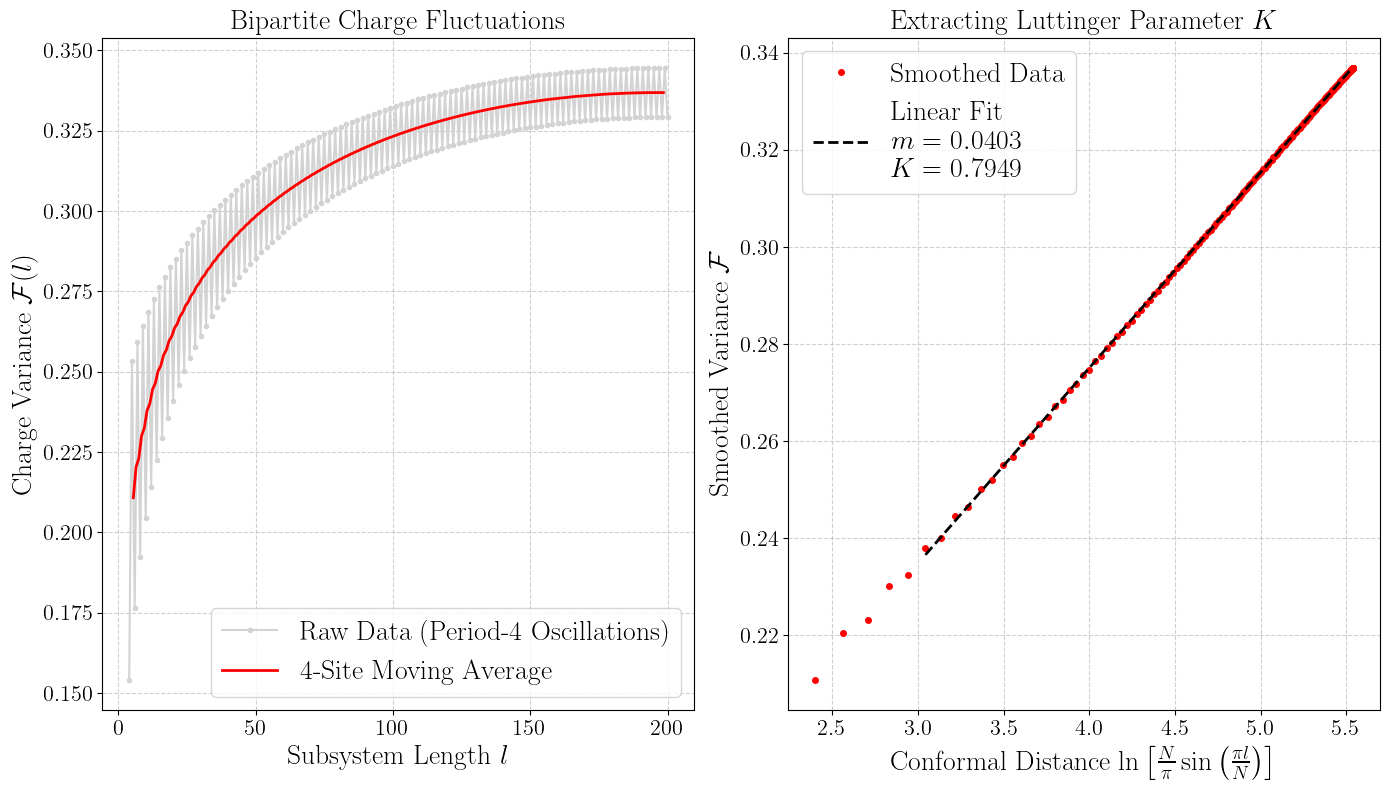

In [98]:
extract_LL_parameter_from_NNN_simulation_V07_OBC()

In [95]:
def plot_quench_NNN_LL_to_LL_decrease_V_8sec_OBC():
    df = pd.read_csv(data_quench_dir / "run_LL_quench_from_LL_to_LL_NNN_coupling_decrease_V_DV02_sites400_time8.0_bonddim2000_cutoff1.0e-10_edge_subsystem_l80.csv")

    time = df["Time"].values
    variance = df["Variance"].values
    delta_variance = variance - variance[0]
    delta_variance = delta_variance[1:]
    time = time[1:]

    # --- linear fit on log scale ---
    mask = (time > 2.0) & (time < 6.0)
    t_fit = time[mask]
    var_fit = delta_variance[mask]
    x_data = np.log(t_fit)
    y_data = var_fit
    m_fit, q_fit, r_value, p_value, std_err = linregress(x_data, y_data)

    t_line = np.linspace(0.5, 8, 200)

    # theory data
    K_f = 0.839299
    K_i = 0.794878
    B_param = 0.5 * (K_i**2 - K_f**2) / (K_i * K_f)
    m_theory = - B_param * K_f / ( 2 * np.pi**2) 

    fig = plt.figure(figsize=(8, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = fig.add_subplot(spec[1, 0])

    l1, = ax1.plot(time, delta_variance, color="navy", label=r"$\Delta F$", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Variance", color="navy", size=16)
    ax1.tick_params(axis="y", labelcolor="navy")
    ax1.set_title(r"Quench from NNN LL to LL $V_i = 0.7 \to V_f = 0.5$, sites $N = 400$", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)

    l2, = ax2.semilogx(time, delta_variance, color="navy", label=r"$\Delta F$", linestyle="--")
    l3, = ax2.semilogx(t_line, m_fit * np.log(t_line) + q_fit, color="gray", label=r"fit", linestyle=":")
    l4, = ax2.semilogx(t_line, m_theory * np.log(t_line) + q_fit, color="black", label=r"theory", linestyle="-")

    ax2.set_xlabel(r"Time $\tau$ (log scale)", size=16)
    ax2.set_ylabel(r"Variance", color="navy", size=16)
    ax2.tick_params(axis="y", labelcolor="navy")
    ax2.grid(True, which="both", linestyle="--", linewidth=0.5)

    leg1 = ax1.legend(handles=[l1], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg1.get_texts(), ["navy"]):
        text.set_color(color)

    leg2 = ax2.legend(handles=[l2, l3, l4], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg2.get_texts(), ["navy", "gray", "black"]):
        text.set_color(color)

    plt.tight_layout()
    plt.savefig(plot_dir / "quench_from_NNN_LL_to_LL_decrease_V_OBC.pdf")
    plt.show()
    


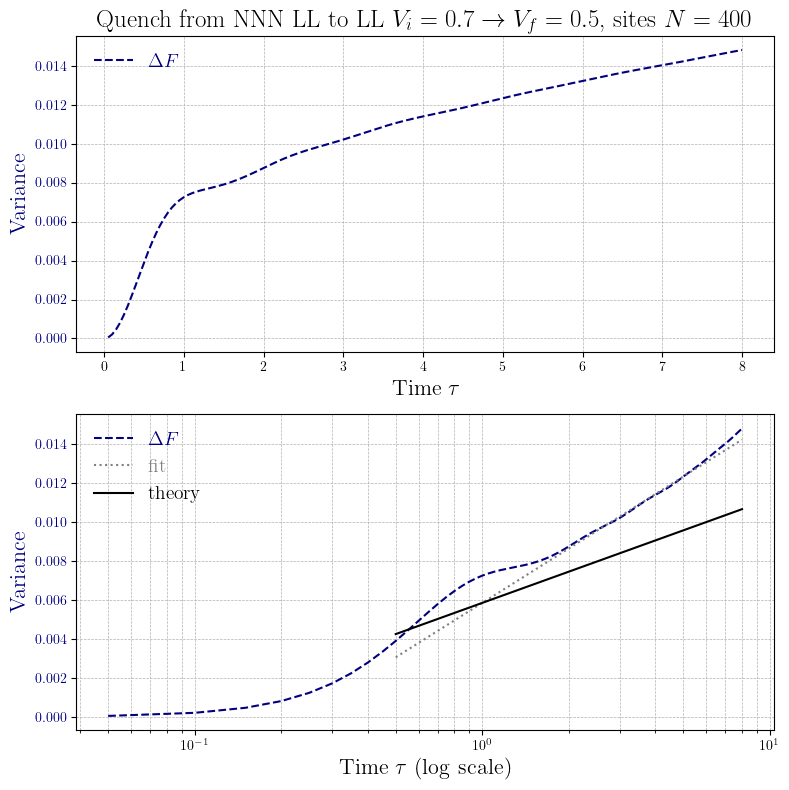

In [96]:
plot_quench_NNN_LL_to_LL_decrease_V_8sec_OBC()